In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches    as mpatches
import matplotlib.colors     as mcolors
from skimage.draw    import polygon
import pandas as pd
import numpy as np
from sklearn.metrics         import classification_report, confusion_matrix, f1_score
import tensorflow as tf

WINDOW, HALF = 25, 24
TRAIN_DAYS = (
    list(range(0,    366))  +  # 2000
    list(range(366,  731))
)
TEST_DAYS  = (
    list(range(2557, 2922)) 
)
ALL_DAYS   = TRAIN_DAYS + TEST_DAYS
META_FILE  = "patches_data.npz"
IMG_FILE   = "patches_imgs.h5"
_SPLIT_KEYS = ["X_basic", "y_all", "coords", "types_arr", "regions_codes", "days_arr"]
ROI_TYPES  = ["COL","CL","COH","NROI"]
TYPE_COLORS = {"COL":"red","CL":"blue","COH":"green","NROI":"orange"}

type_to_label = {"COL": 0, "CL": 1, "COH": 2, "NROI": 3, "BG": 4}
label_to_type = {v: k for k, v in type_to_label.items()}

def create_roi_mask(df, day, shape):
    mask = np.zeros(shape, dtype=np.int8)
    day_data = df[df["Day"]==day]
    for name, grp in day_data.groupby("Name"):
        pts = grp[["x","y"]].values
        if len(pts)<3:
            continue
        xs, ys = pts[:,0].astype(np.int32), pts[:,1].astype(np.int32)
        rows = (shape[0]-1) - ys
        cols = xs
        rr, cc = polygon(rows, cols, shape=shape)
        code = ROI_TYPES.index(grp["Label"].iat[0]) + 1
        mask[rr,cc] = code
    return mask

def load_grids(day):
    P = pd.read_csv(f"pressure/day{day}.txt", sep=r"\s+", header=None).values.astype(np.float32)
    W = pd.read_csv(f"wind/day{day}.txt",    sep=r"\s+", header=None).values.astype(np.float32)
    return P, W

cmap_types = mcolors.ListedColormap(["lightgrey"] + [TYPE_COLORS[t] for t in ROI_TYPES])
type_code  = {t:i+1 for i,t in enumerate(ROI_TYPES)}

roi_df = pd.read_csv("roi_data_with_status.csv")
required = {"Day","Name","x","y","Label"}
if not required.issubset(roi_df.columns):
    raise RuntimeError(f"roi_data_with_status.csv must contain columns: {required}")

raw = np.load(META_FILE, allow_pickle=True)
tr_data = {k: raw[f"tr_{k}"] for k in _SPLIT_KEYS}
te_data = {k: raw[f"te_{k}"] for k in _SPLIT_KEYS}

In [3]:
y_all       = np.concatenate([tr_data['y_all'], te_data['y_all']])
coords      = np.vstack([tr_data['coords'], te_data['coords']])
types_arr   = np.concatenate([tr_data['types_arr'], te_data['types_arr']])
regions_codes = np.concatenate([tr_data['regions_codes'], te_data['regions_codes']])
days_arr    = np.concatenate([tr_data['days_arr'], te_data['days_arr']])
days_arr_te = tr_data['days_arr']

train_mask = np.isin(days_arr, TRAIN_DAYS)
test_mask  = np.isin(days_arr, TEST_DAYS) 

X_feat = np.load('X_feat.npz')['x']

X_feat_te = X_feat[test_mask]
y_te       = y_all[test_mask]
coords_te  = coords [test_mask]
types_tr,  types_te   = types_arr[train_mask], types_arr[test_mask]
days_te    = days_arr[test_mask]

dnn = tf.keras.models.load_model('DNN.keras')

y_type_pred = dnn.predict(X_feat_te).argmax(axis=1)

y_type_tr = np.array([type_to_label[t] for t in types_tr])
y_type_te = np.array([type_to_label[t] for t in types_te])

381517/381517 ━━━━━━━━━━━━━━━━━━━━ 885s 2ms/step


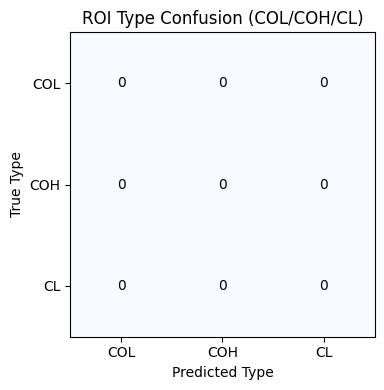

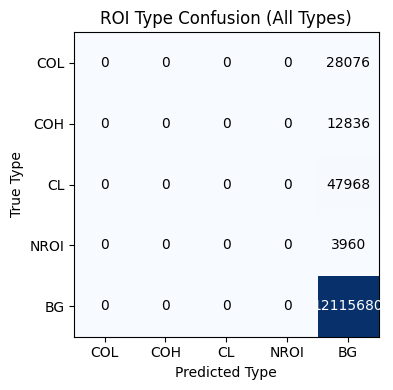

In [4]:
bg_threshold = 0.50

#y_type_pred = np.where(probs[:, 4] > bg_threshold, 4, probs[:, :4].argmax(axis=1))

pred_types_strings = [label_to_type[int(p)] for p in y_type_pred]
true_types_strings = [label_to_type[int(t)] for t in y_type_te]

#3x3 matrix (COL/COH/CL only)
labels3 = ["COL", "COH", "CL"]
mask_3class = np.array([t in labels3 for t in true_types_strings])
cm_types_3 = confusion_matrix(
    np.array(true_types_strings)[mask_3class],
    np.array(pred_types_strings)[mask_3class],
    labels=labels3
)

plt.figure(figsize=(5, 4))
plt.imshow(cm_types_3, cmap="Blues")
plt.title("ROI Type Confusion (COL/COH/CL)")
plt.xticks(range(len(labels3)), labels3)
plt.yticks(range(len(labels3)), labels3)
plt.xlabel("Predicted Type")
plt.ylabel("True Type")
for i in range(len(labels3)):
    for j in range(len(labels3)):
        val = cm_types_3[i, j]
        plt.text(j, i, val, ha="center", va="center",
                color="white" if val > cm_types_3.max()/2 else "black")
plt.tight_layout()
plt.show()

# 5x5 matrix (all ROI types including NROI)
labels4 = ["COL", "COH", "CL", "NROI", "BG"]
cm_types_4 = confusion_matrix(true_types_strings, pred_types_strings, labels=labels4)

plt.figure(figsize=(5, 4))
plt.imshow(cm_types_4, cmap="Blues")
plt.title("ROI Type Confusion (All Types)")
plt.xticks(range(len(labels4)), labels4)
plt.yticks(range(len(labels4)), labels4)
plt.xlabel("Predicted Type")
plt.ylabel("True Type")
for i in range(len(labels4)):
    for j in range(len(labels4)):
        val = cm_types_4[i, j]
        plt.text(j, i, val, ha="center", va="center",
                color="white" if val > cm_types_4.max()/2 else "black")
plt.tight_layout()
plt.show()

In [5]:
# Per-type metrics
from sklearn.metrics import classification_report
print("\n=== ROI Type Classification Report ===")
print(classification_report(true_types_strings, pred_types_strings, labels=labels4))

# Calculate per-type recall
support = np.array([(np.array(true_types_strings) == t).sum() for t in labels4], dtype=float)
diag = np.diag(cm_types_4).astype(float)
recall_by_type = {t: (d / s if s > 0 else 0.0) for t, d, s in zip(labels4, diag, support)}
print("\nPer-type recall:", recall_by_type)

# F1 score
from sklearn.metrics import f1_score
print(f"Weighted F1 score: {f1_score(true_types_strings, pred_types_strings, average='weighted', labels=labels4):.3f}")




=== ROI Type Classification Report ===


c:\Users\nelsobt\BCSCI_Research\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\nelsobt\BCSCI_Research\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\nelsobt\BCSCI_Research\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result

              precision    recall  f1-score   support

         COL       0.00      0.00      0.00     28076
         COH       0.00      0.00      0.00     12836
          CL       0.00      0.00      0.00     47968
        NROI       0.00      0.00      0.00      3960
          BG       0.99      1.00      1.00  12115680

    accuracy                           0.99  12208520
   macro avg       0.20      0.20      0.20  12208520
weighted avg       0.98      0.99      0.99  12208520


Per-type recall: {'COL': np.float64(0.0), 'COH': np.float64(0.0), 'CL': np.float64(0.0), 'NROI': np.float64(0.0), 'BG': np.float64(1.0)}
Weighted F1 score: 0.989


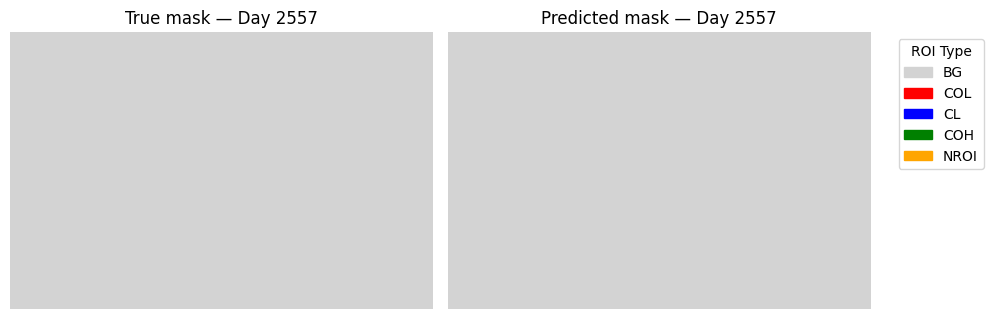

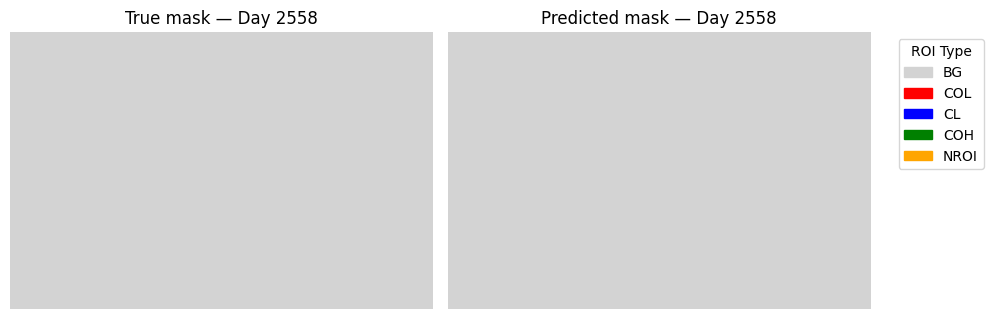

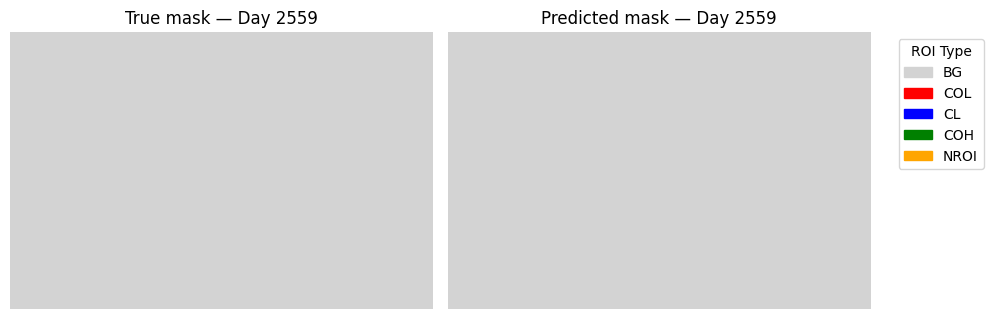

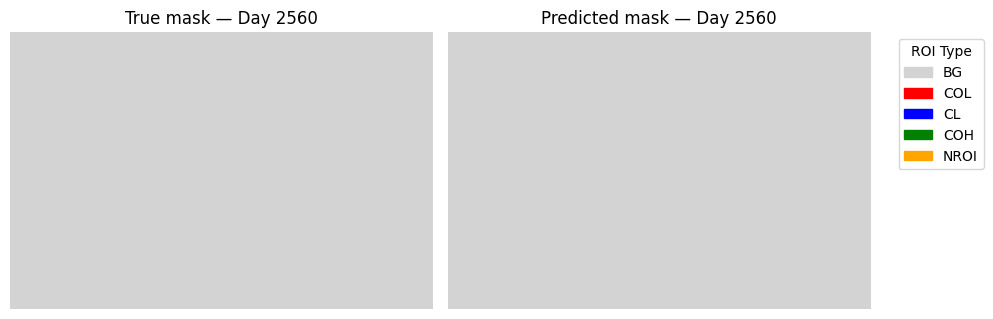

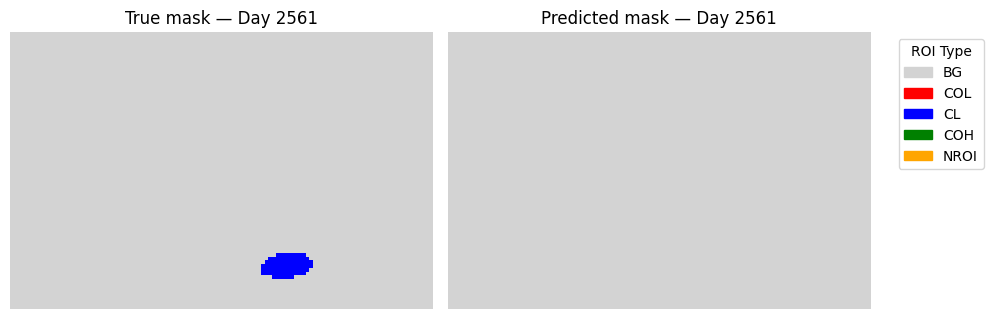

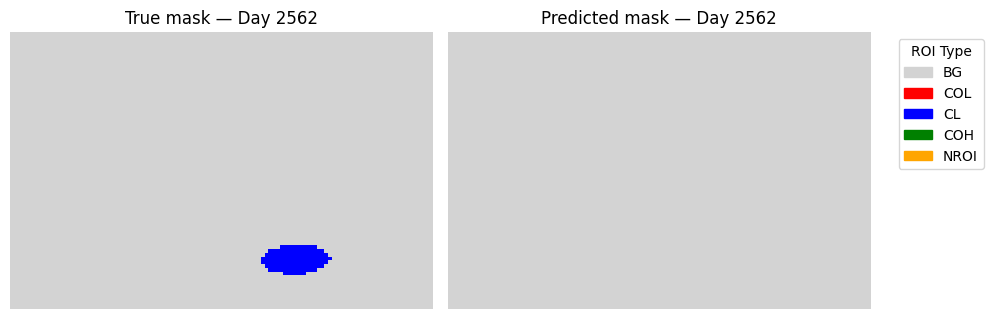

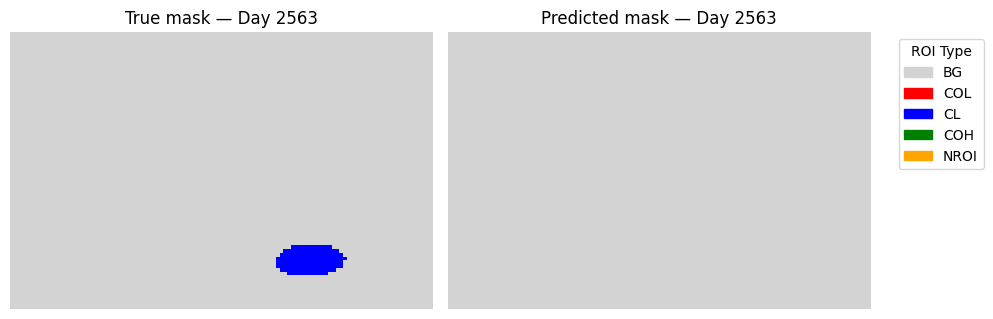

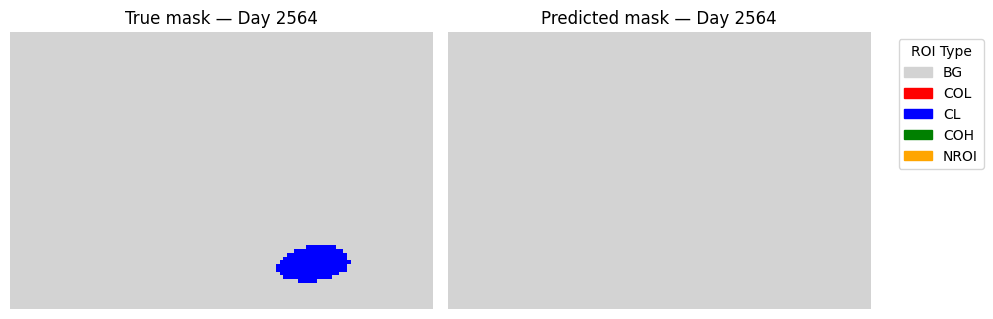

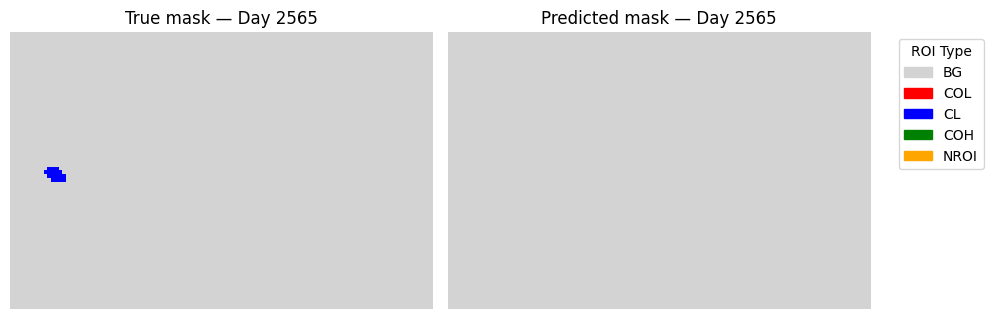

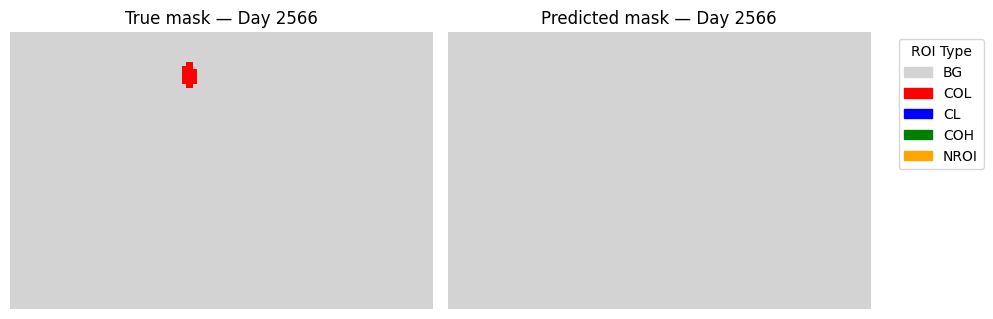

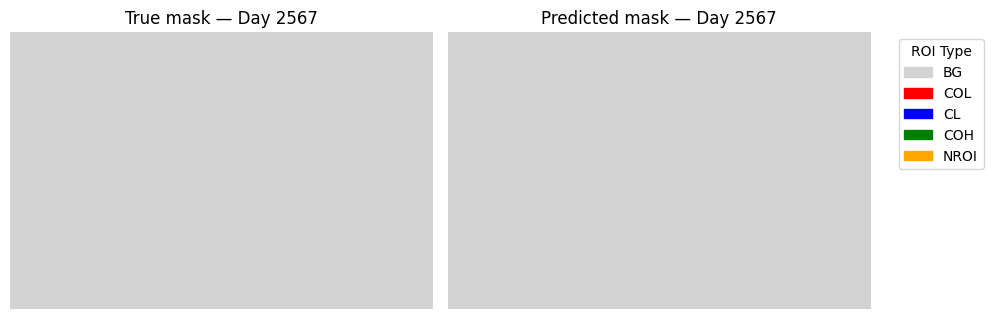

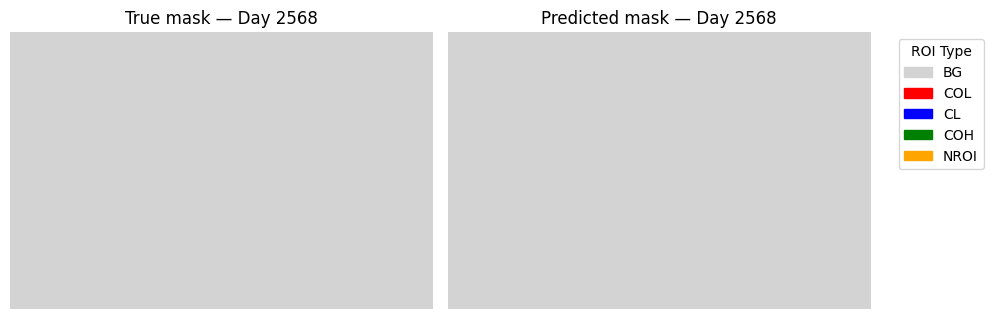

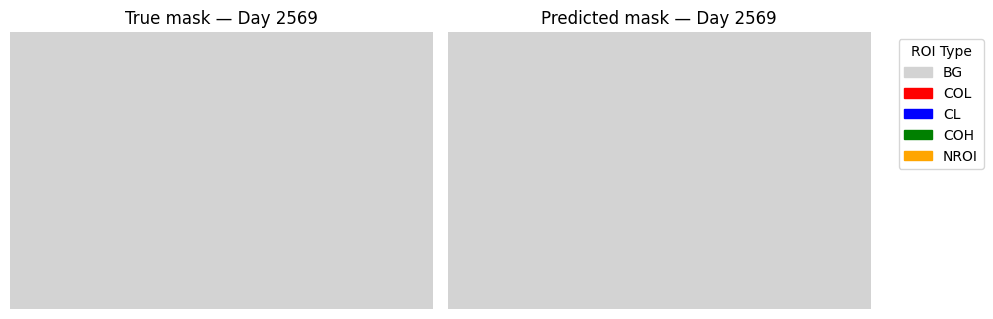

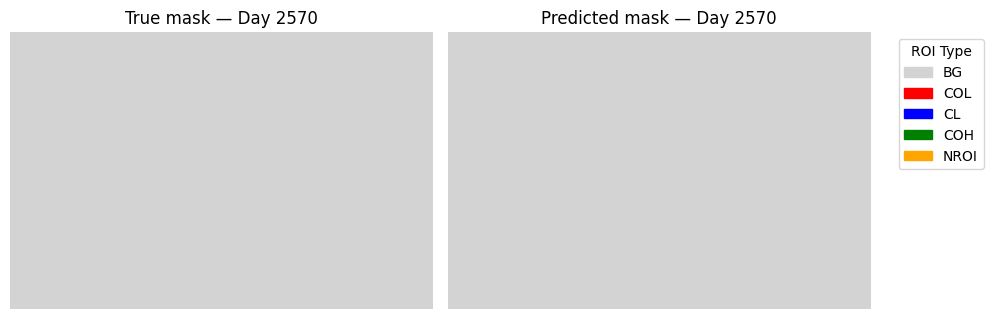

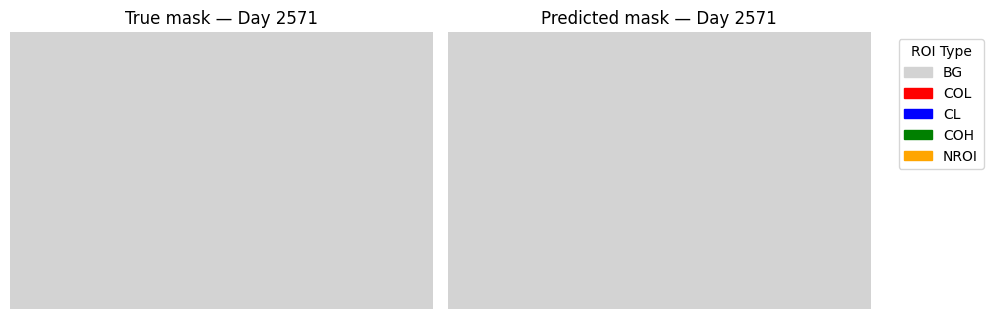

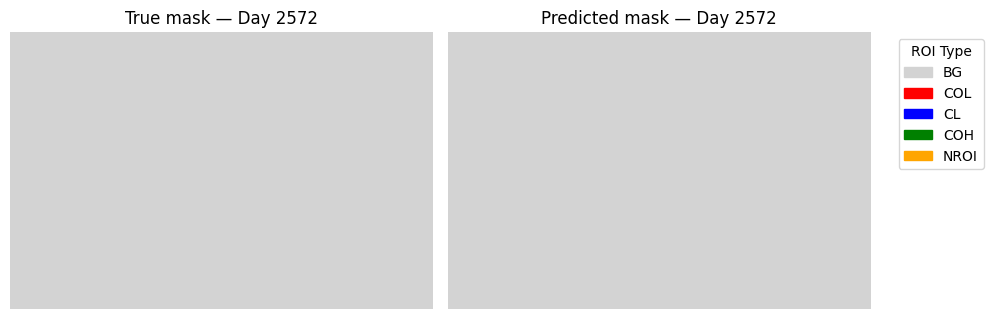

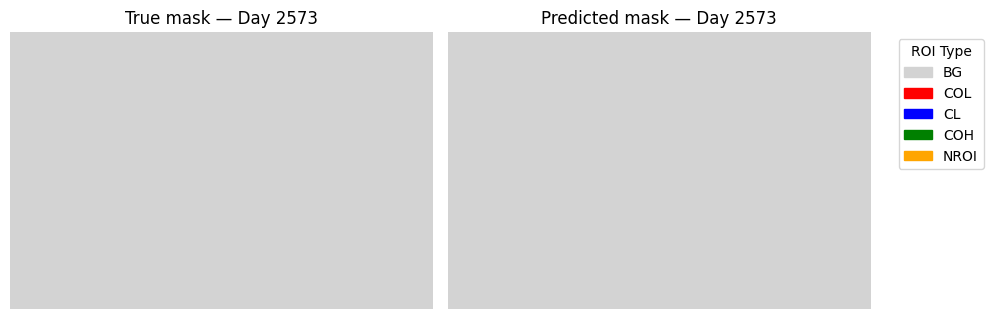

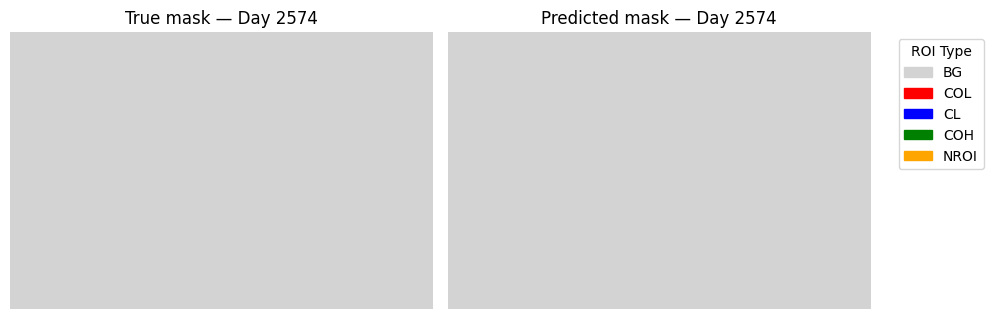

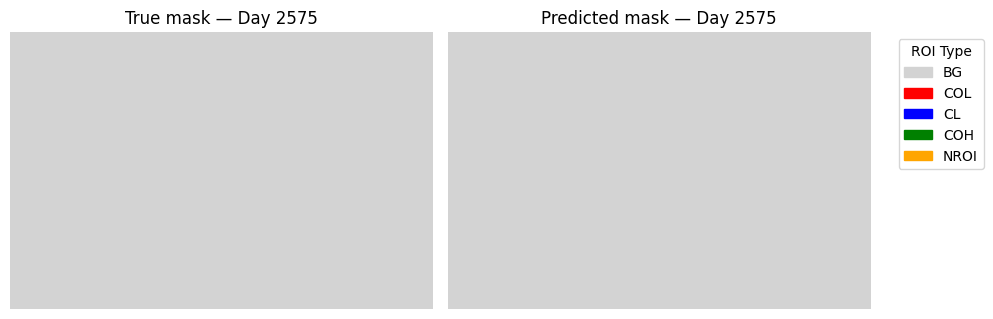

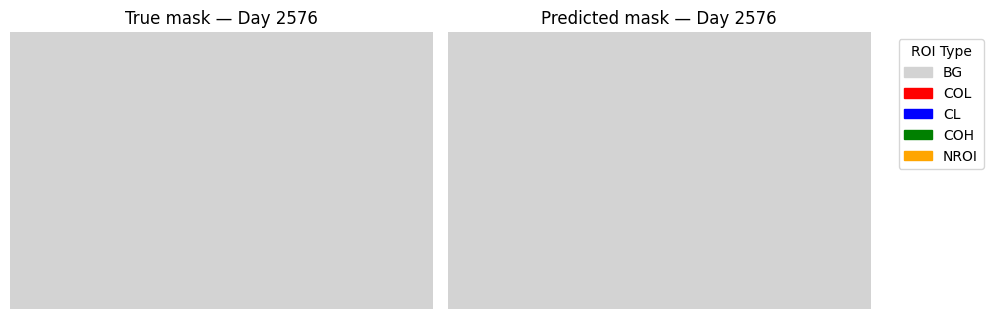

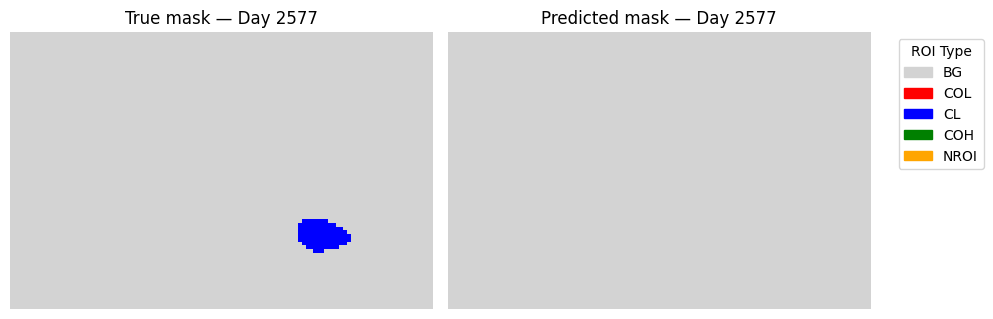

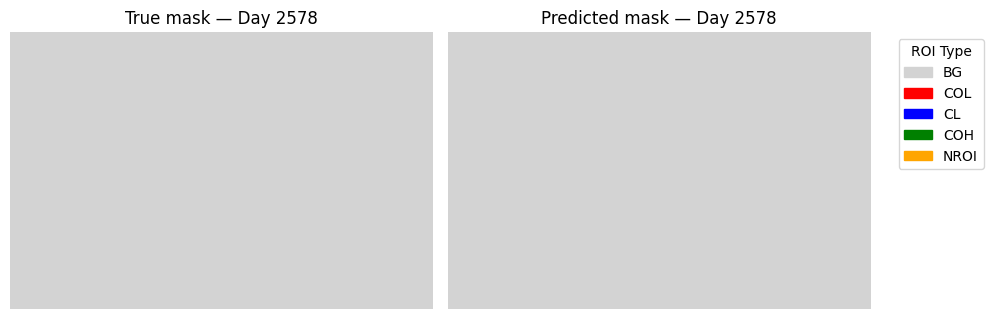

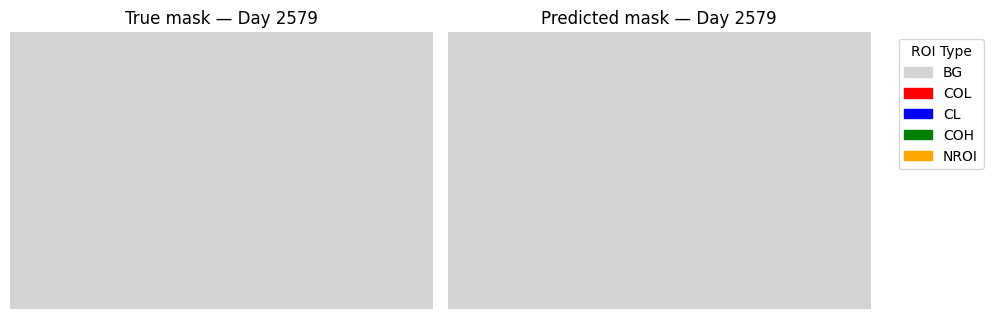

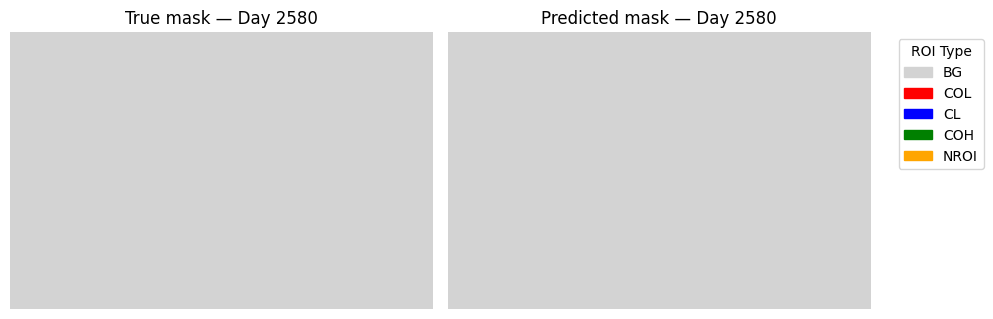

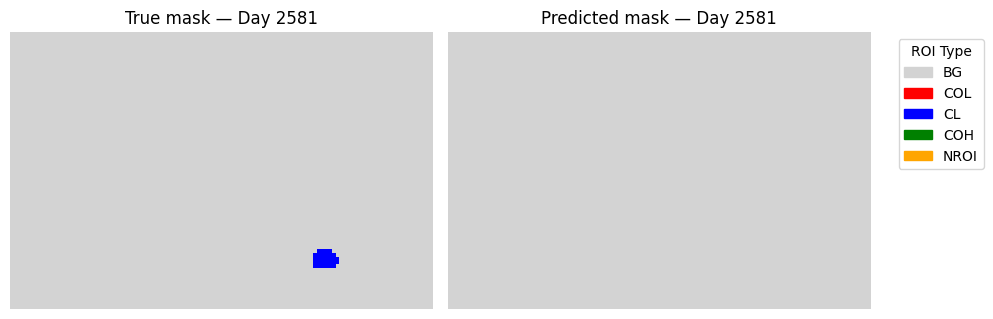

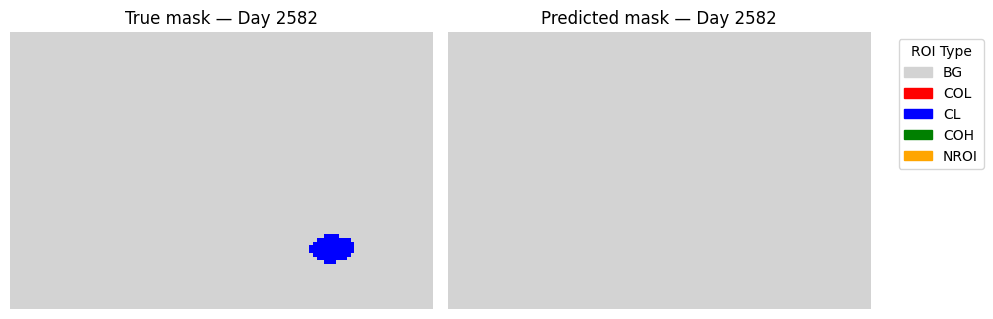

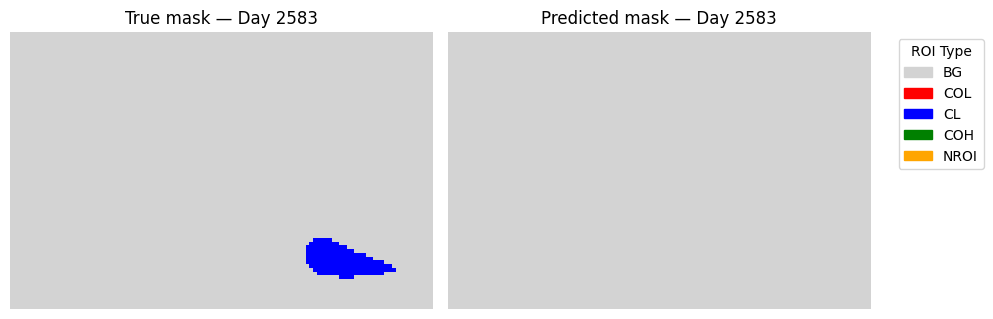

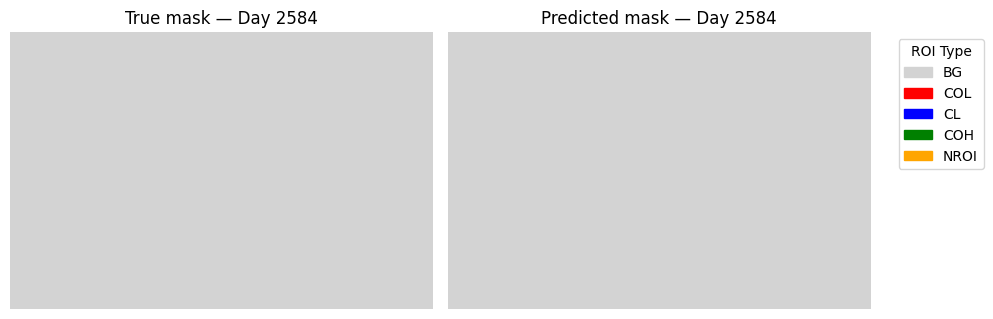

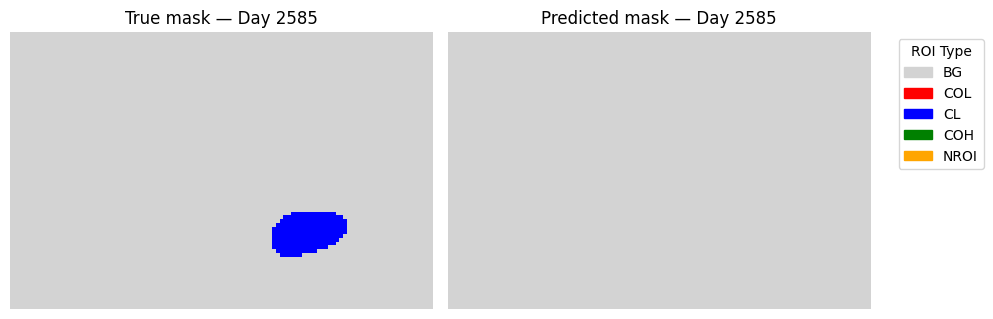

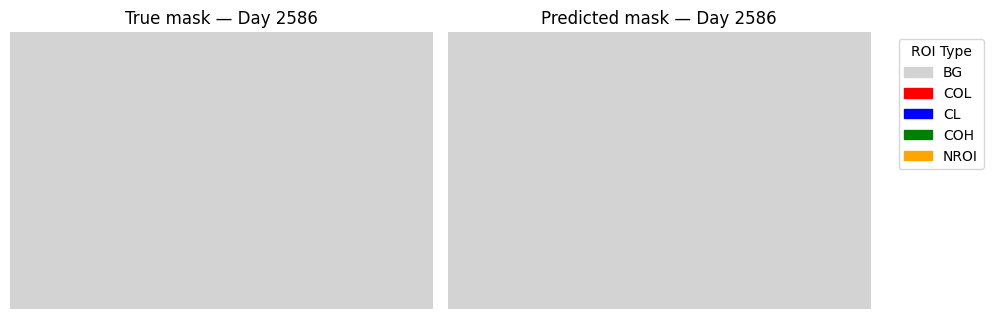

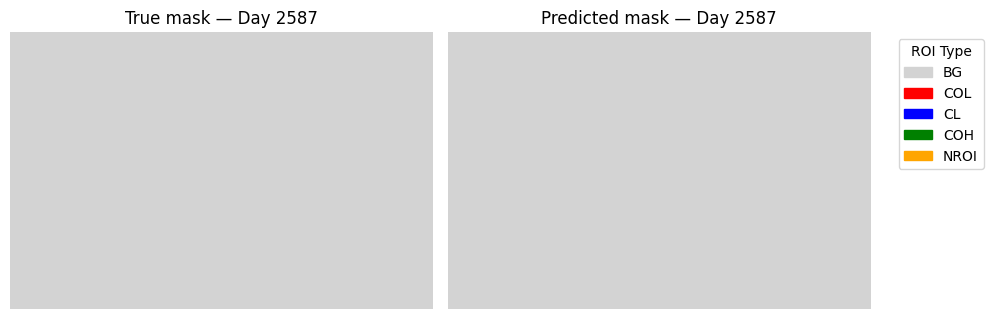

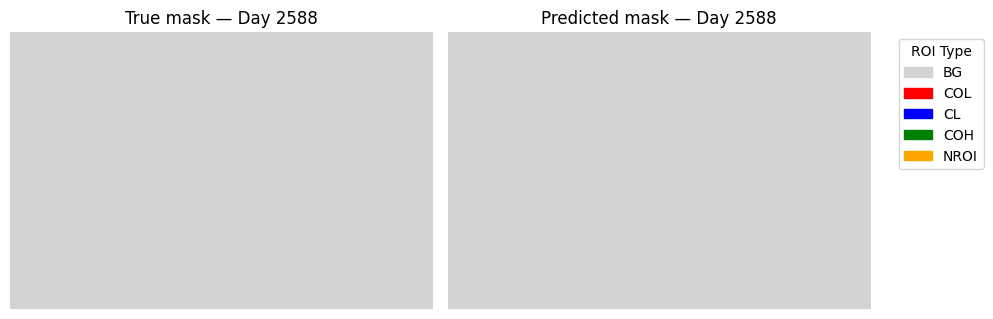

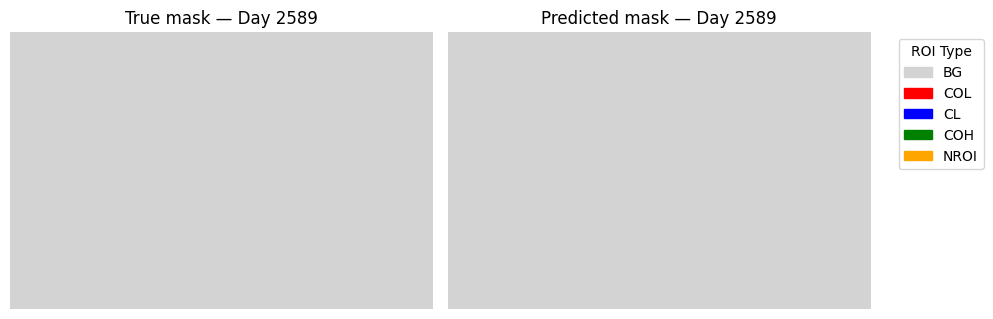

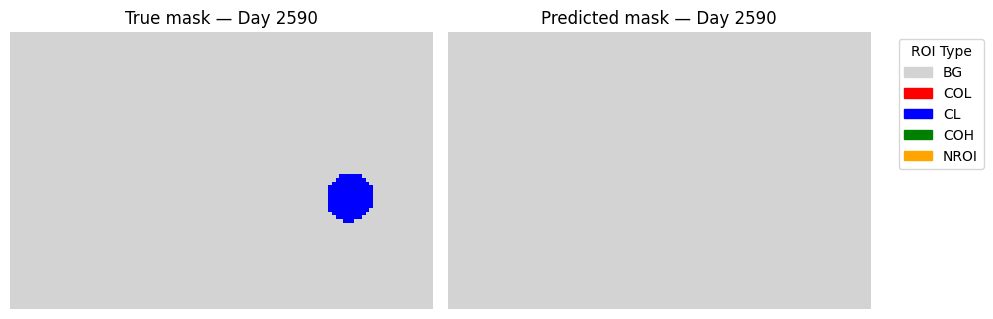

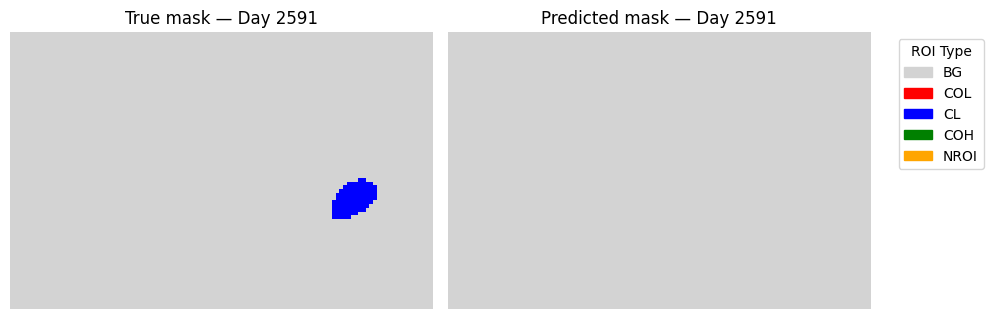

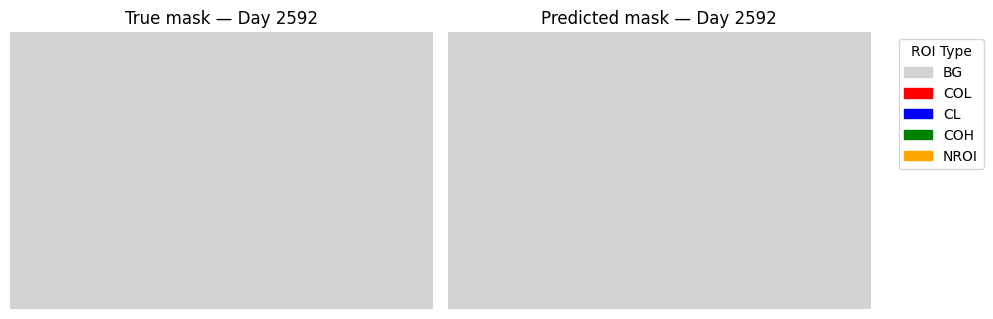

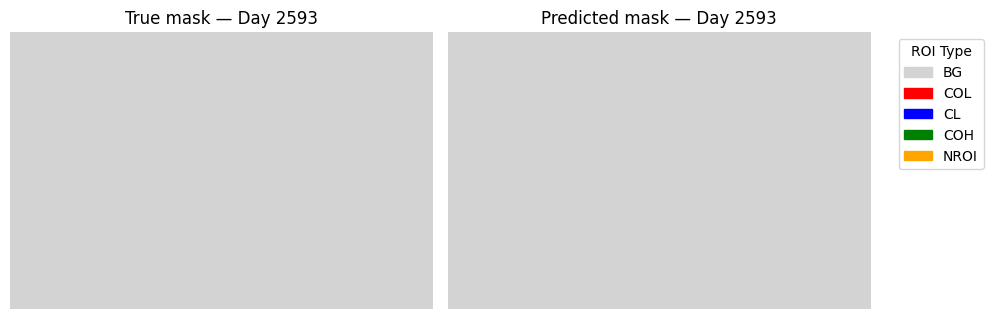

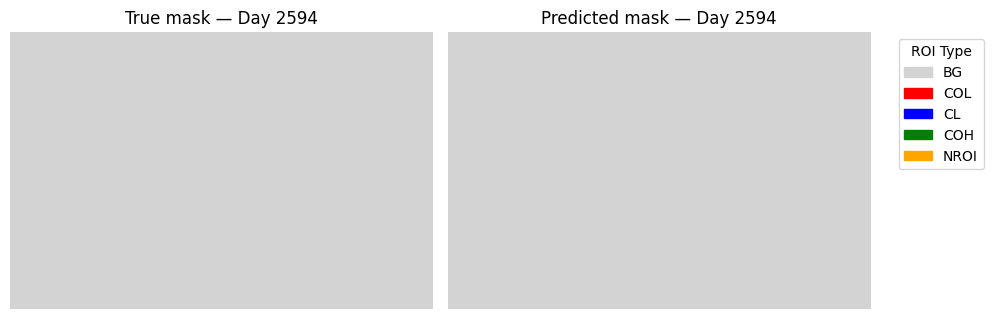

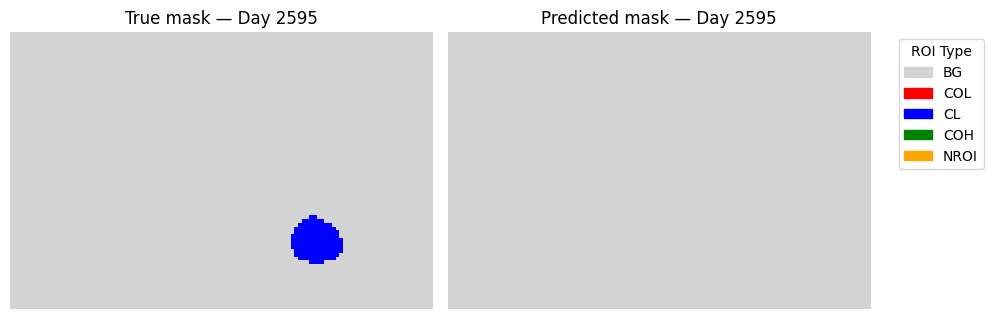

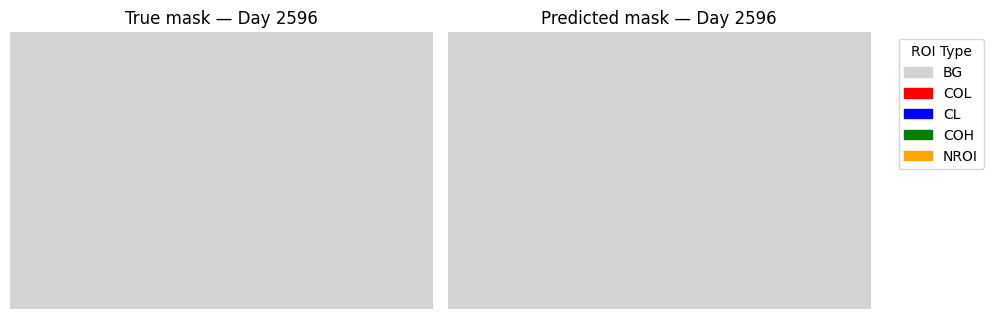

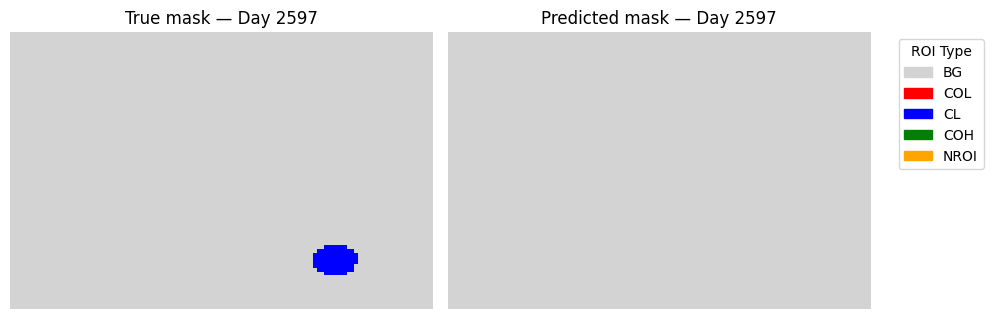

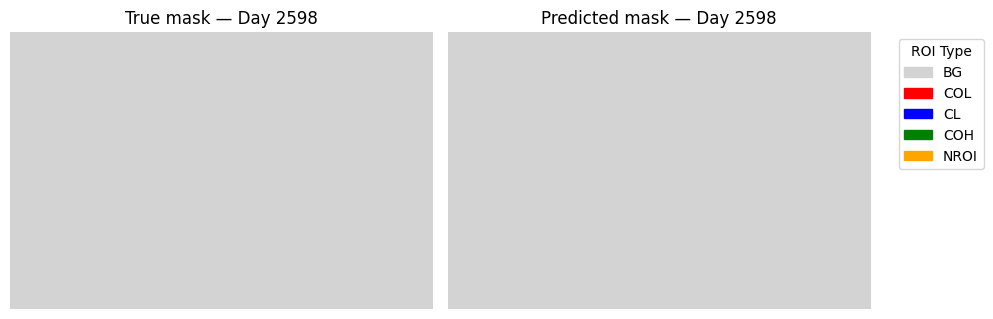

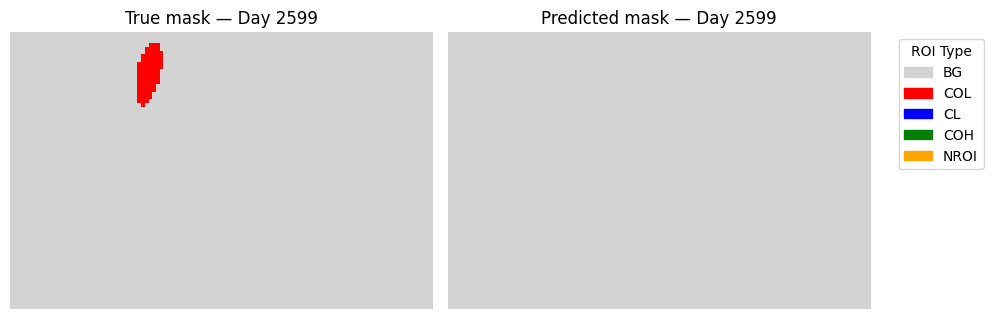

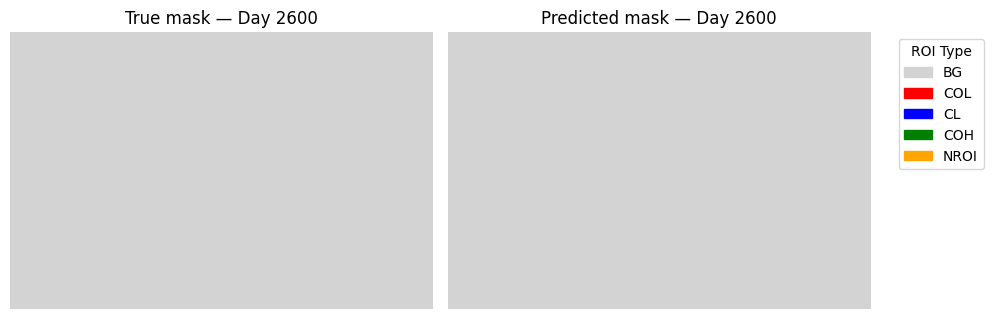

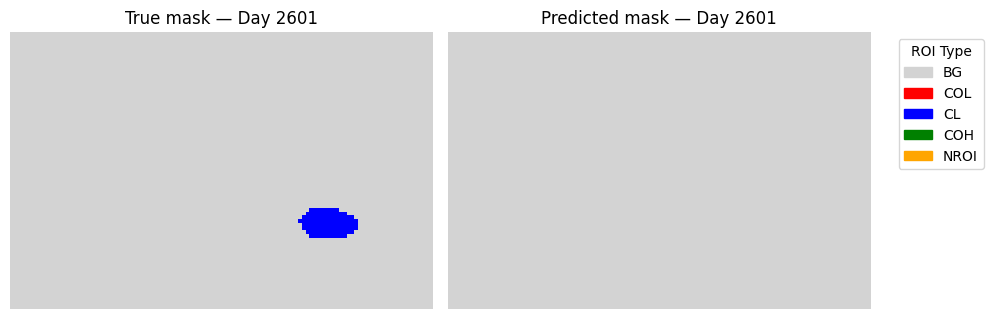

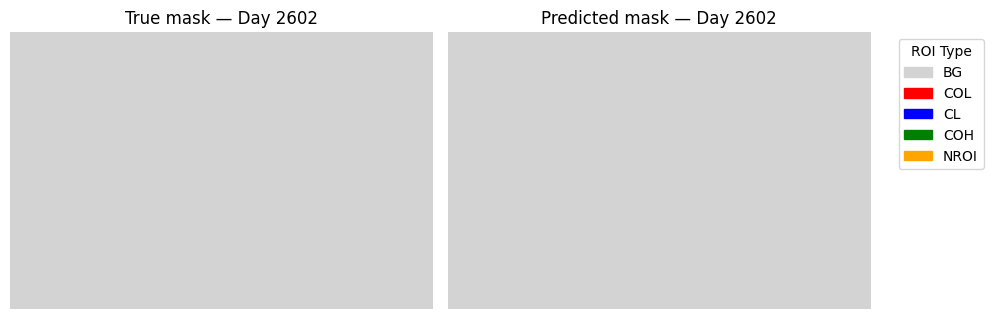

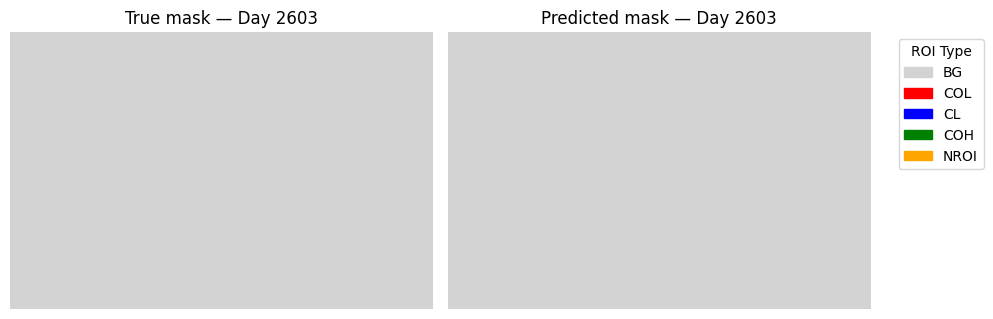

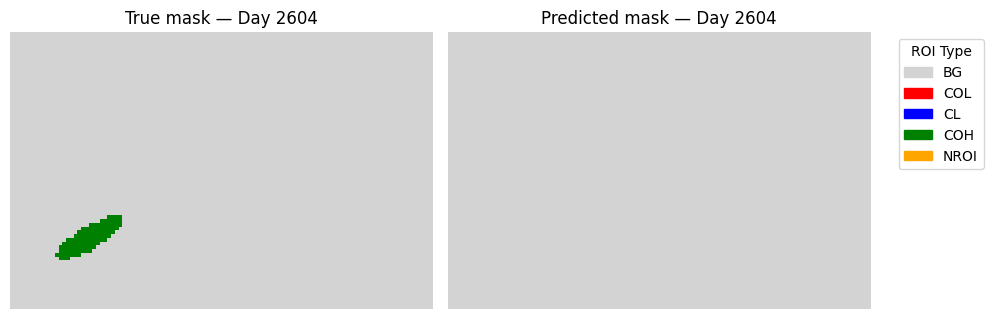

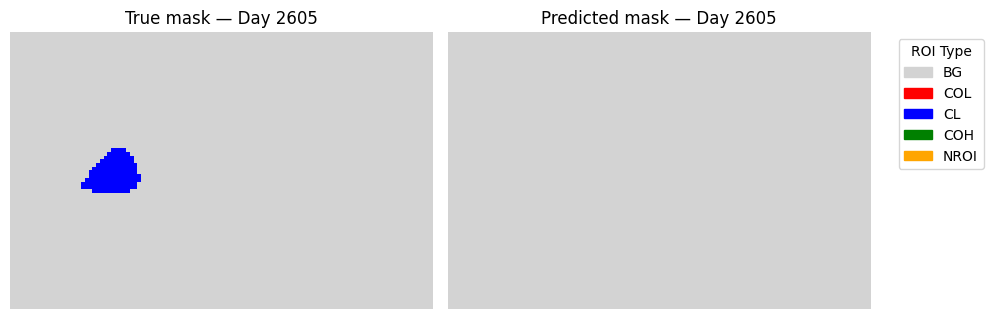

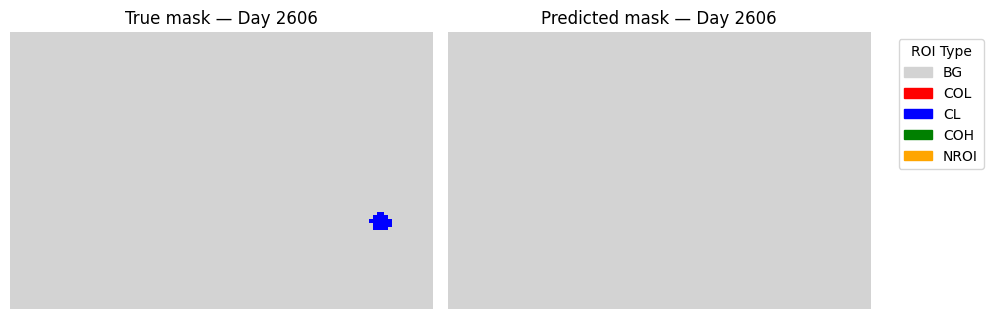

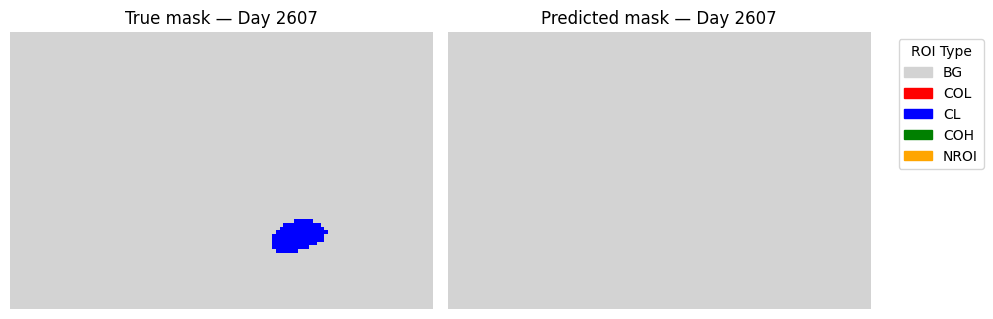

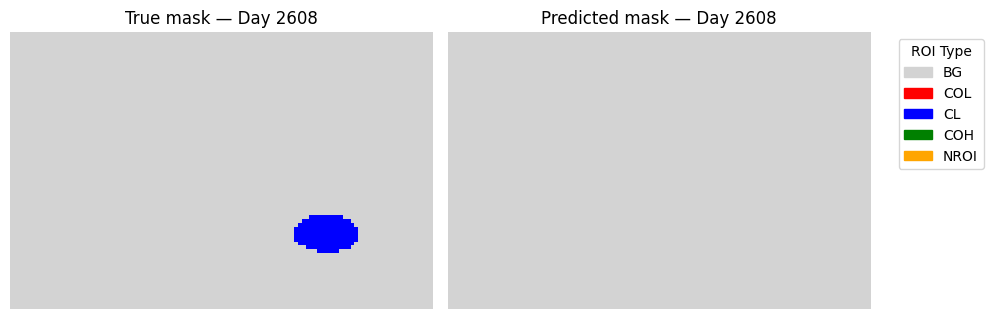

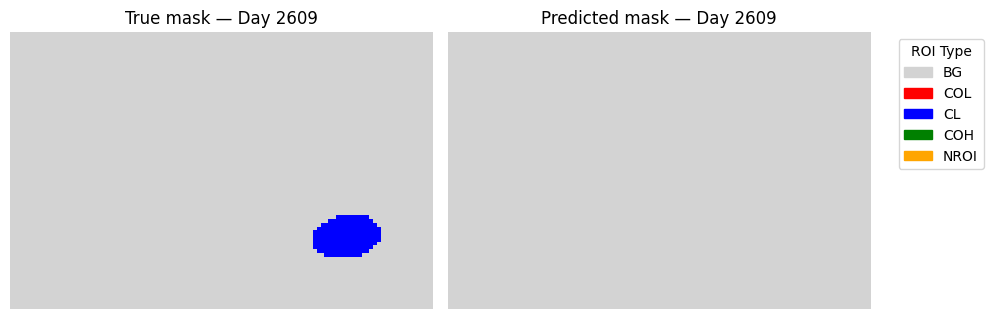

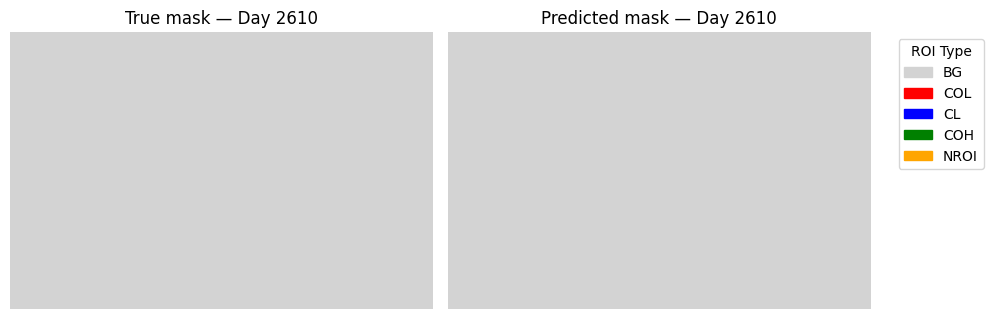

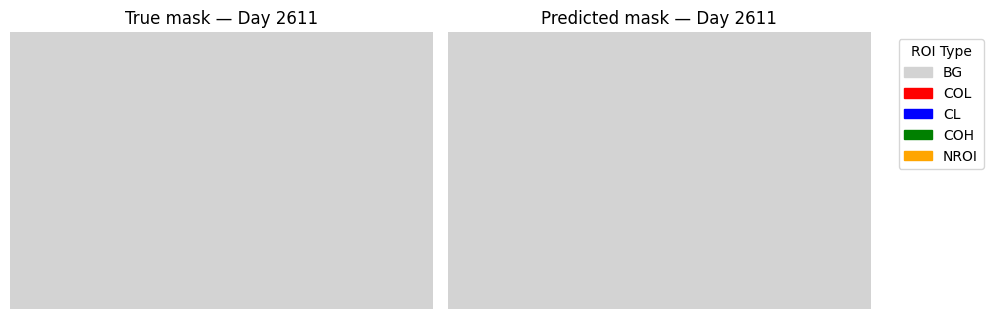

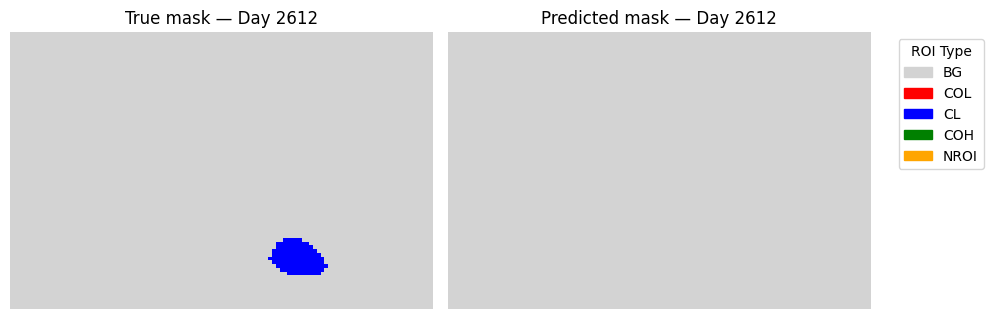

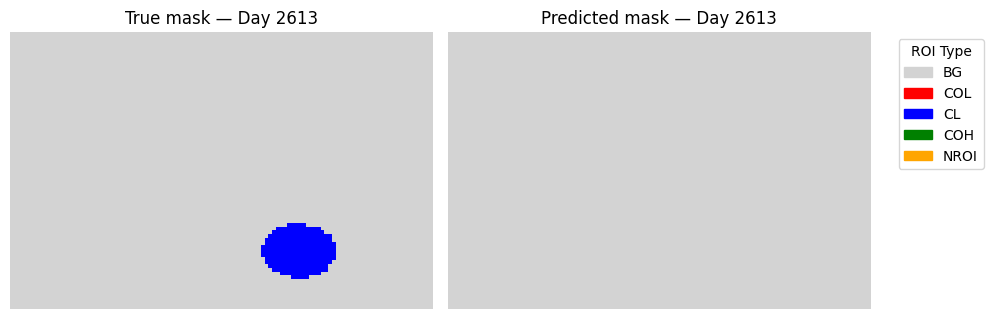

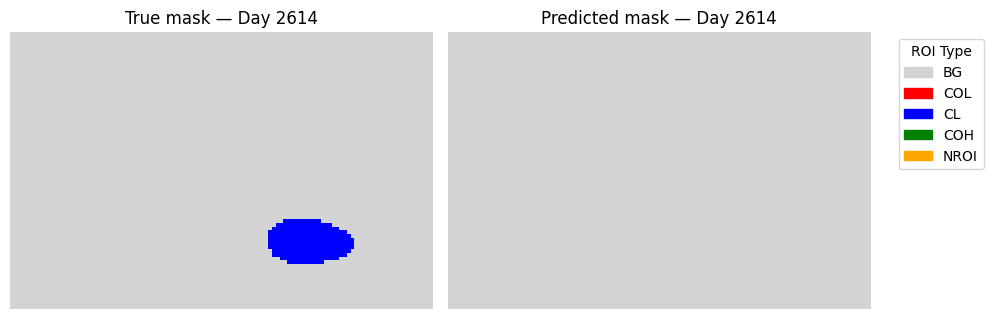

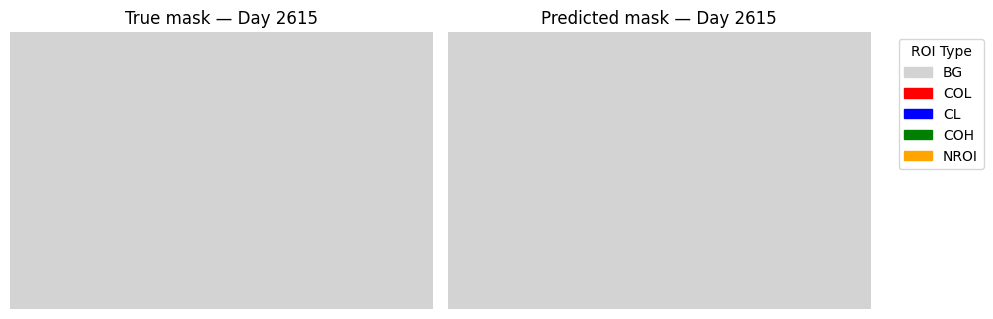

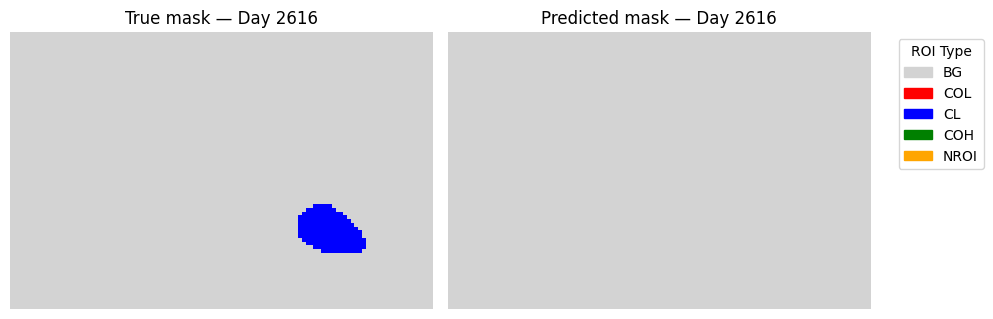

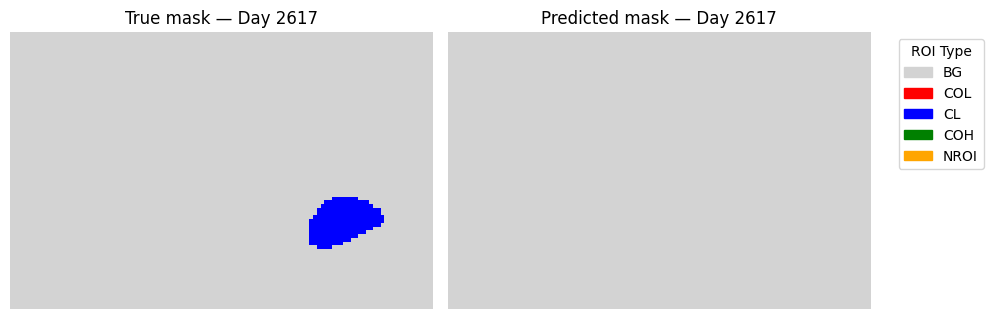

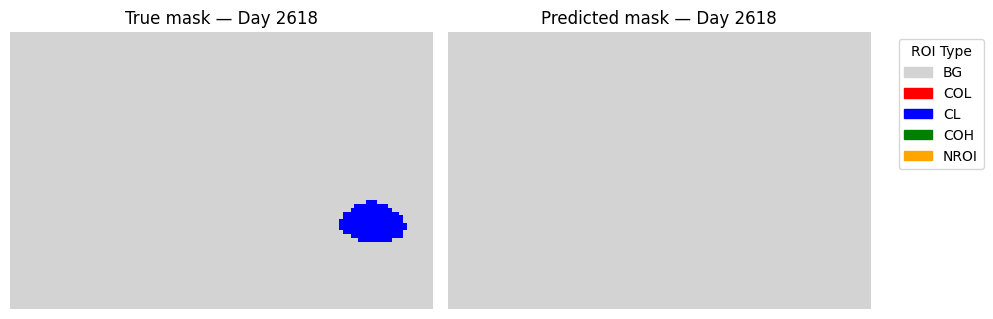

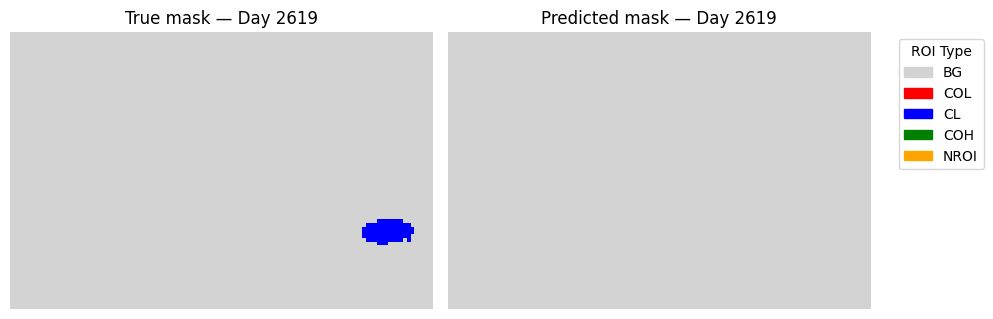

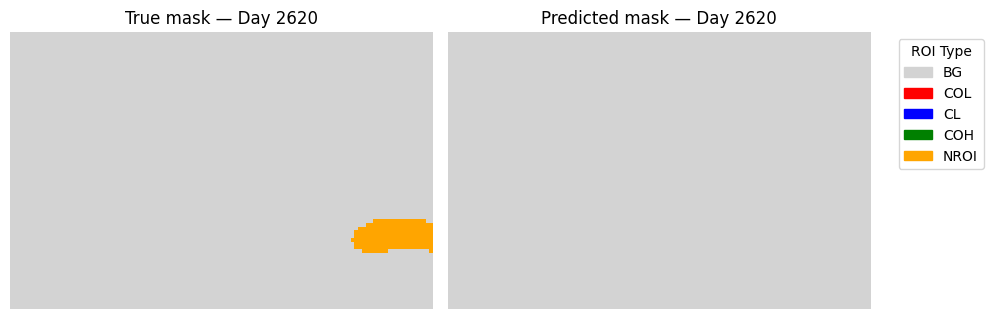

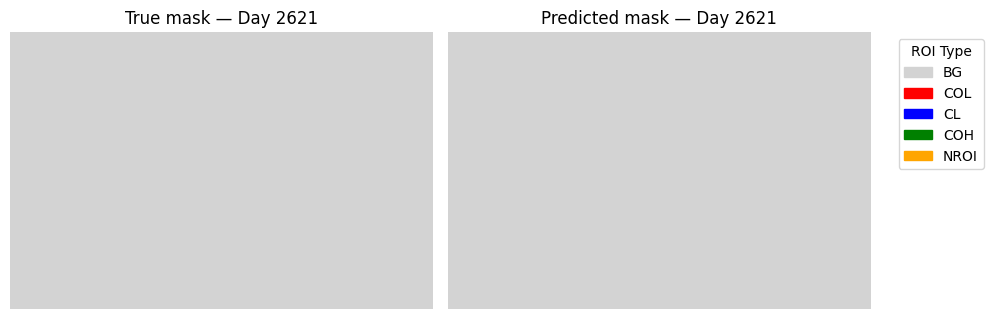

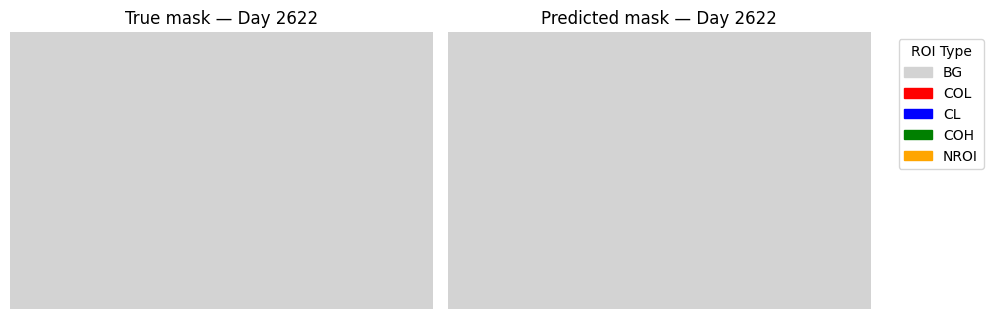

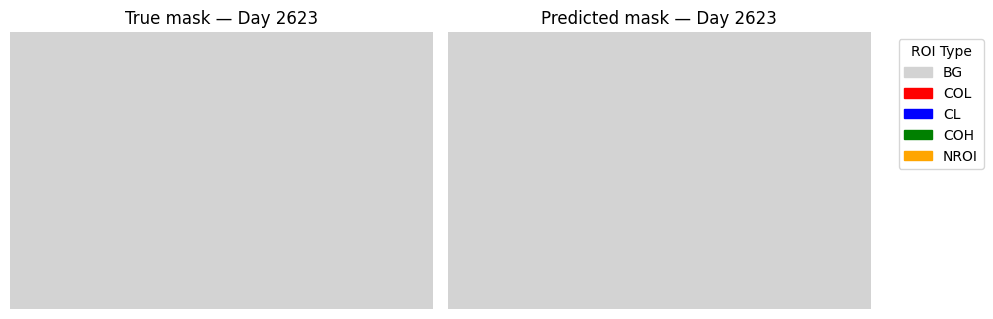

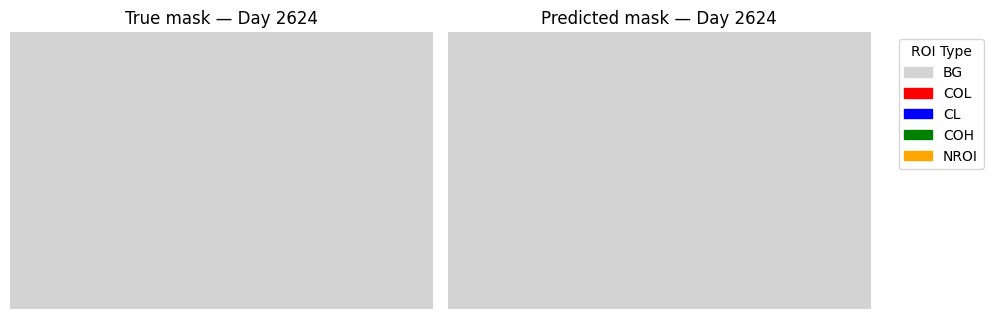

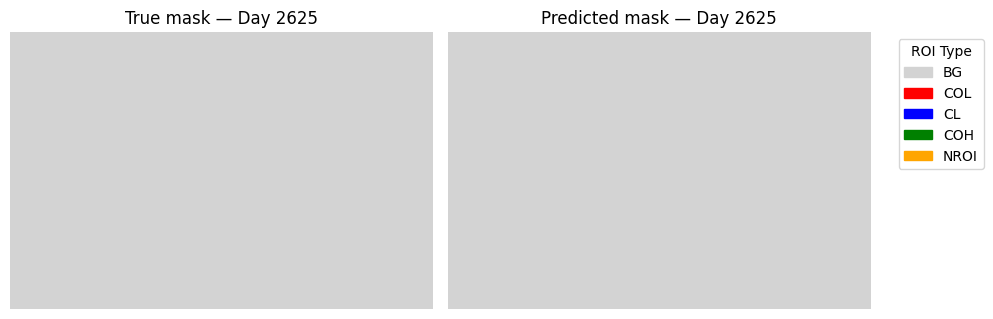

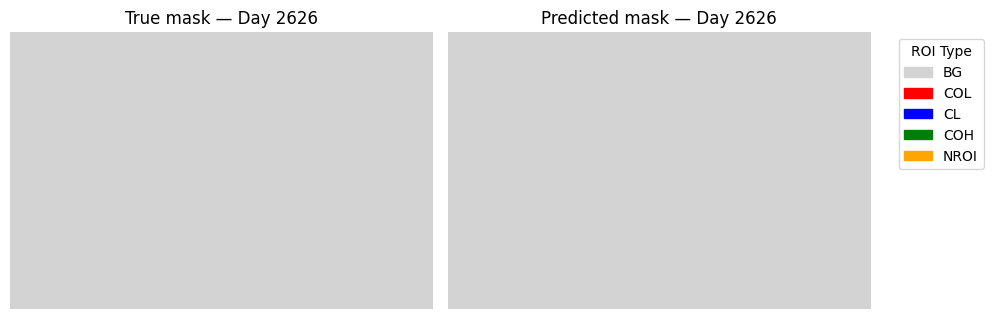

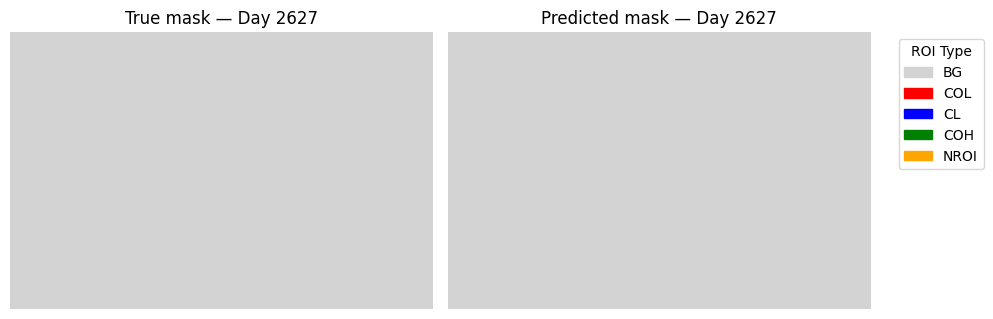

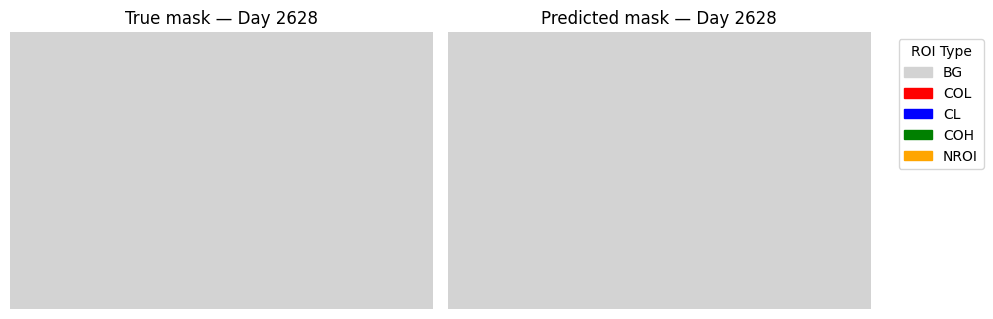

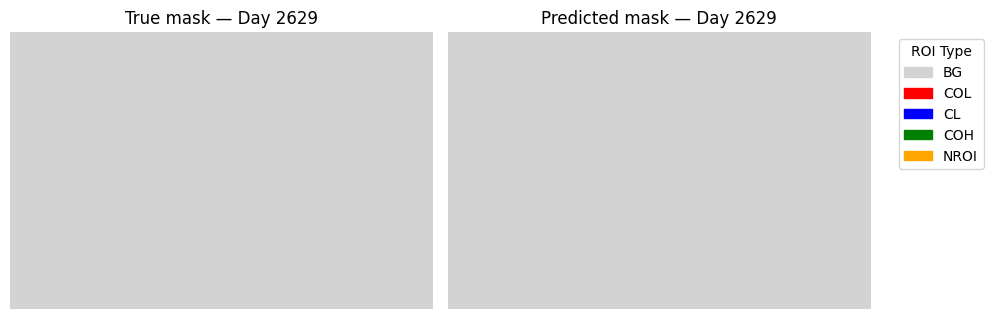

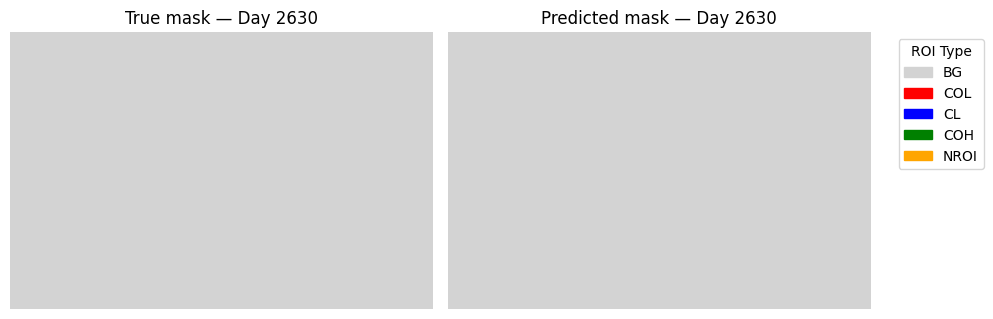

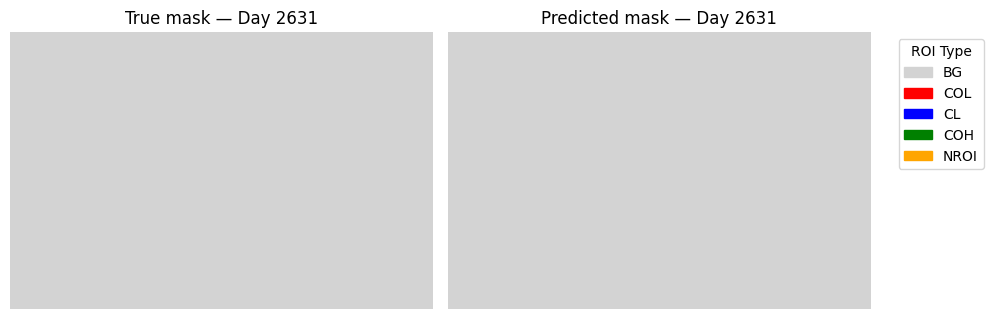

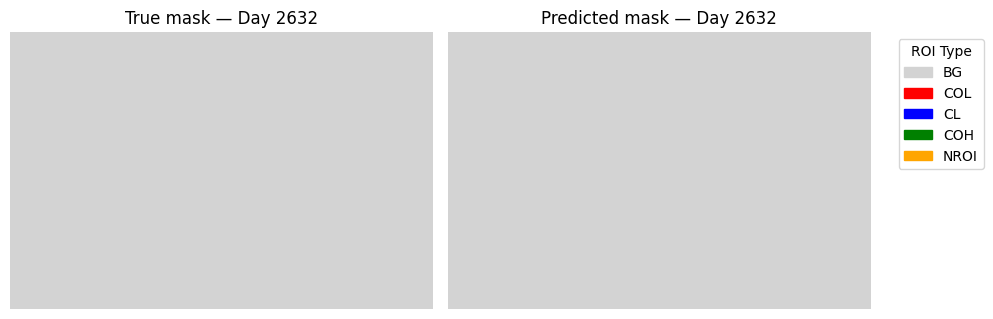

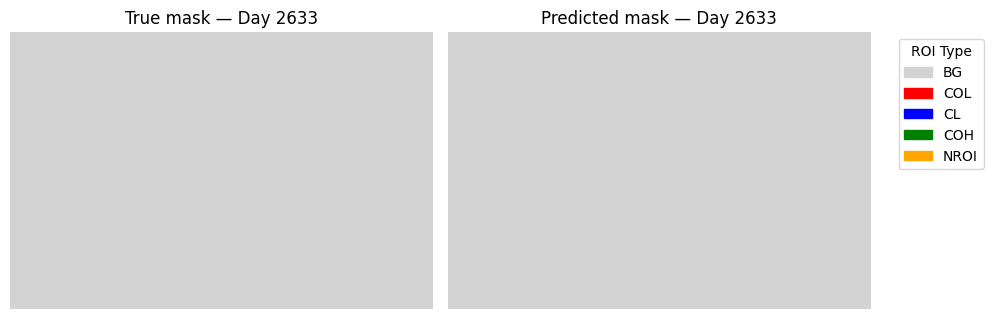

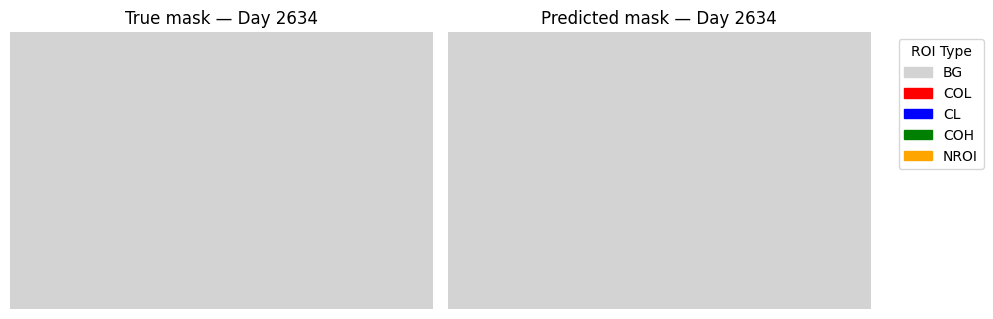

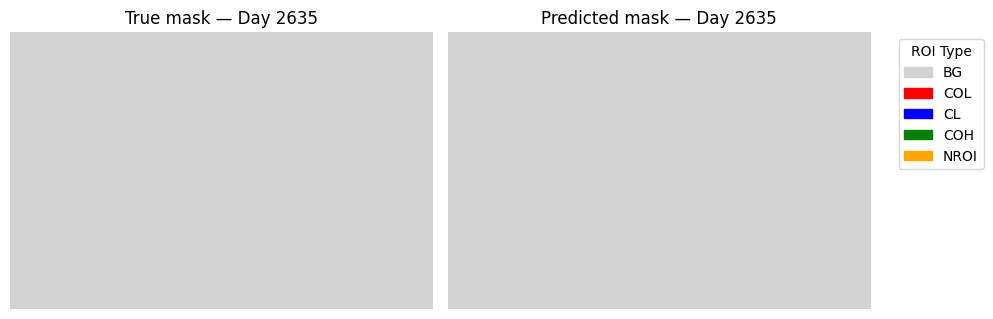

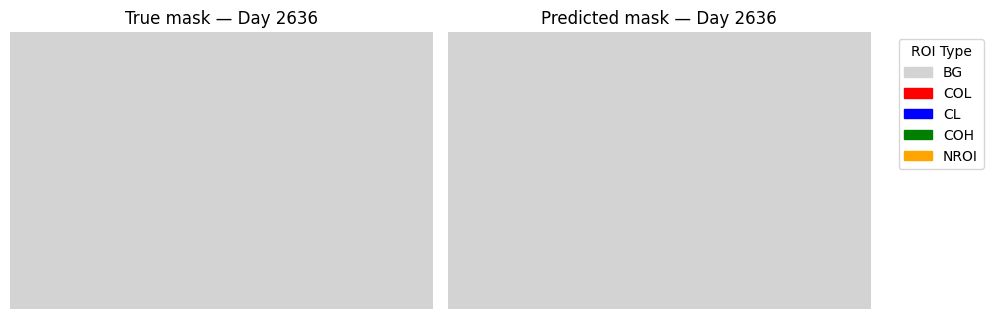

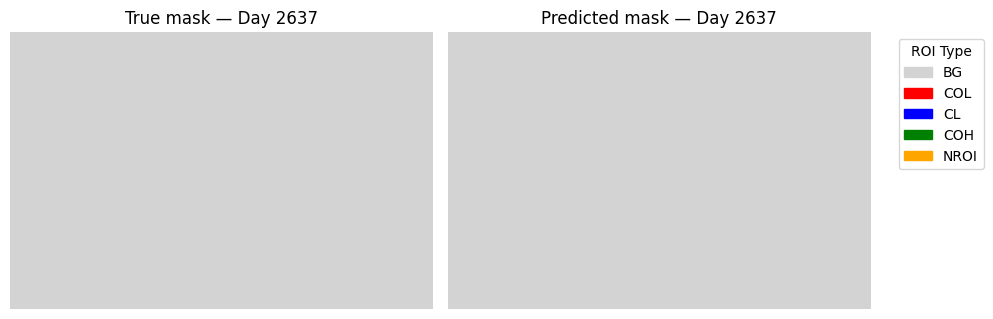

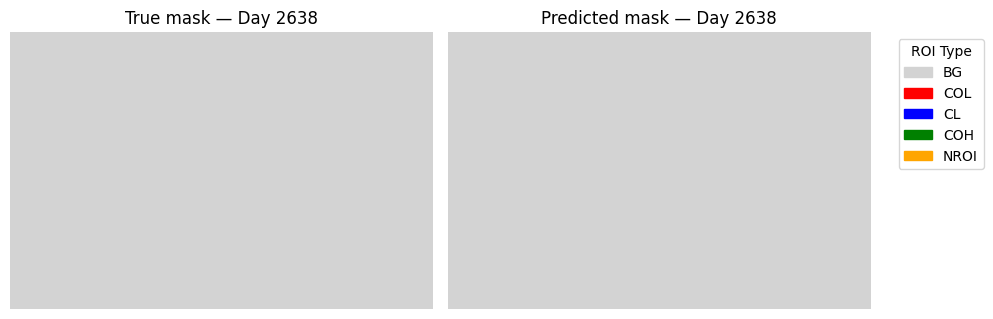

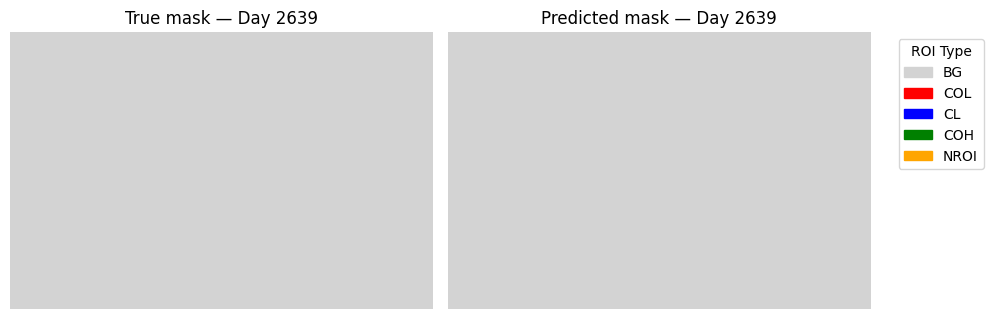

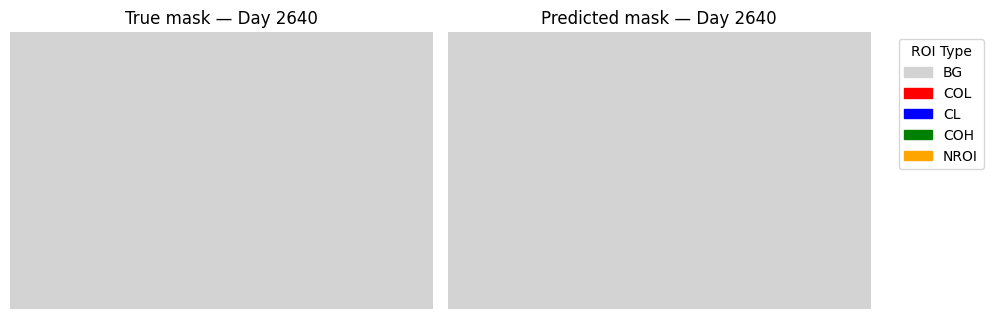

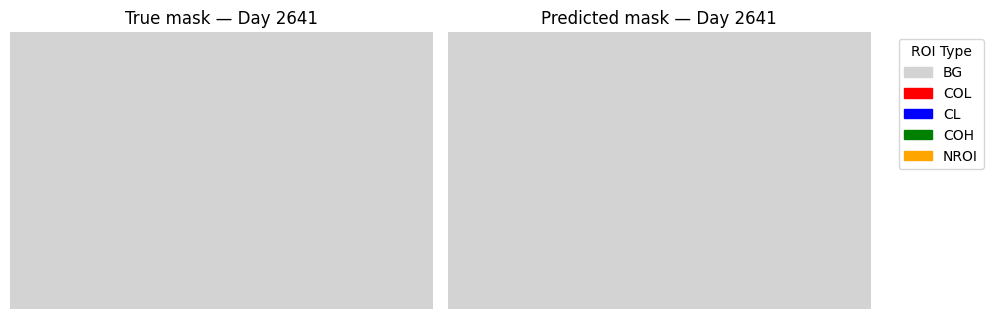

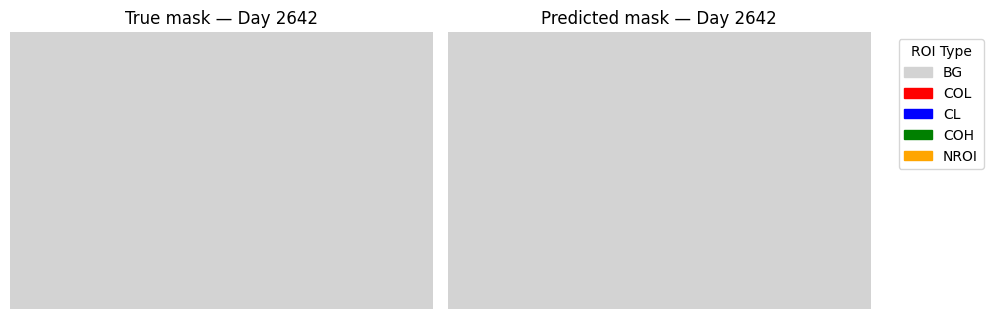

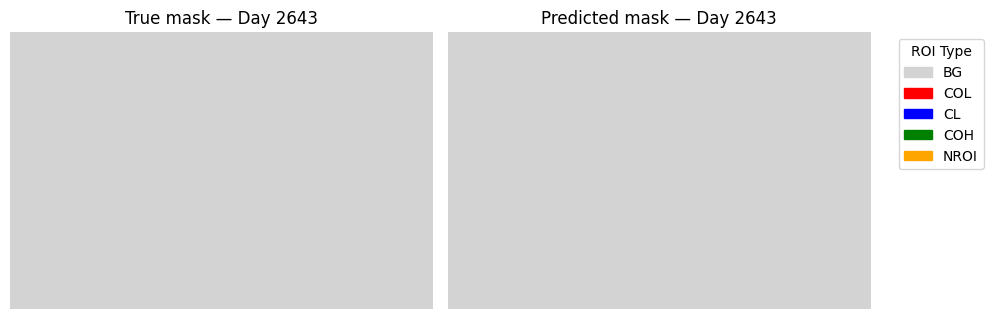

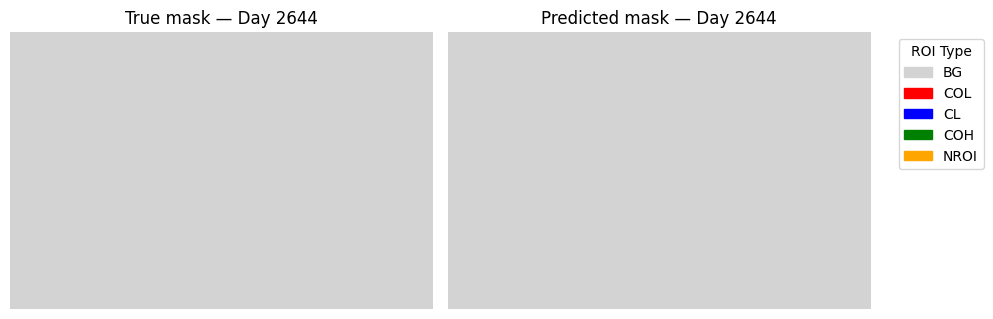

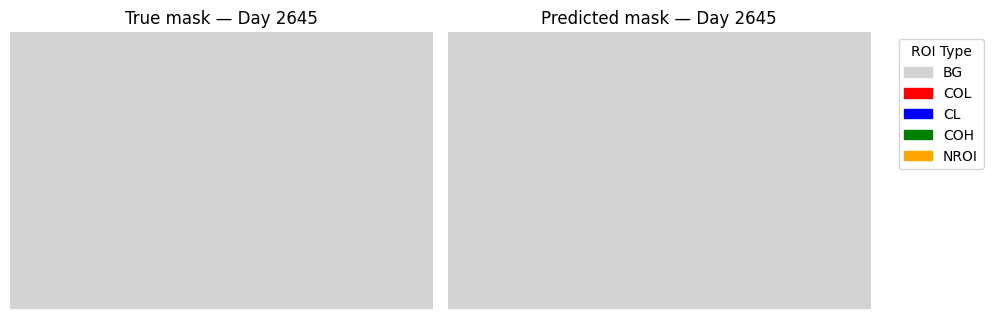

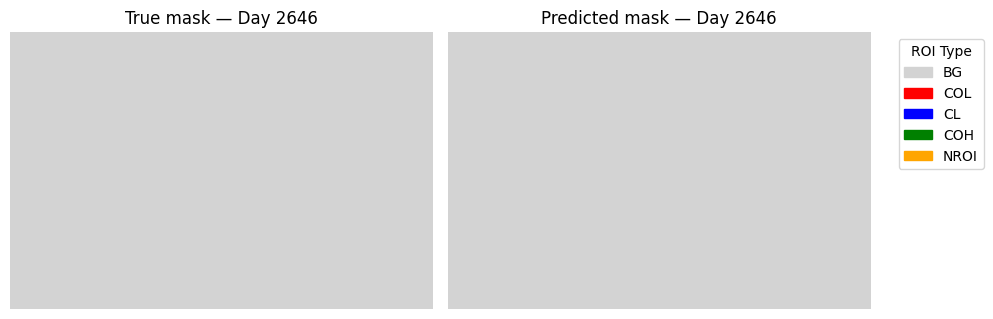

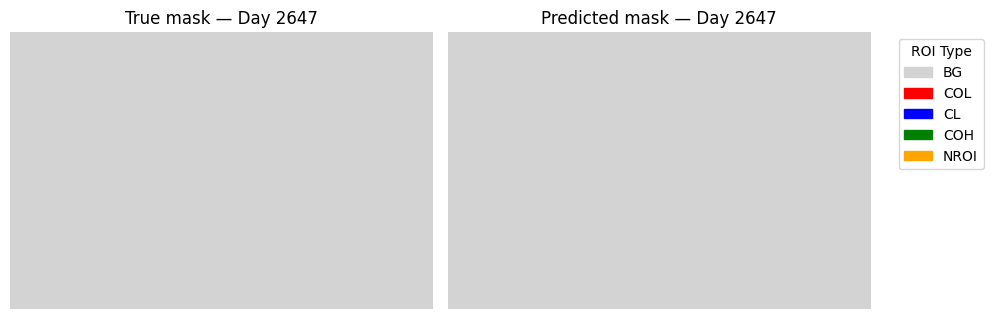

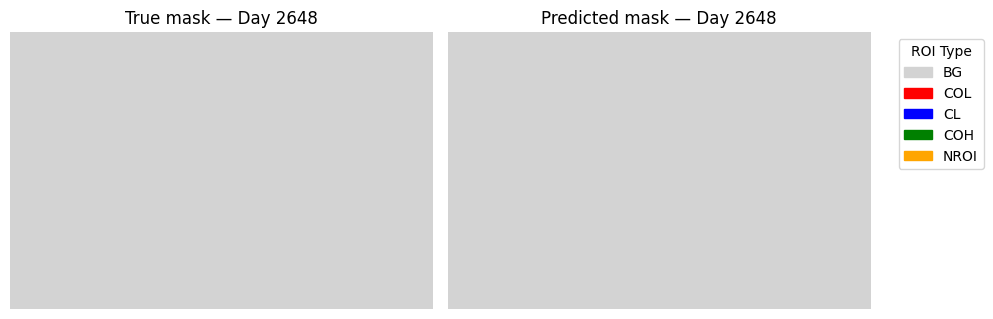

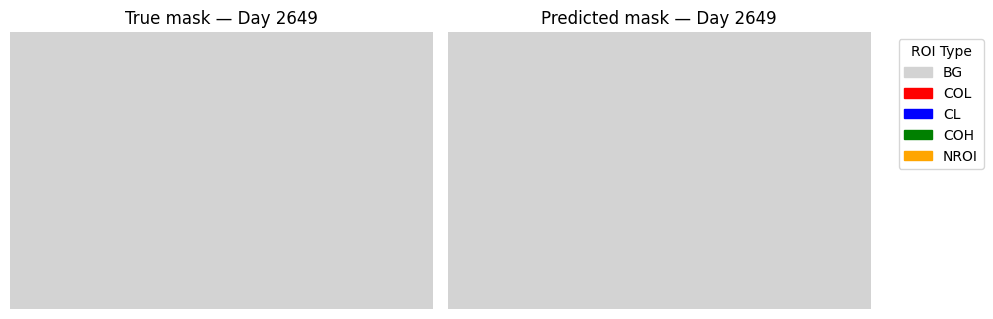

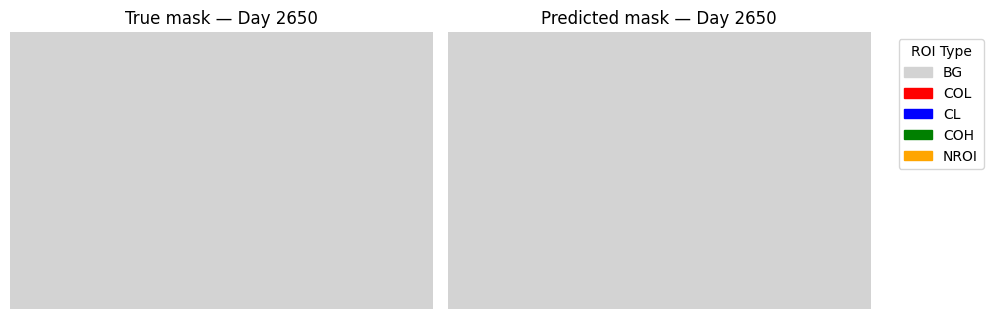

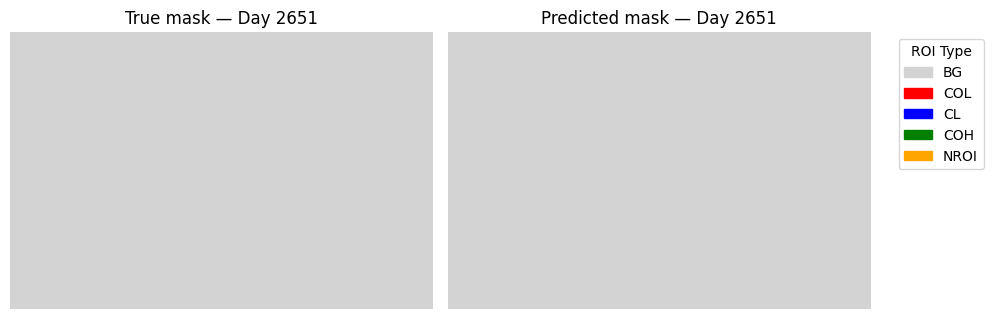

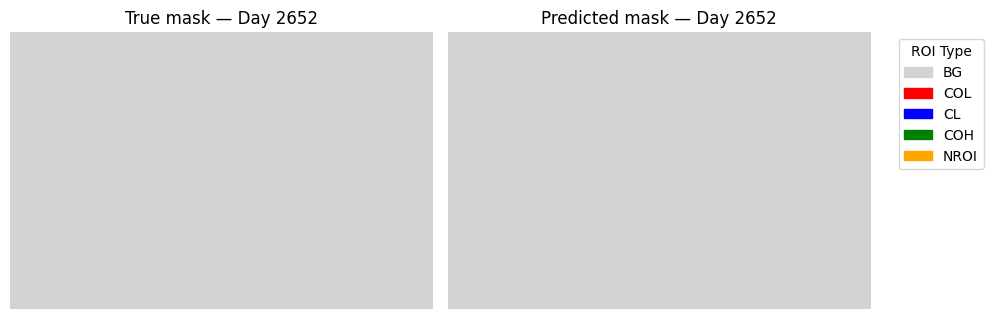

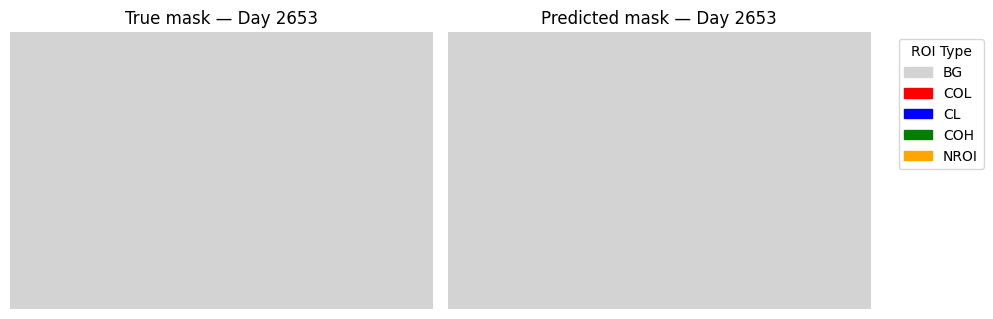

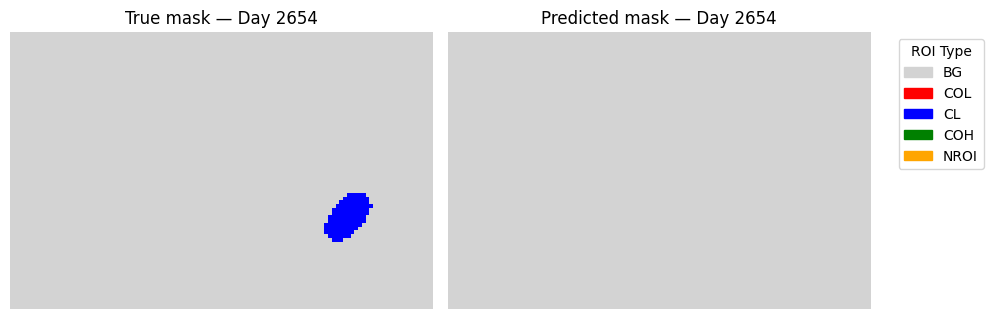

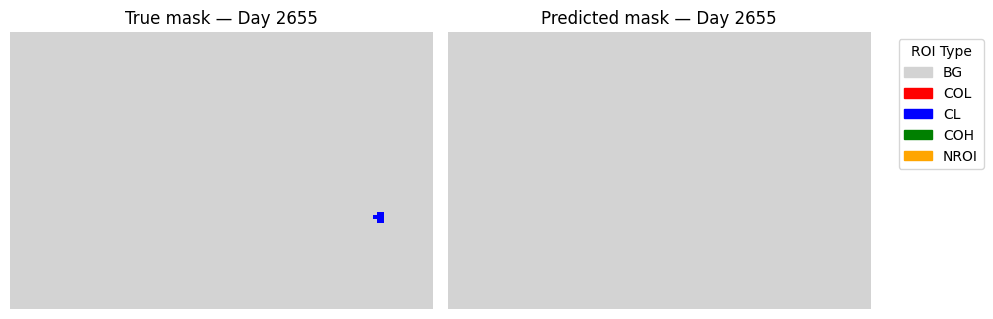

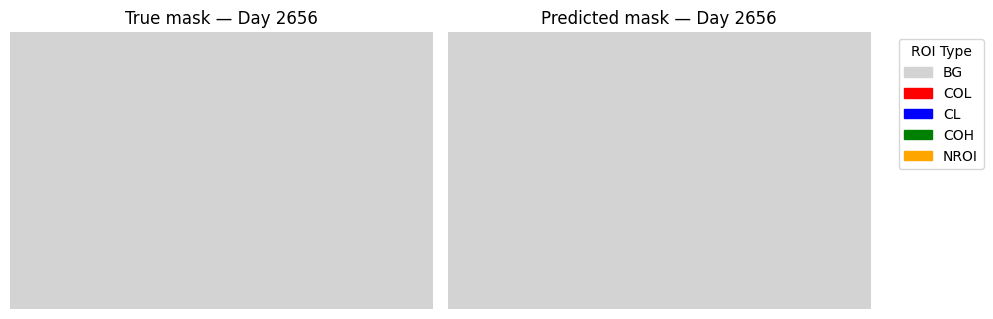

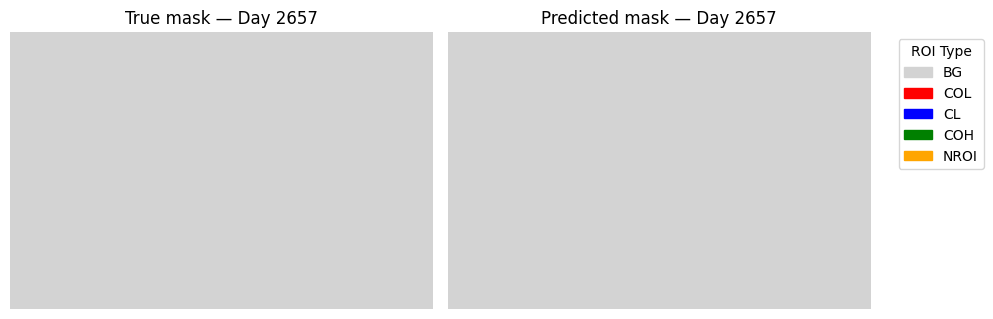

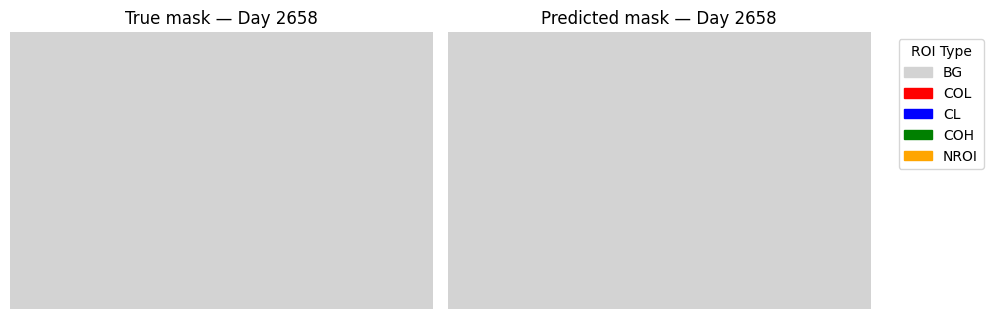

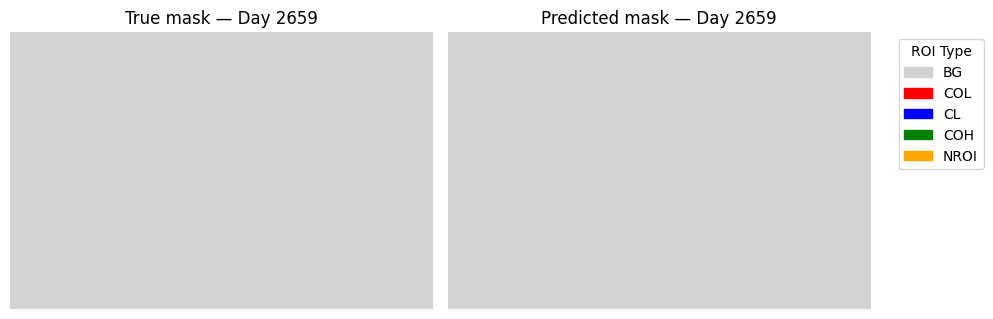

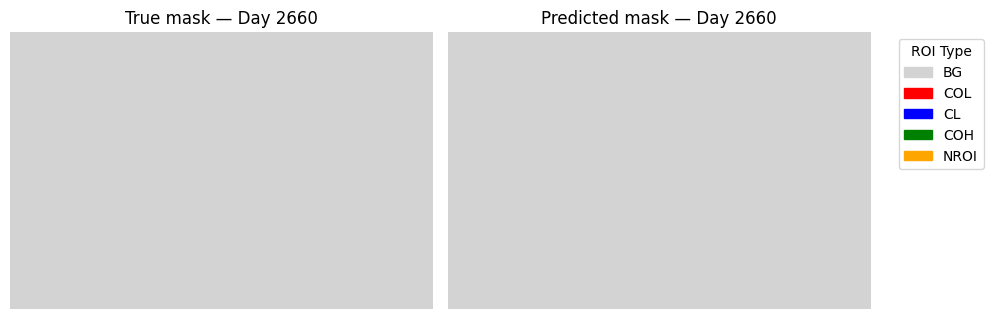

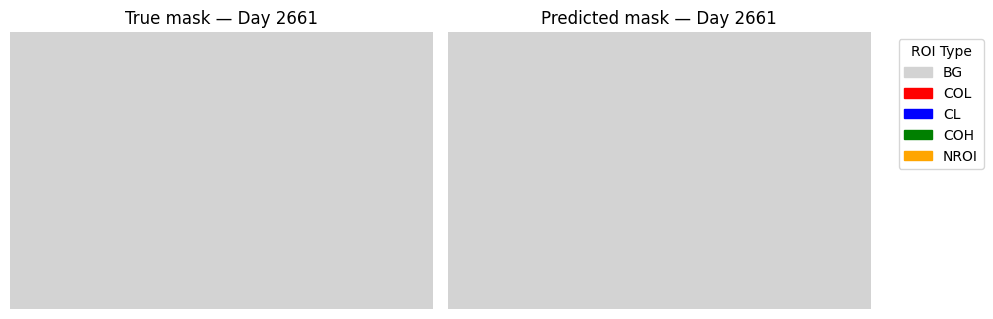

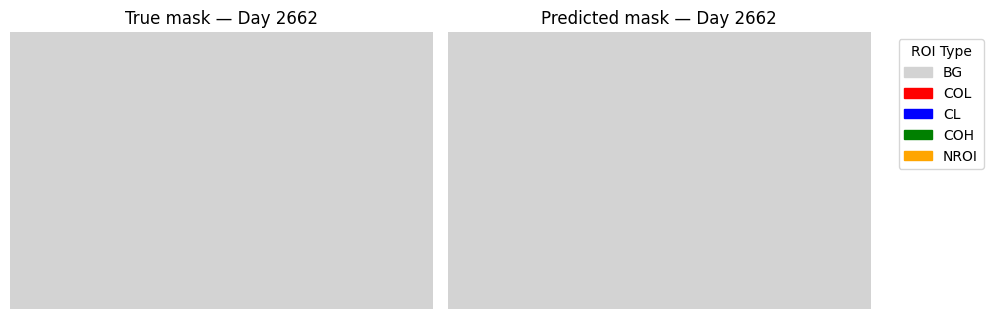

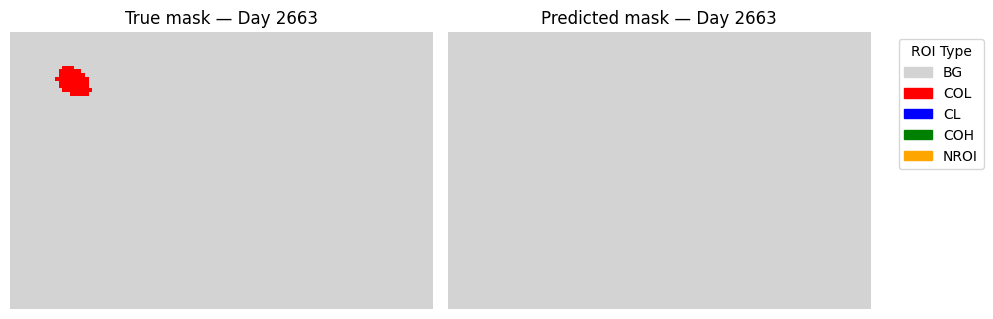

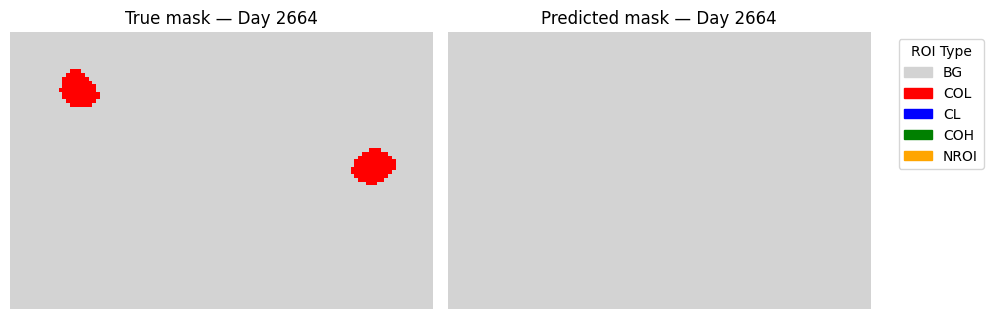

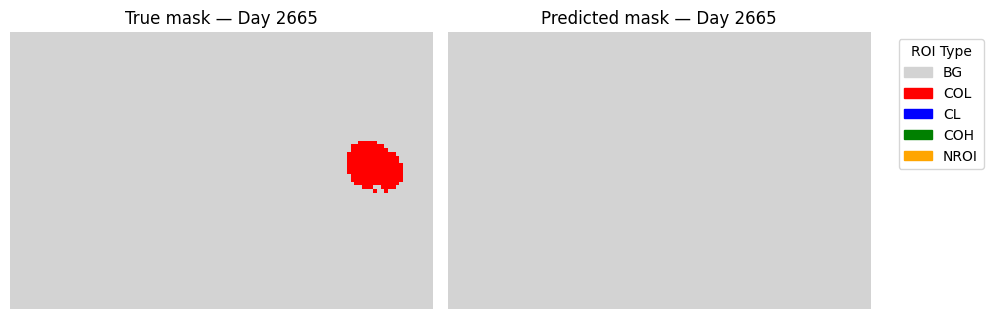

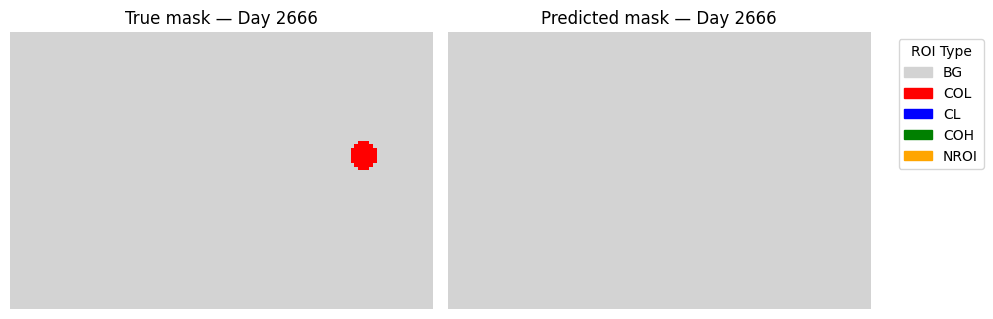

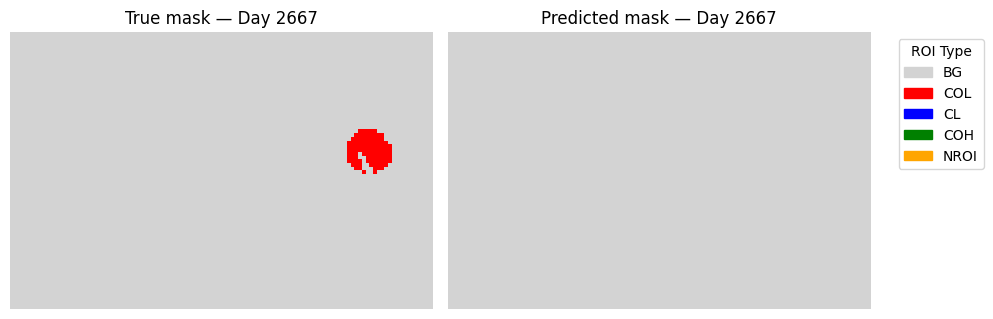

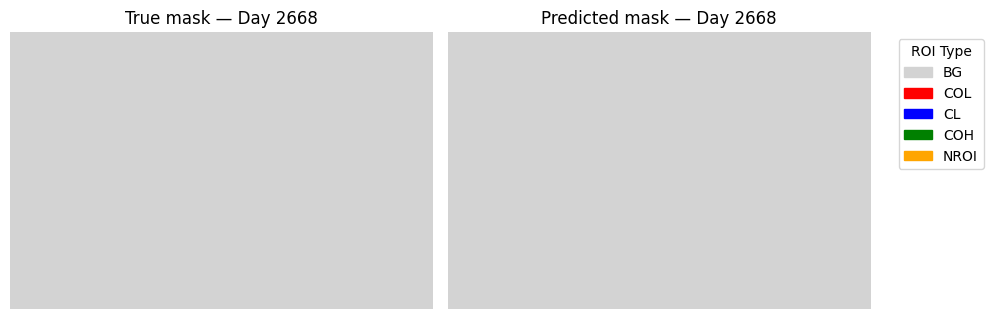

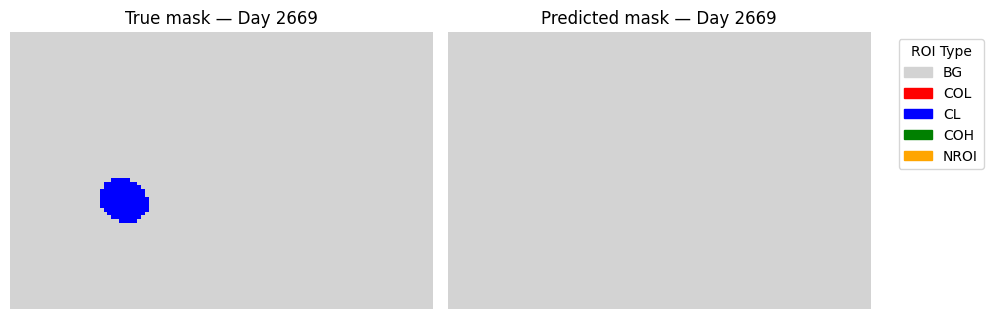

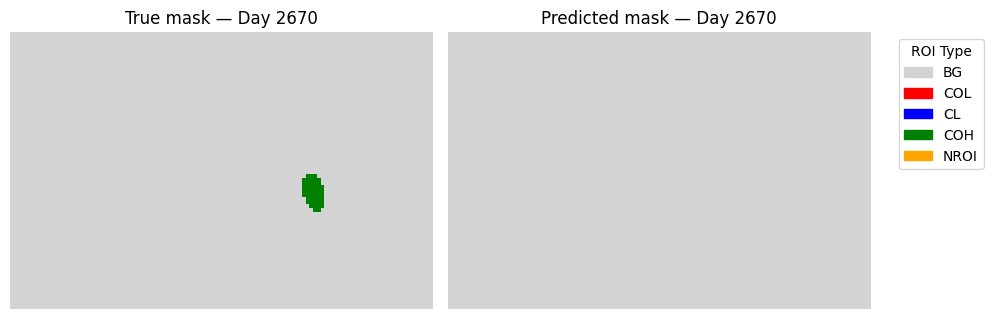

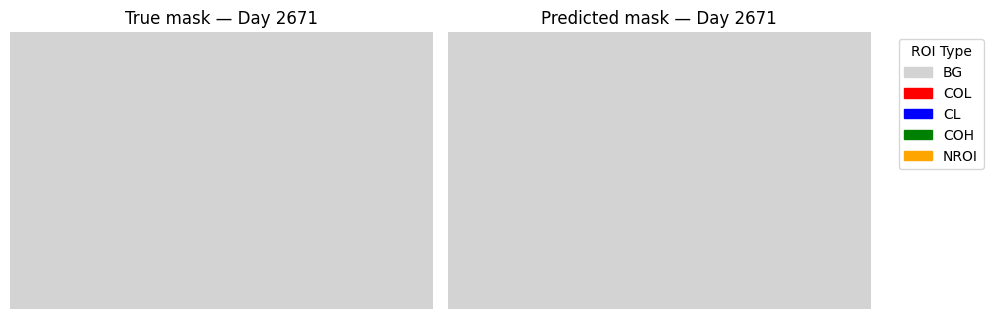

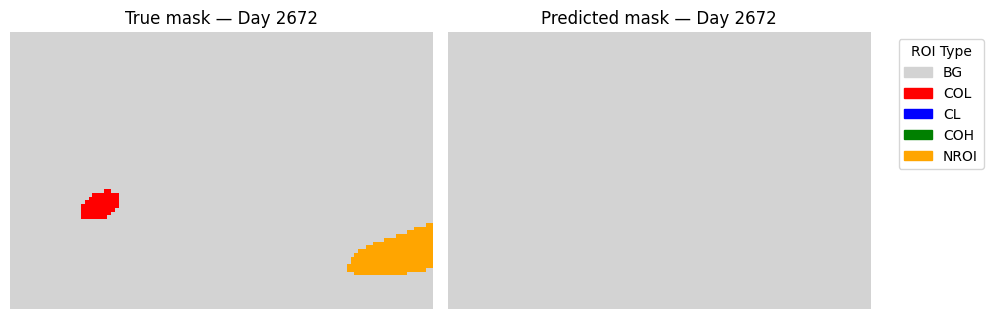

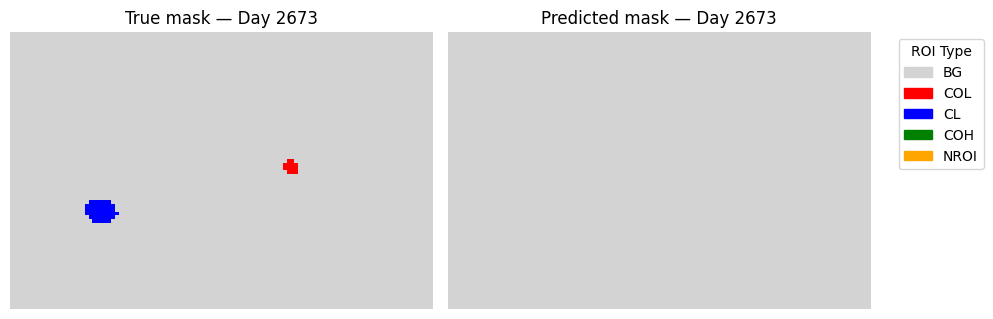

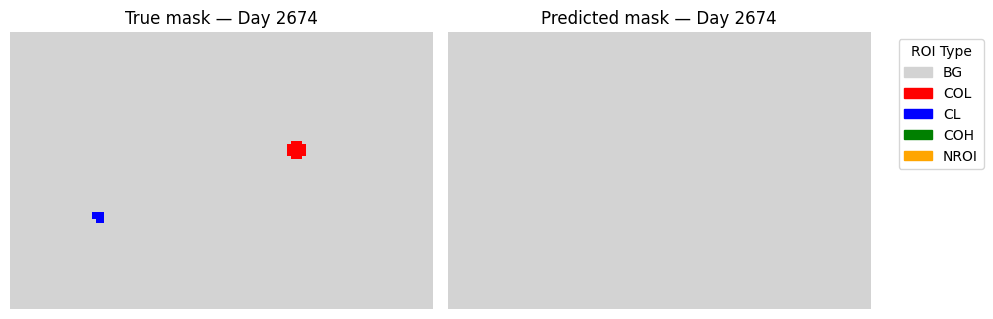

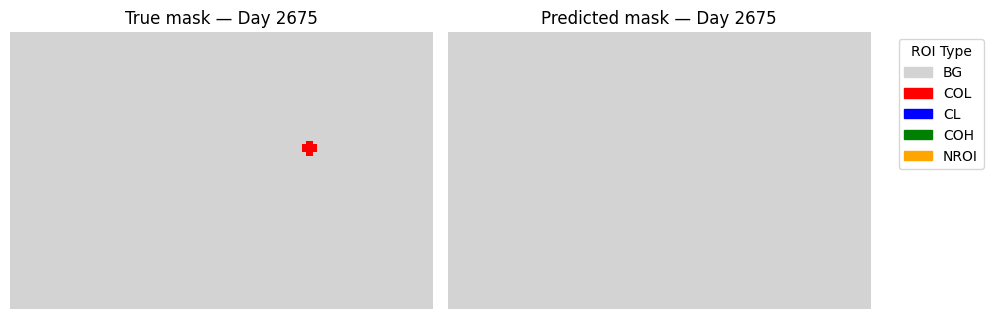

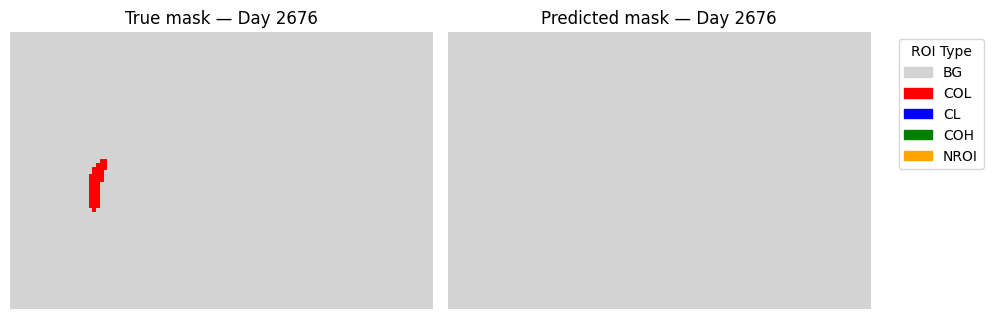

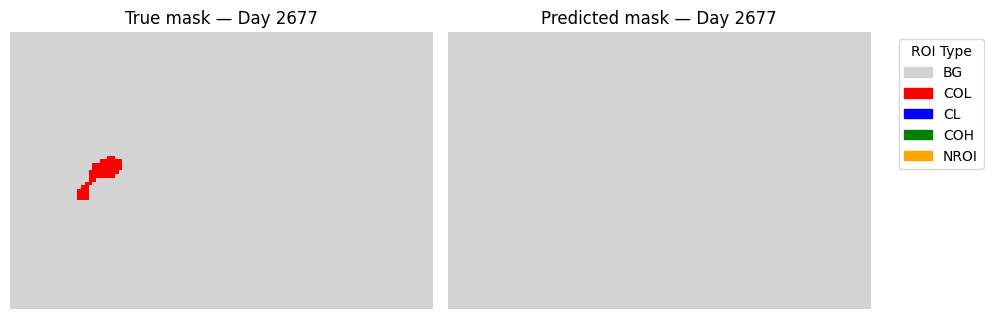

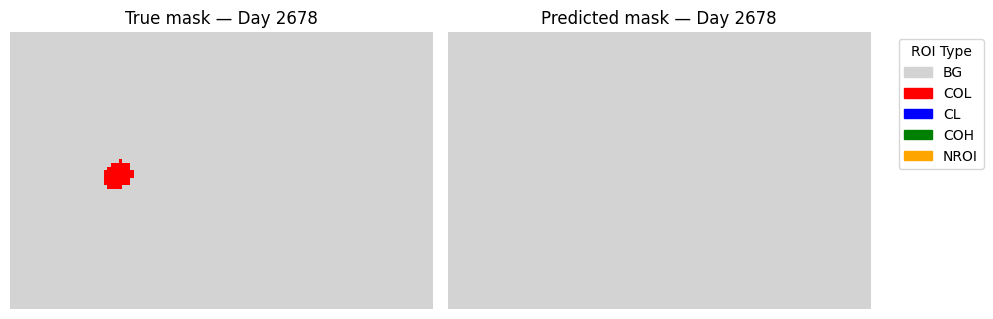

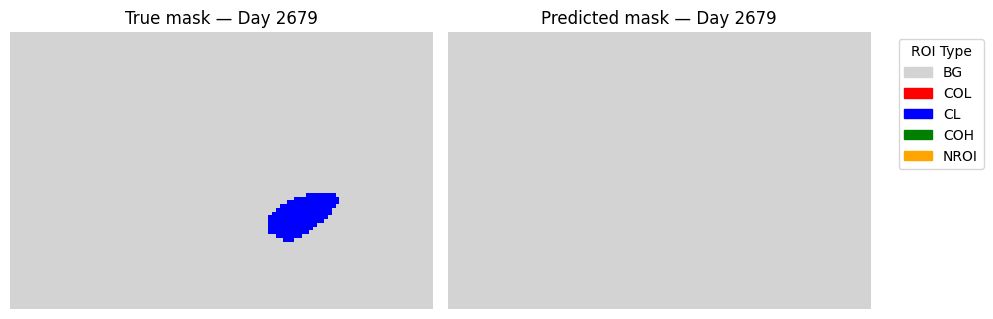

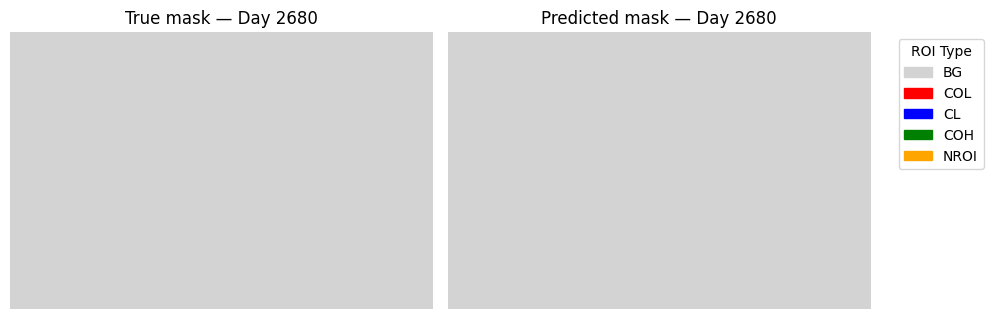

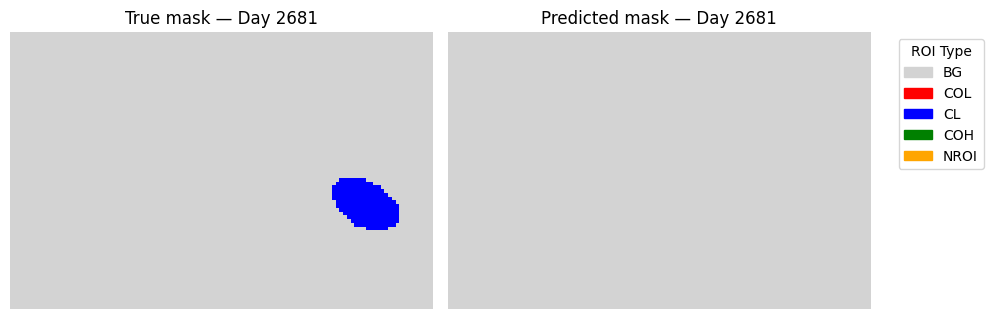

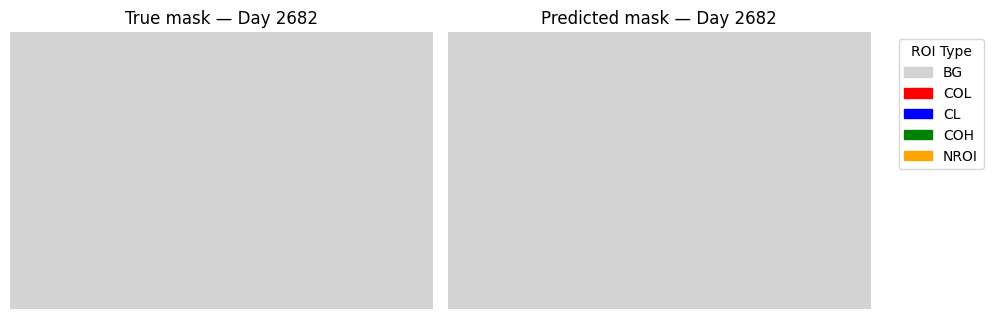

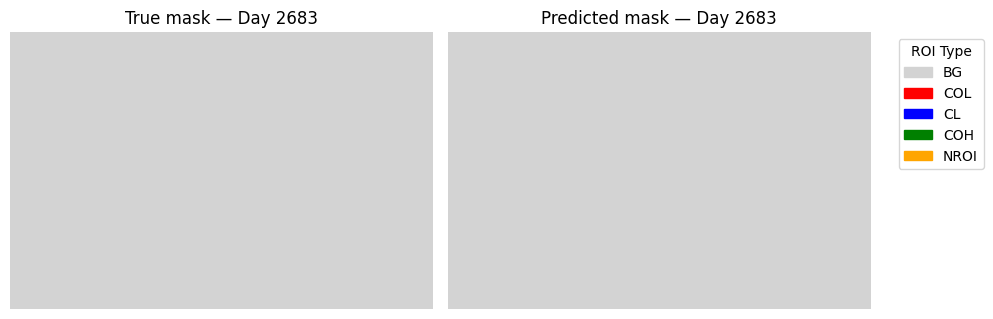

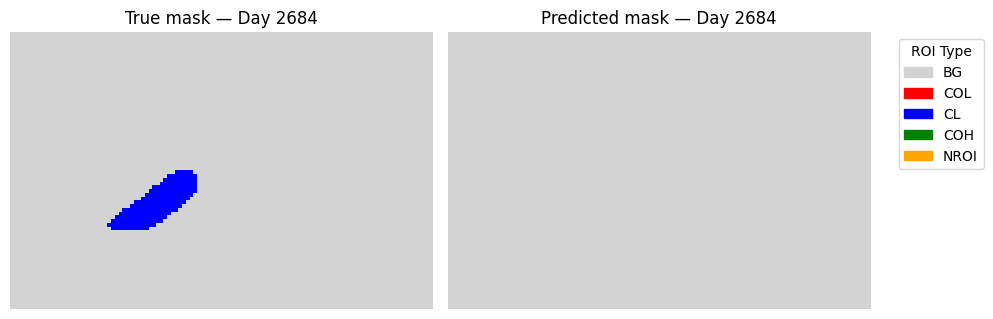

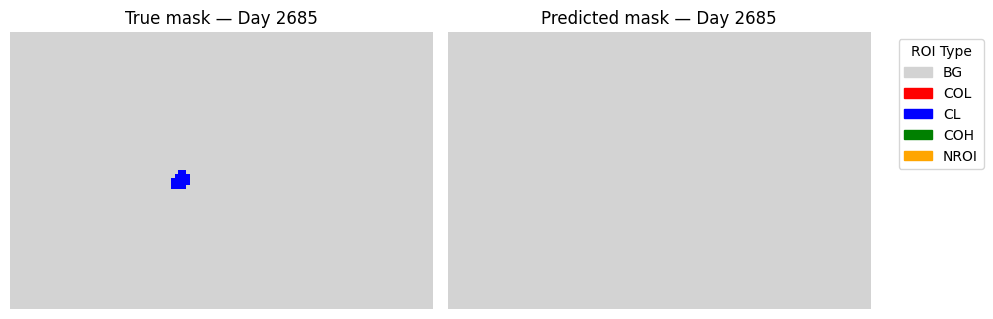

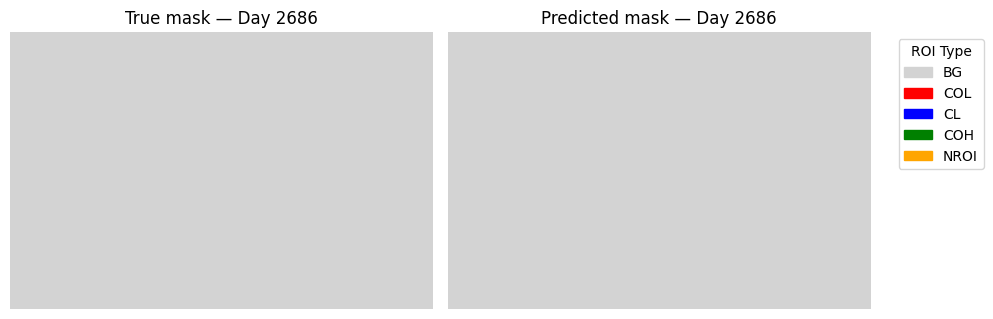

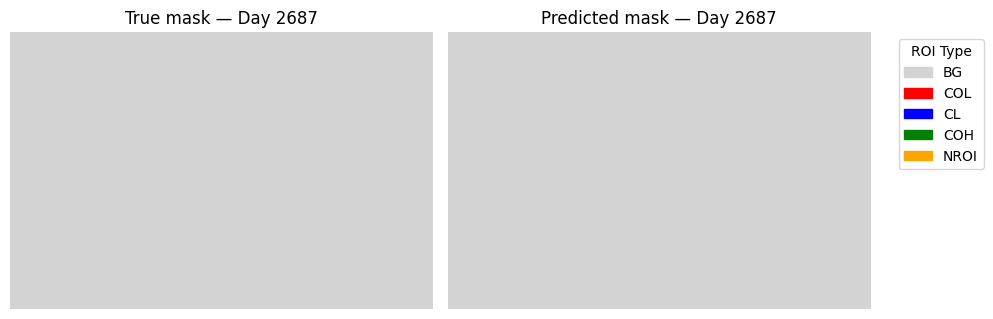

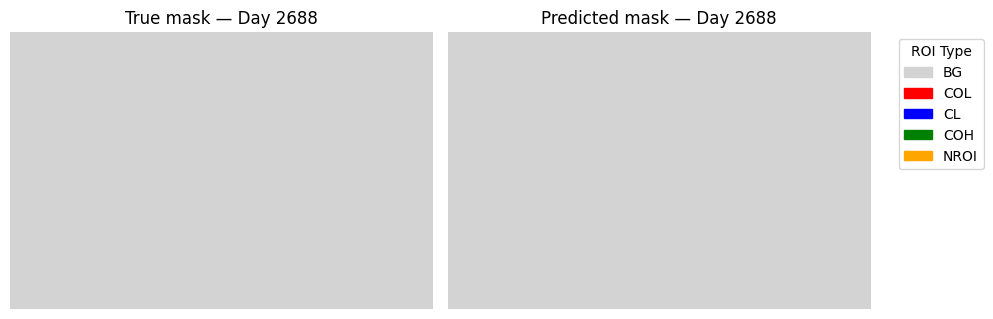

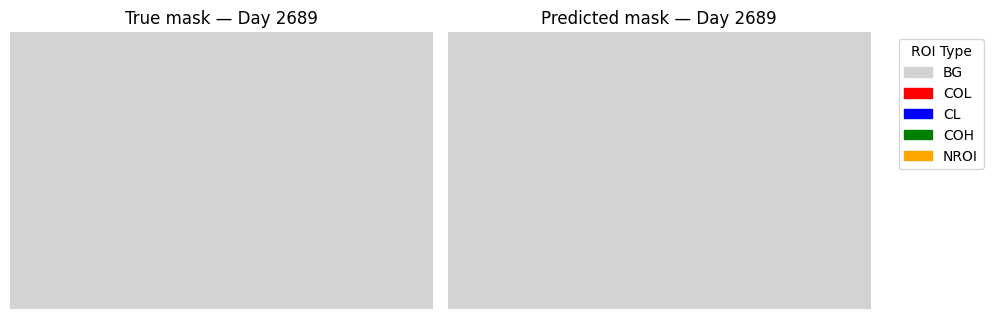

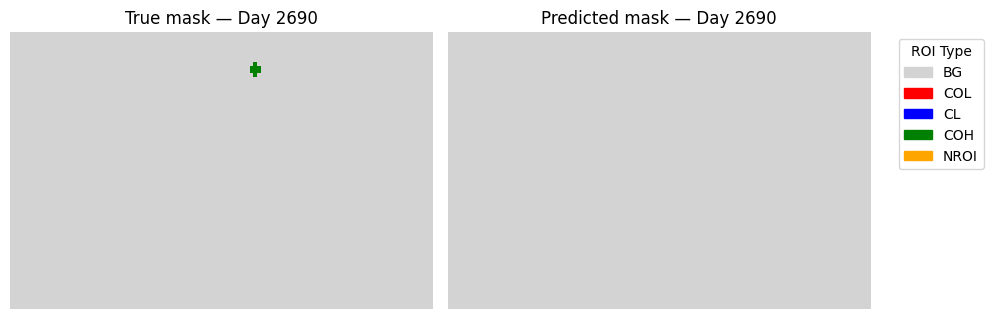

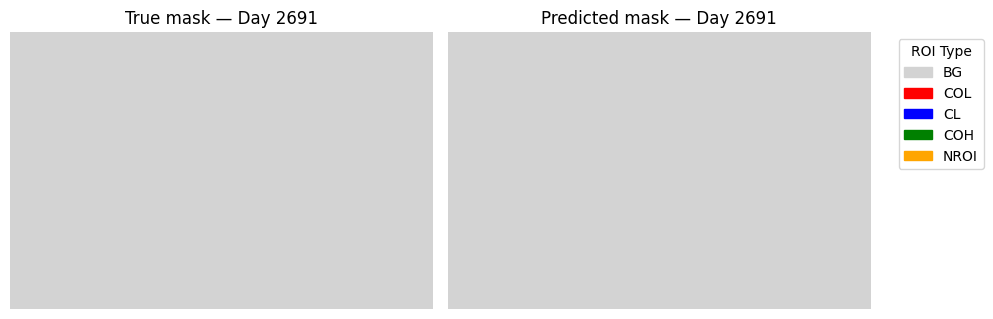

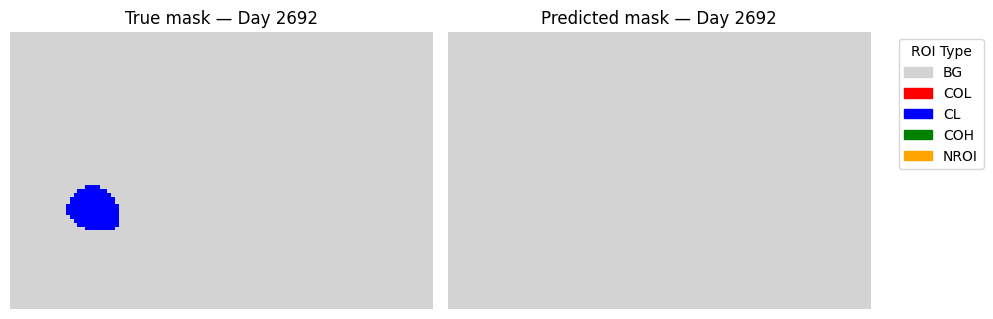

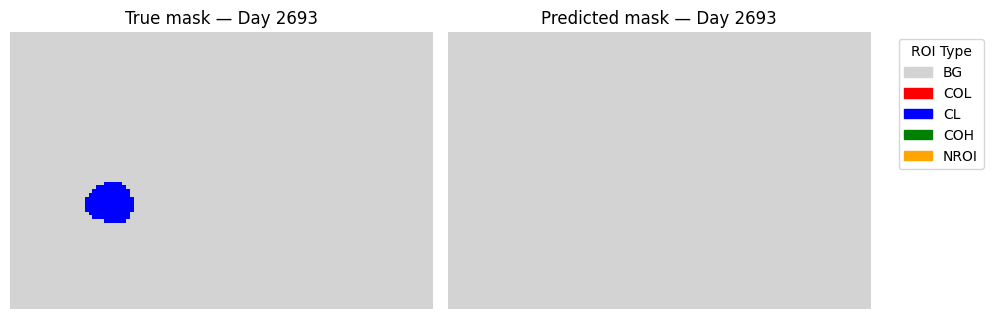

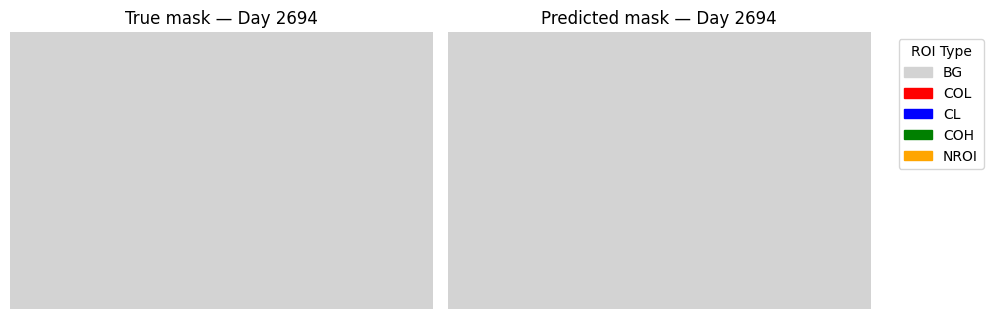

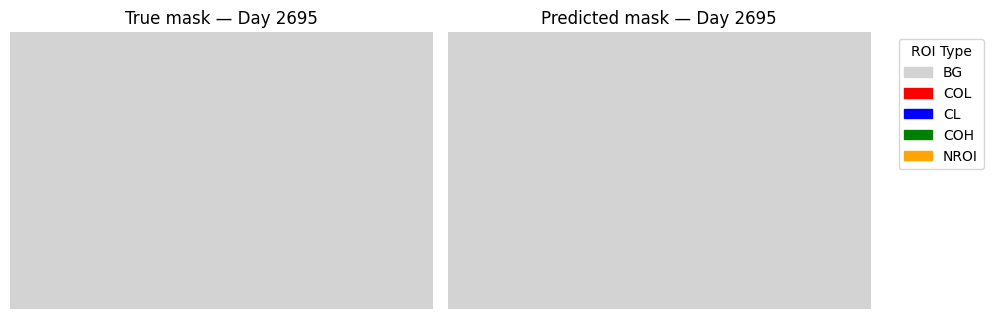

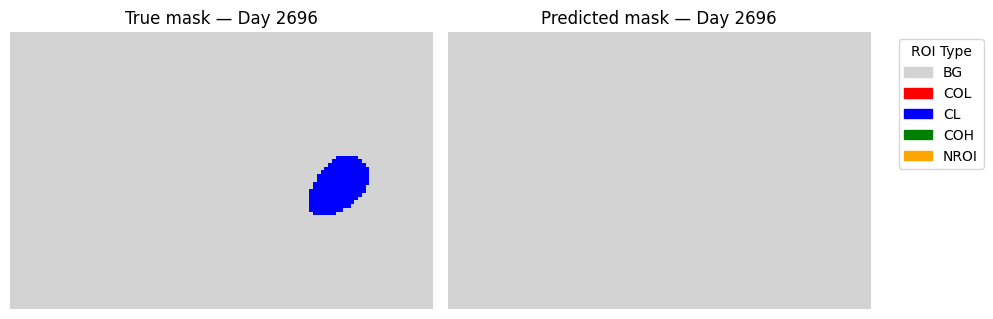

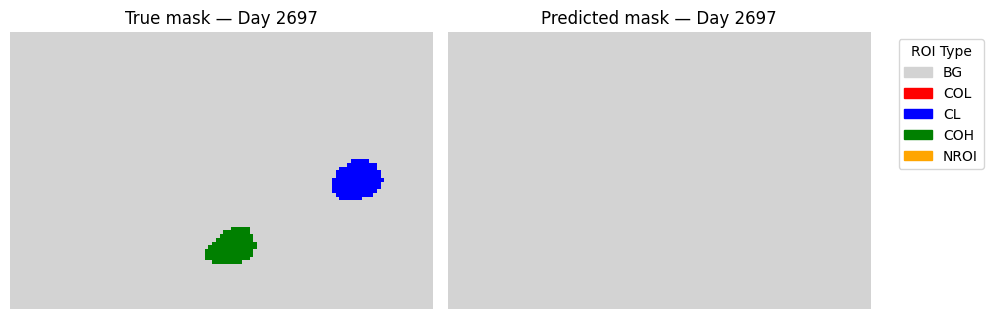

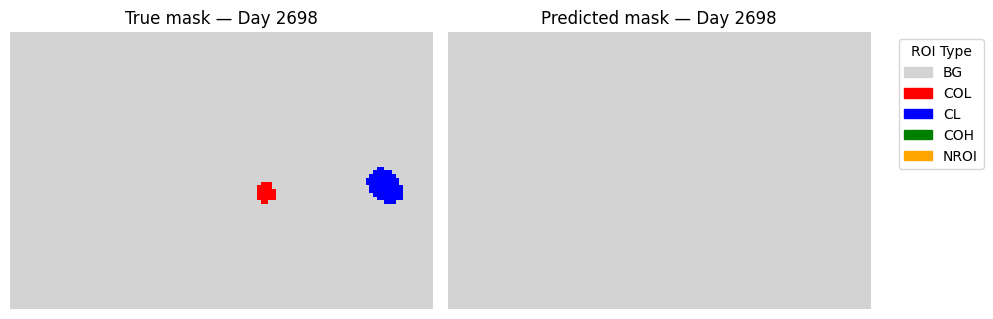

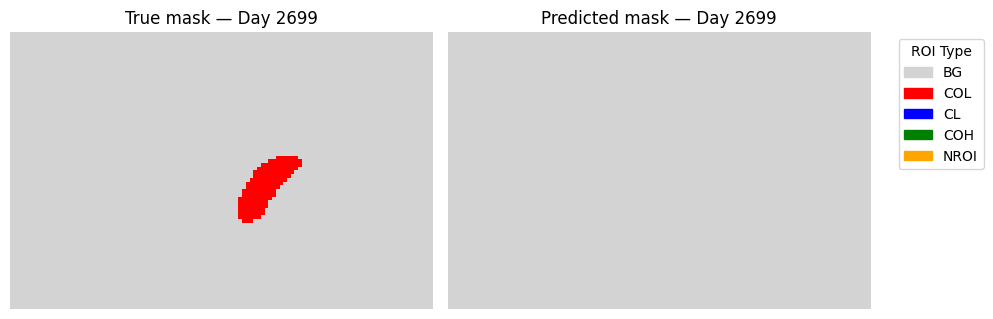

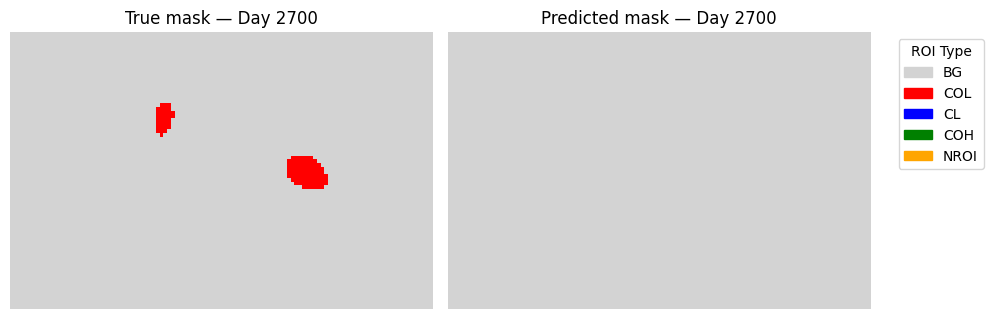

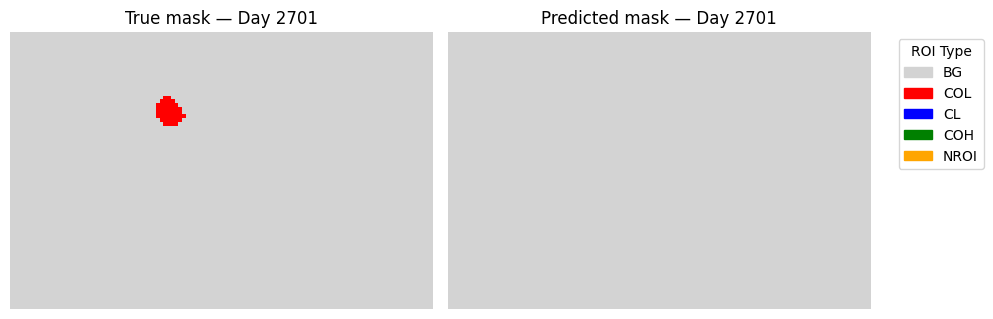

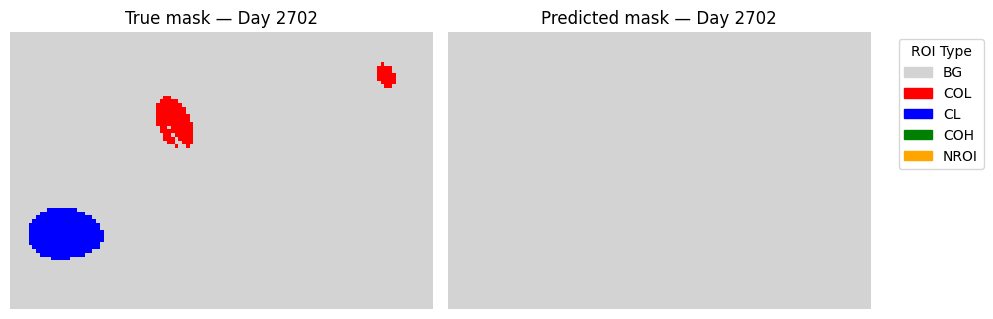

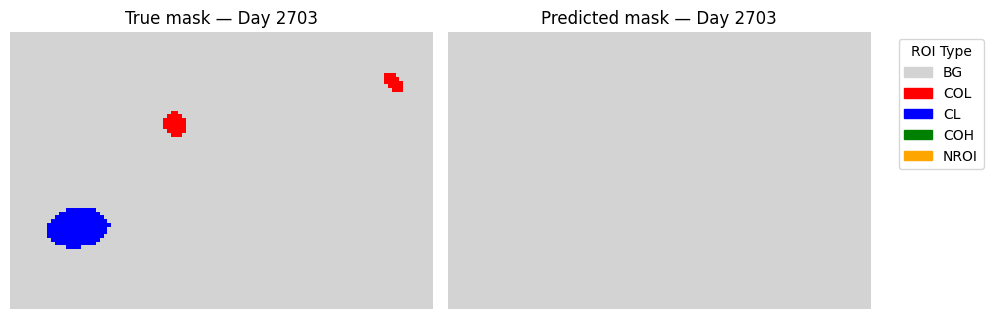

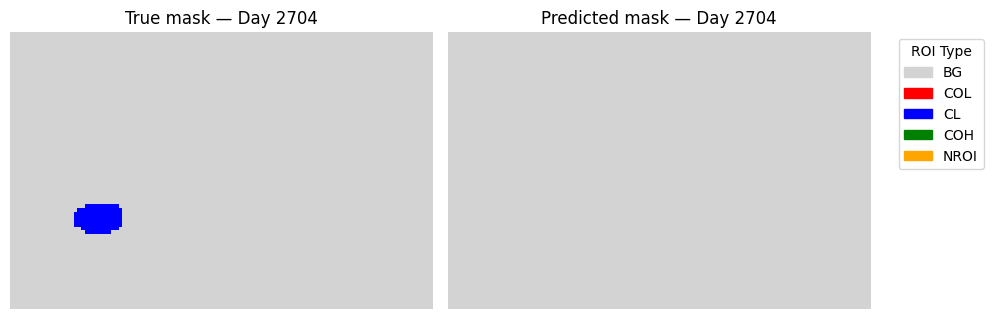

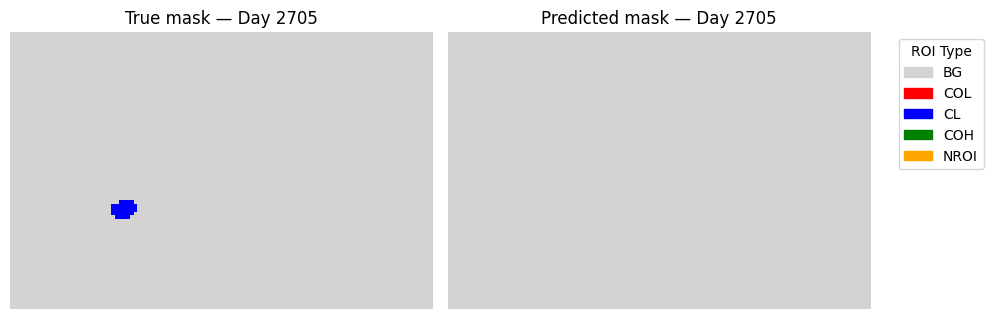

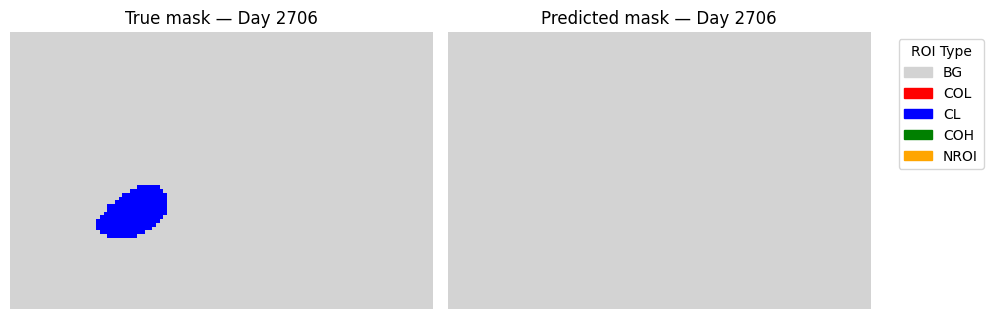

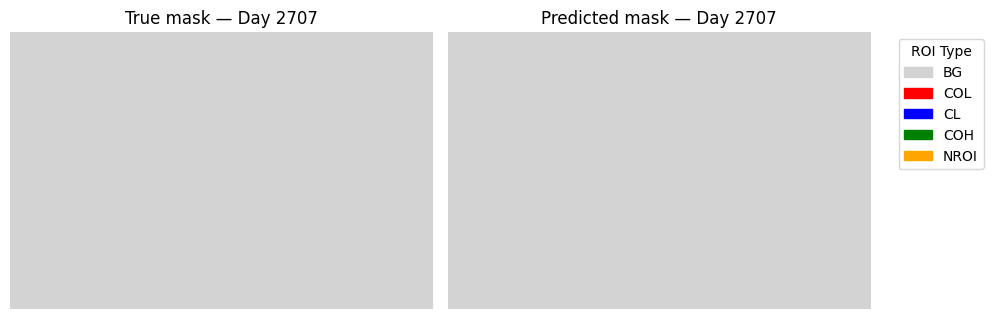

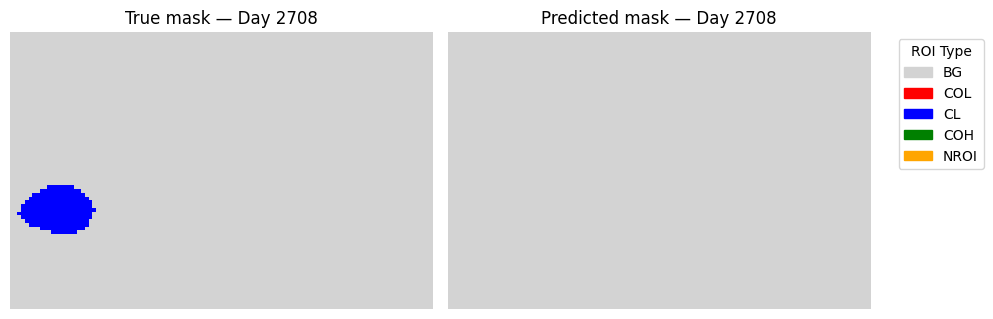

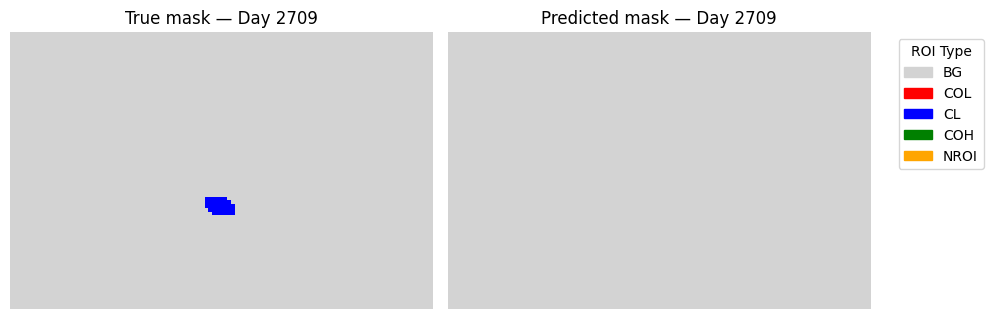

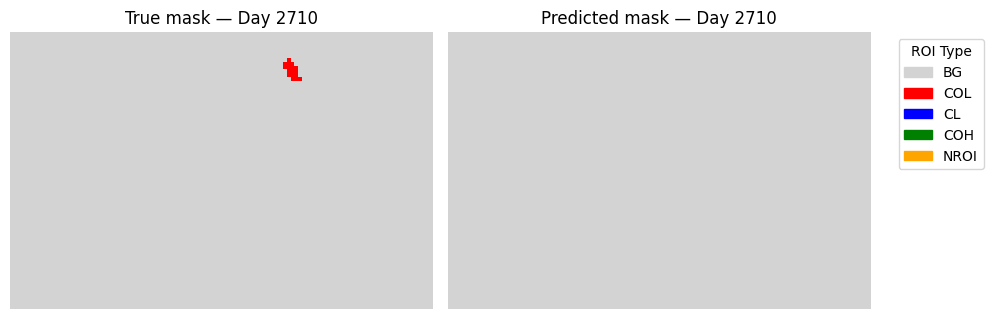

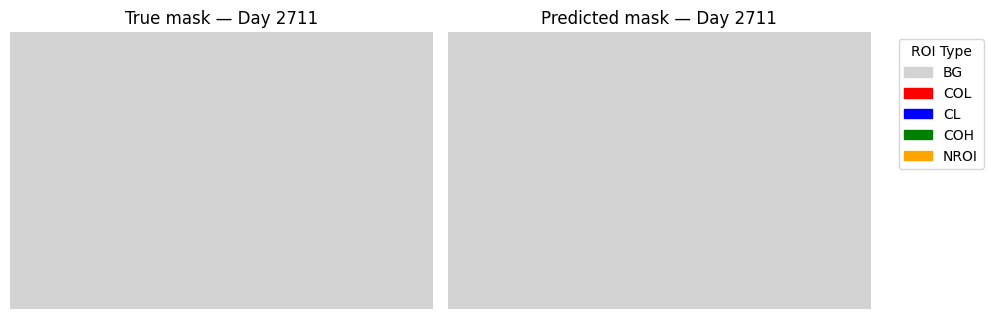

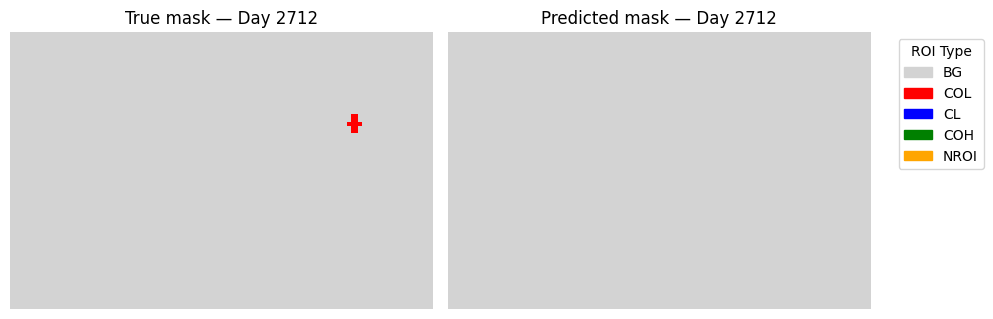

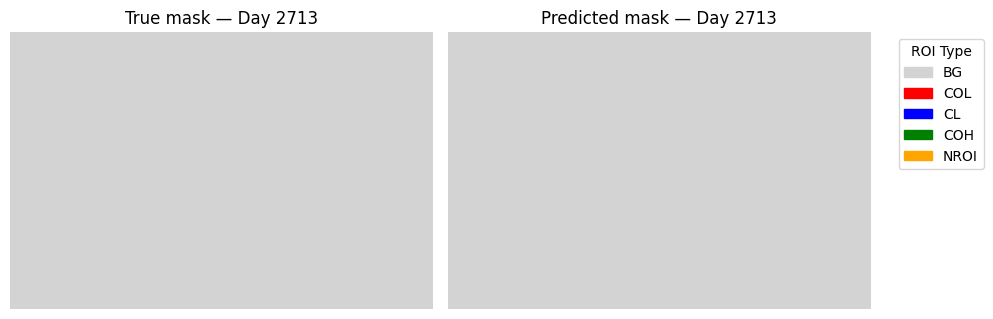

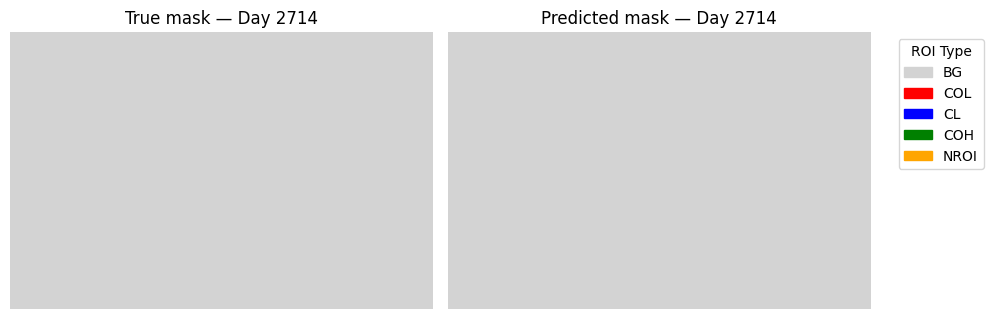

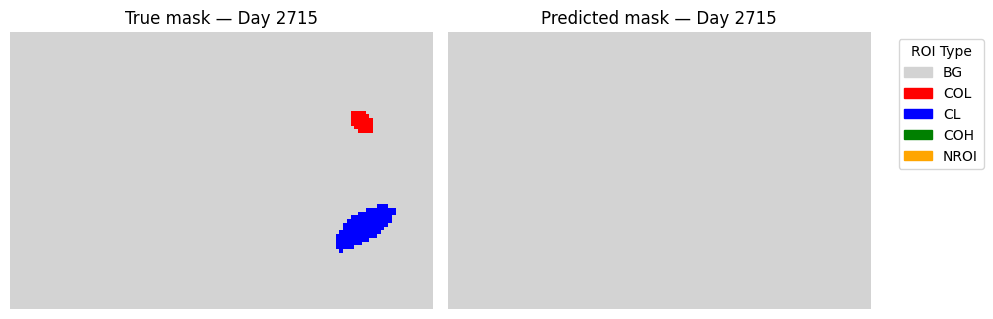

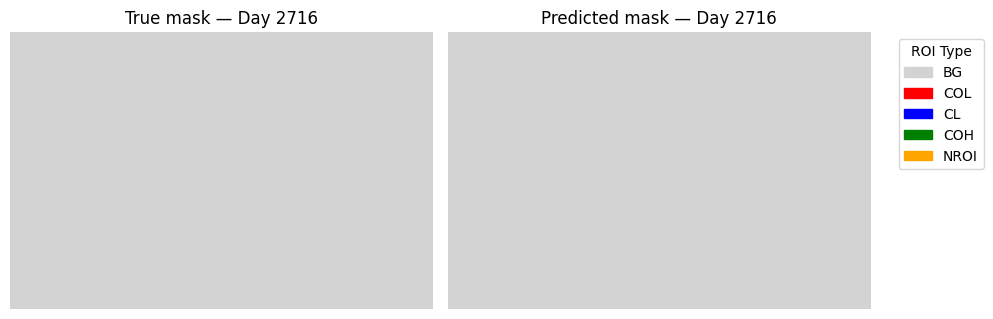

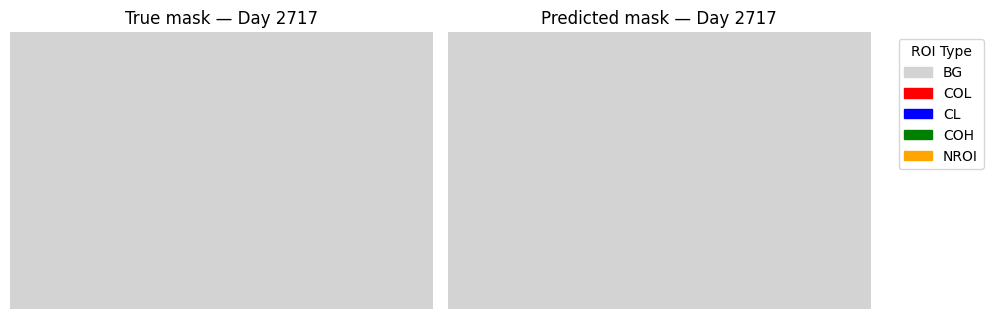

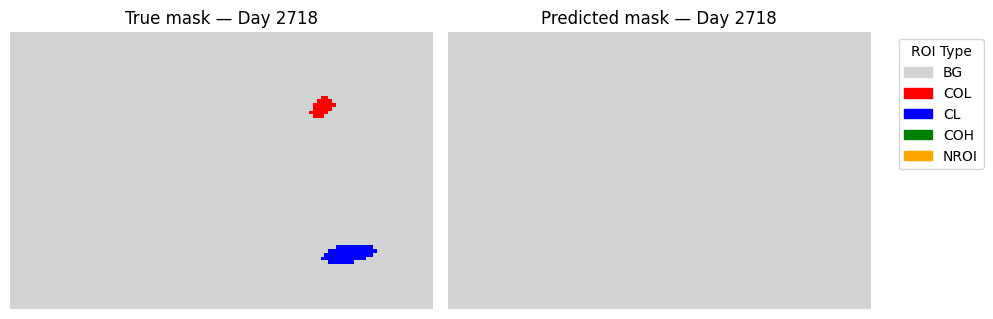

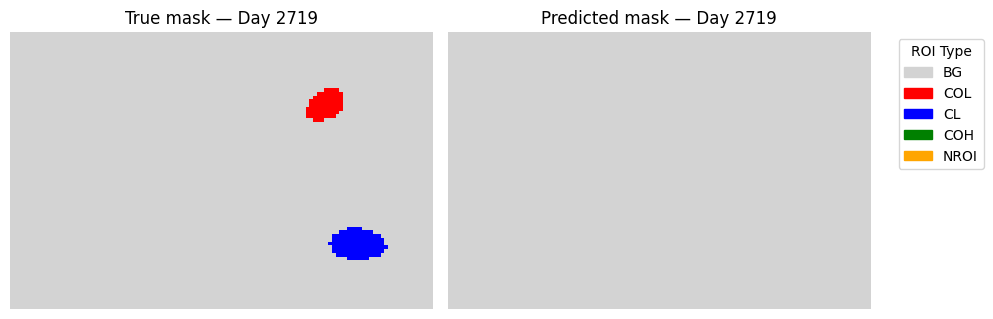

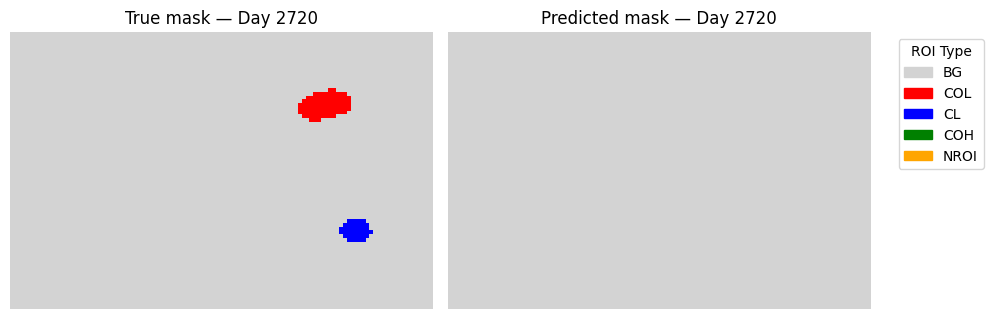

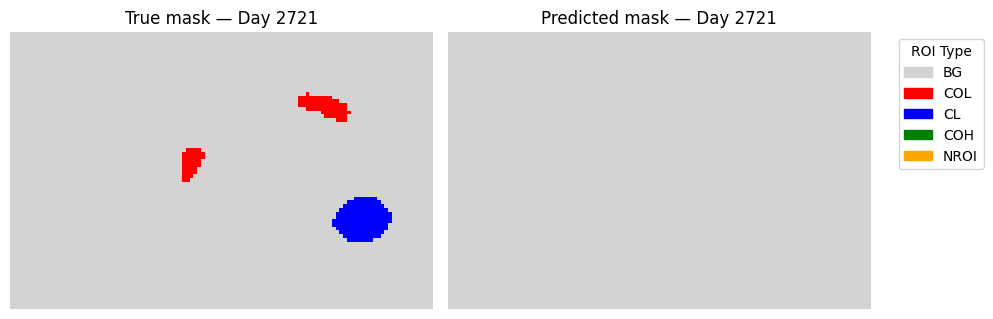

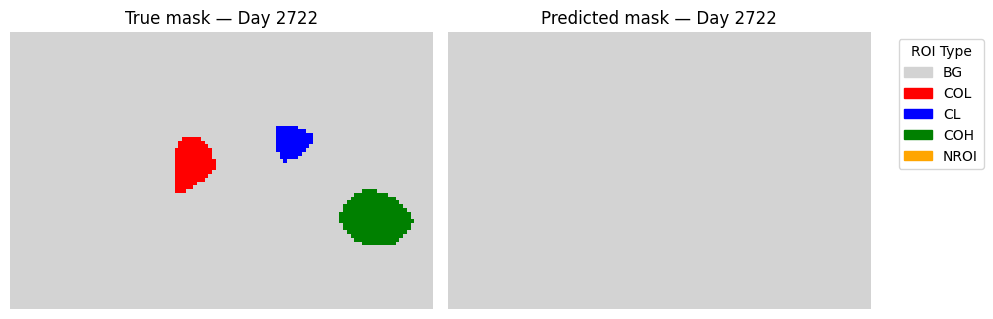

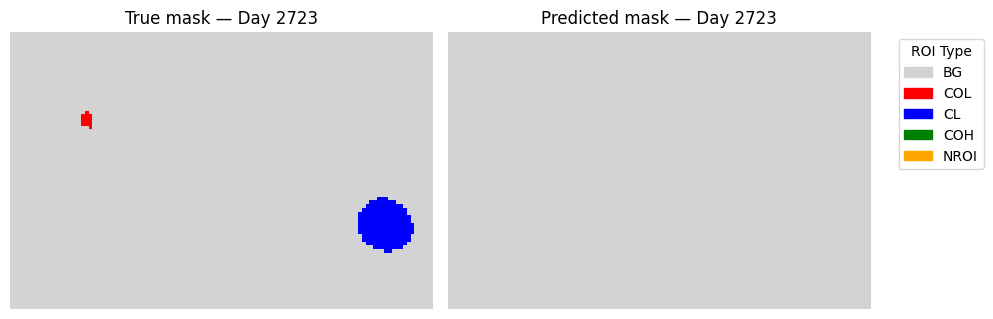

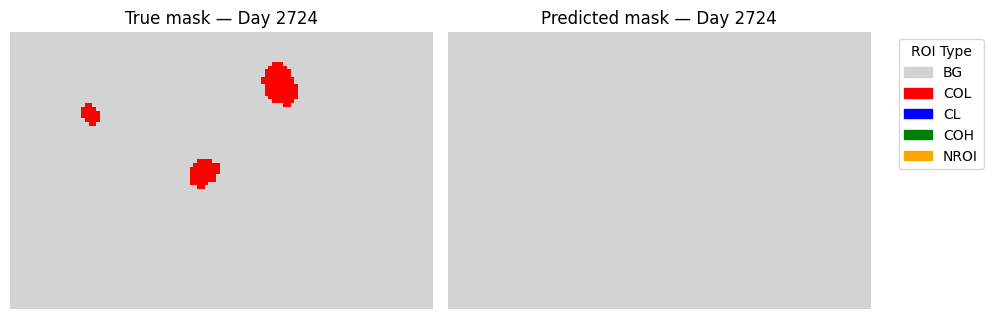

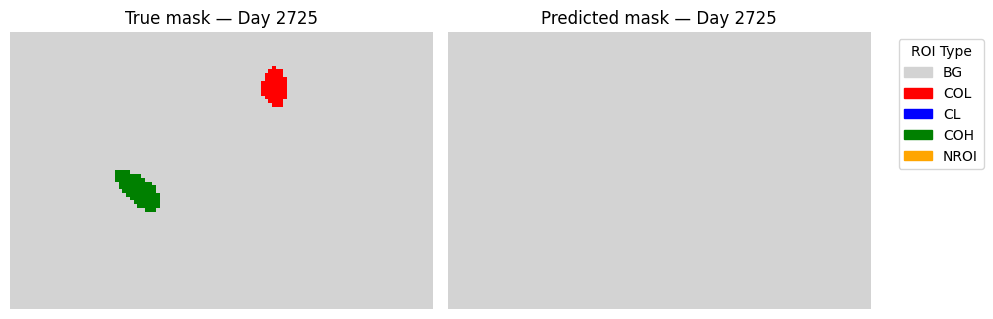

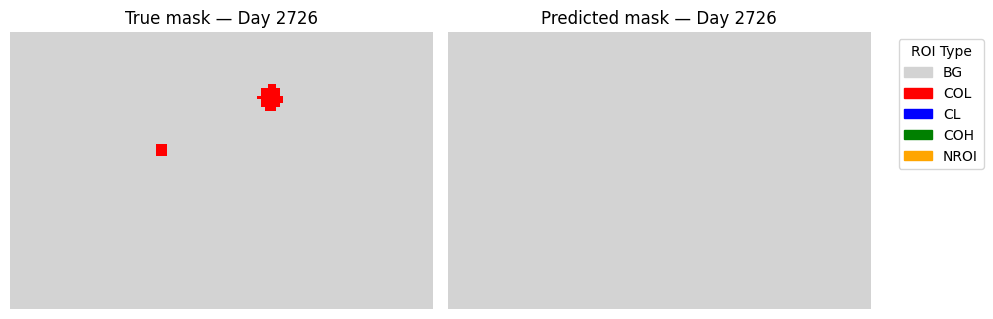

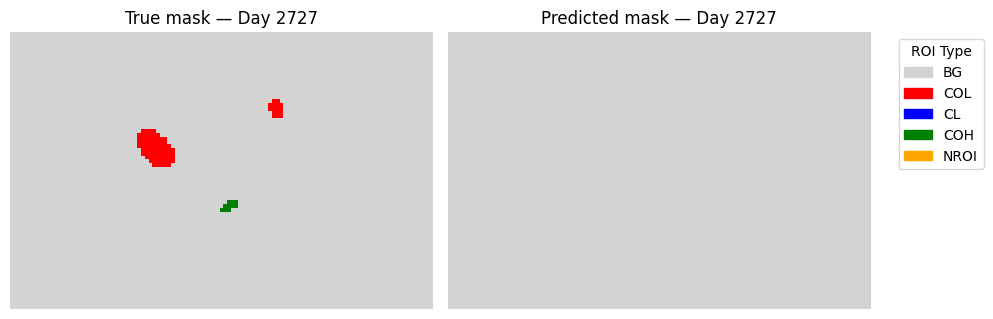

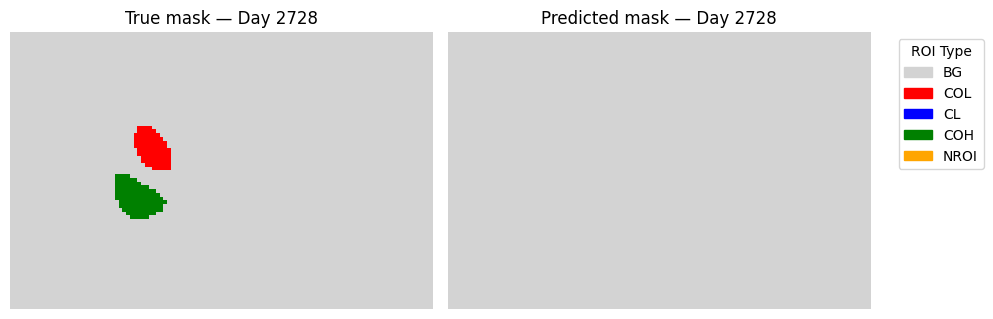

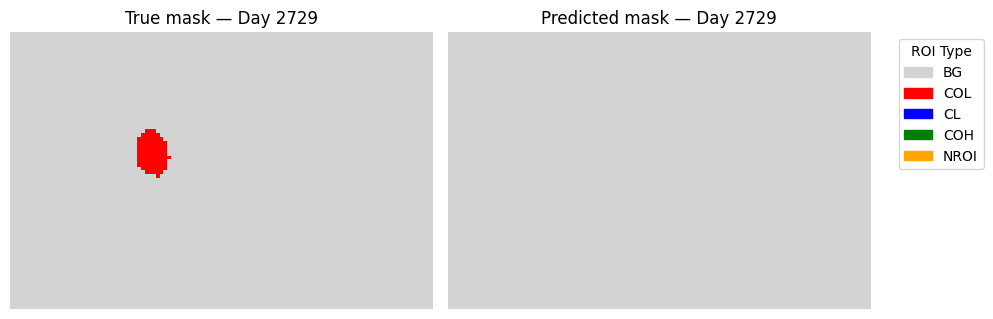

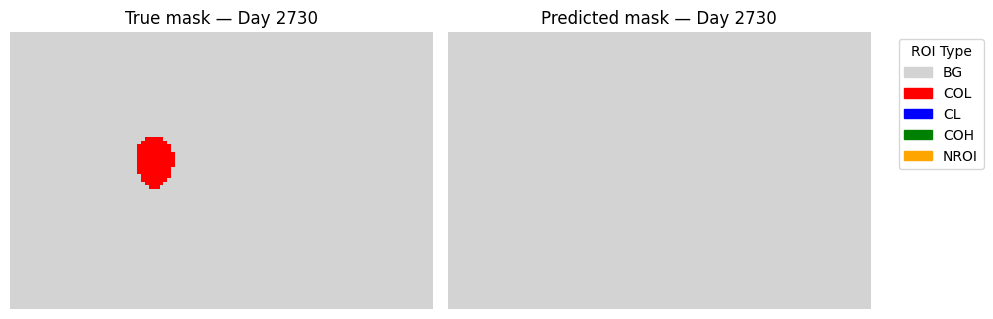

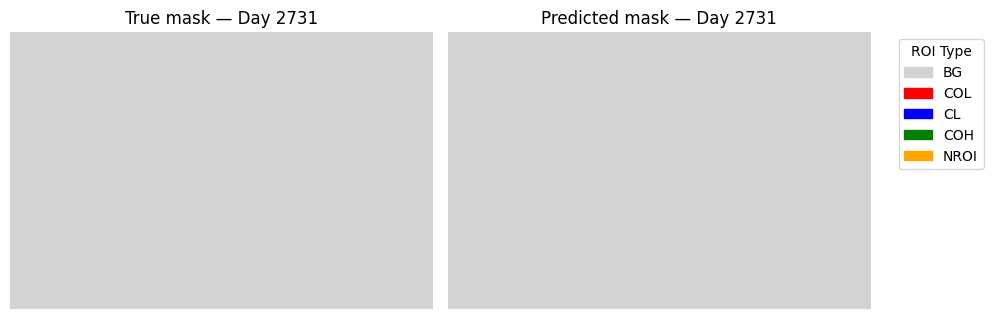

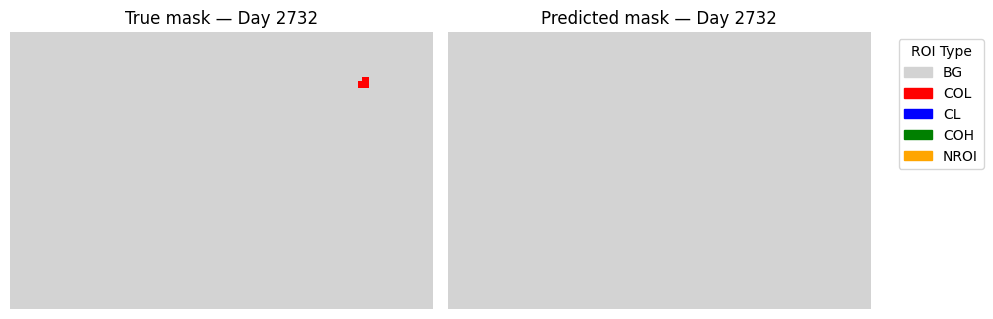

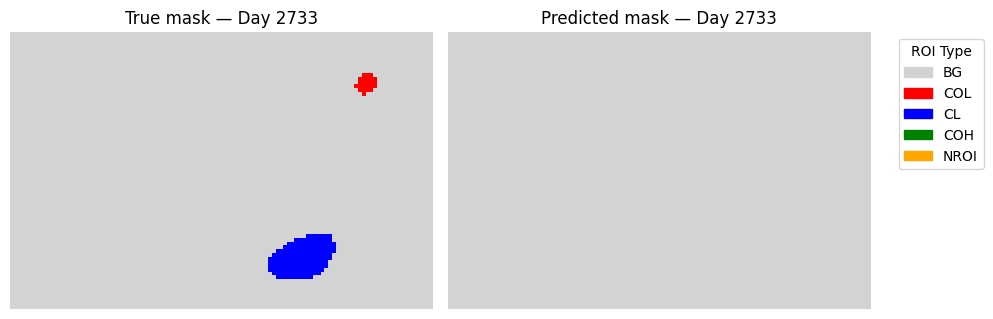

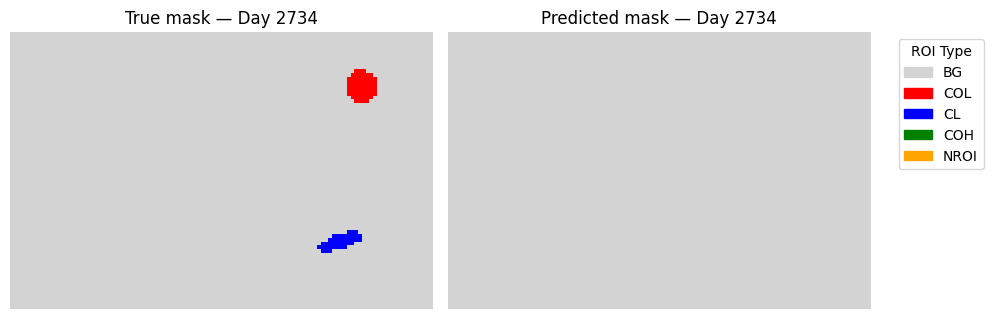

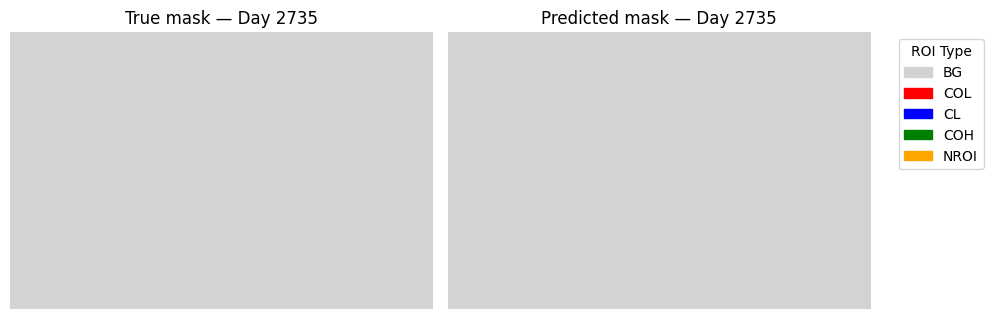

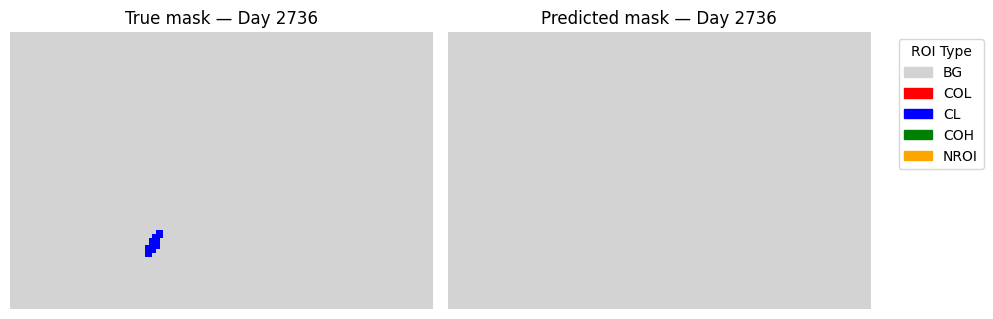

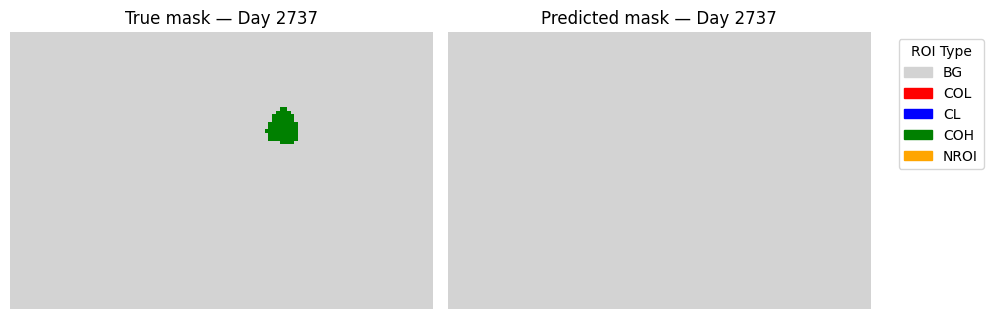

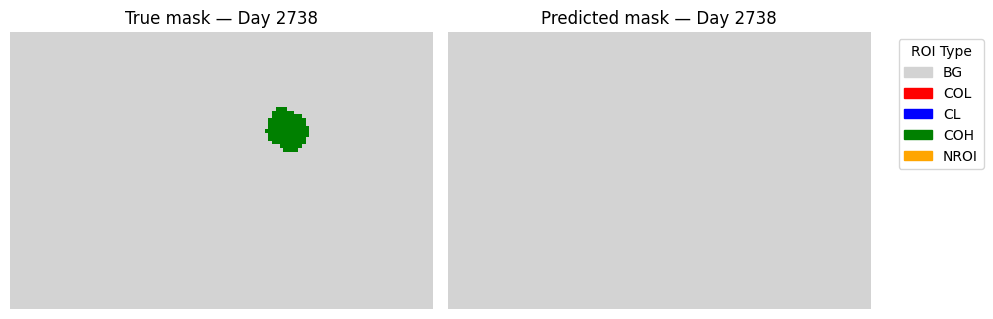

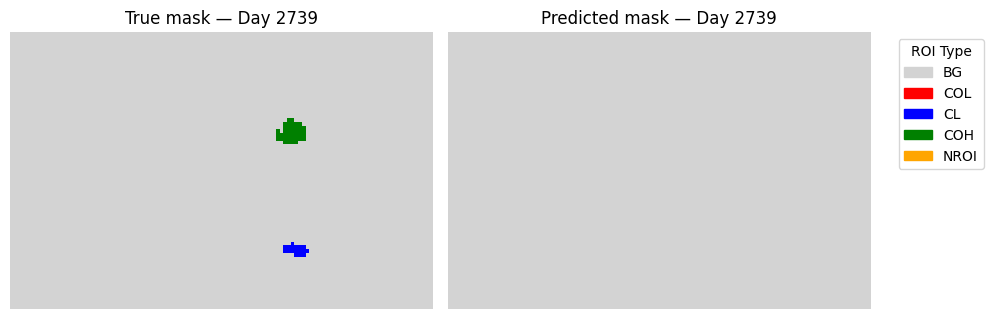

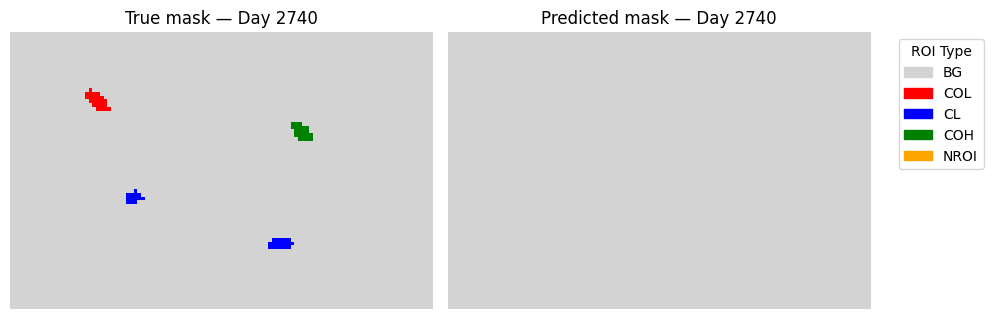

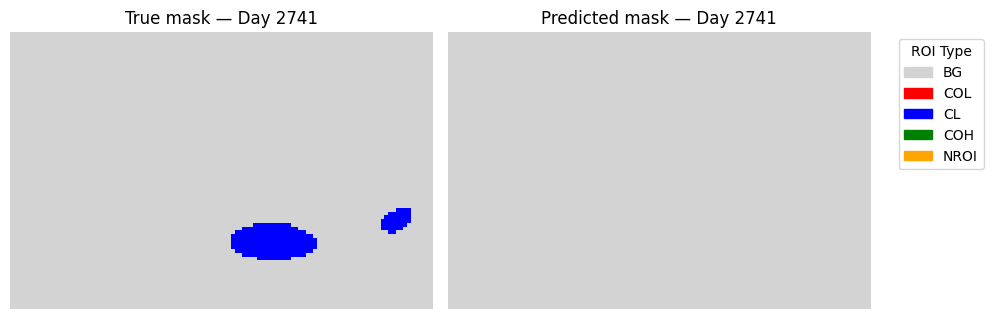

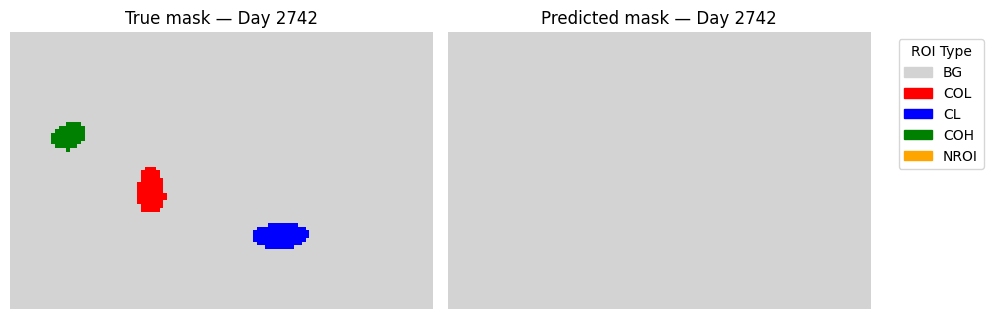

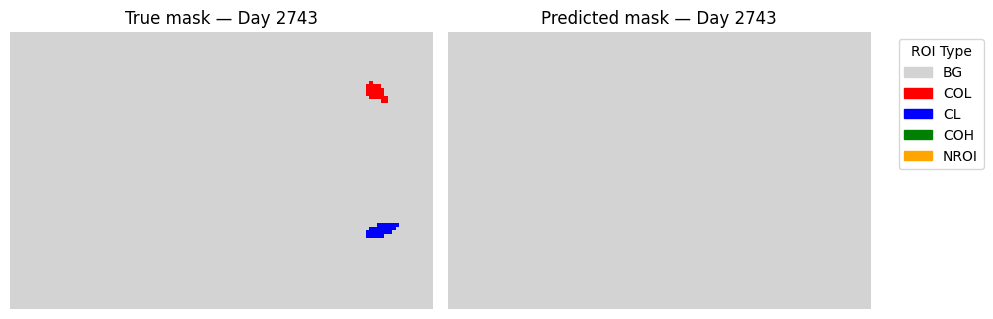

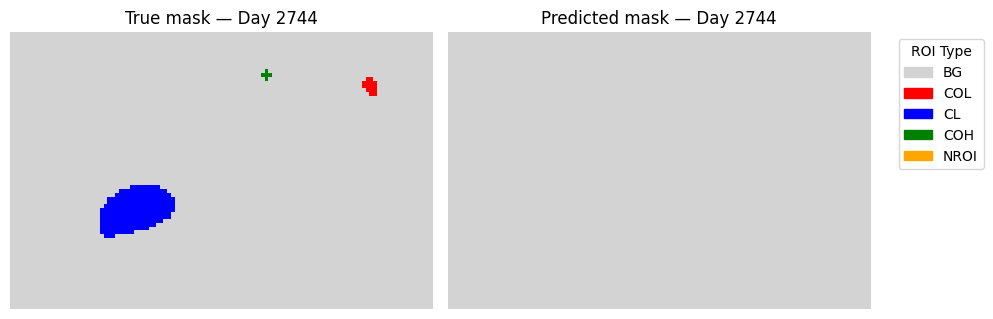

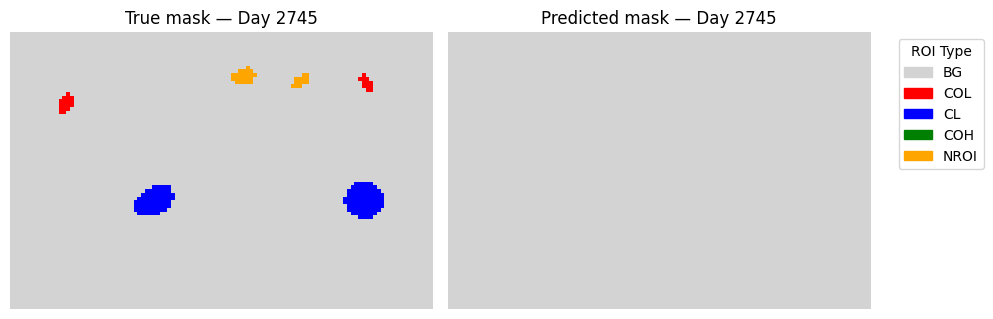

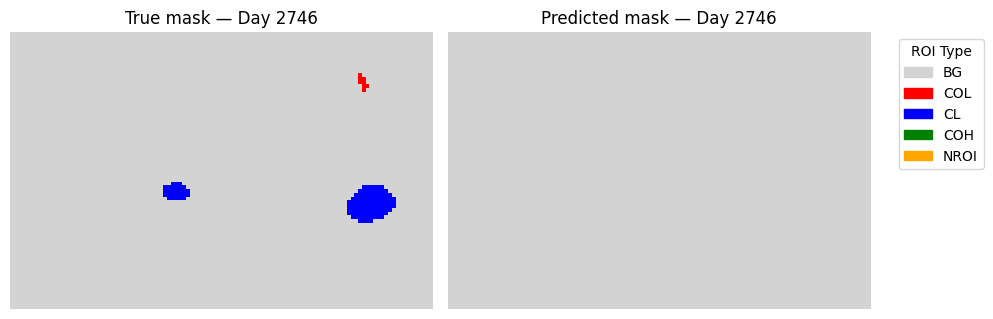

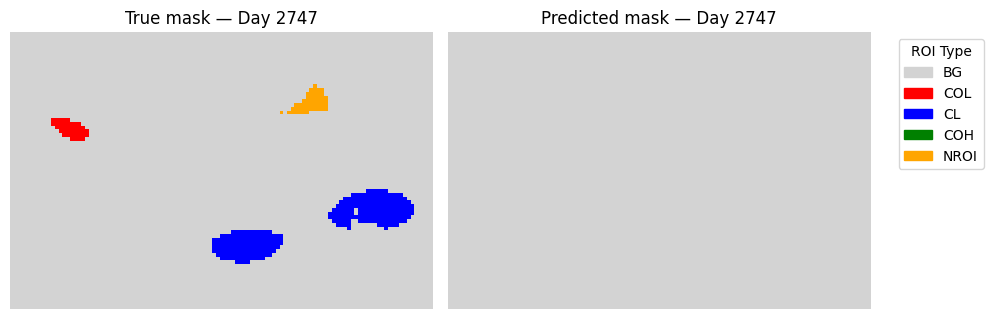

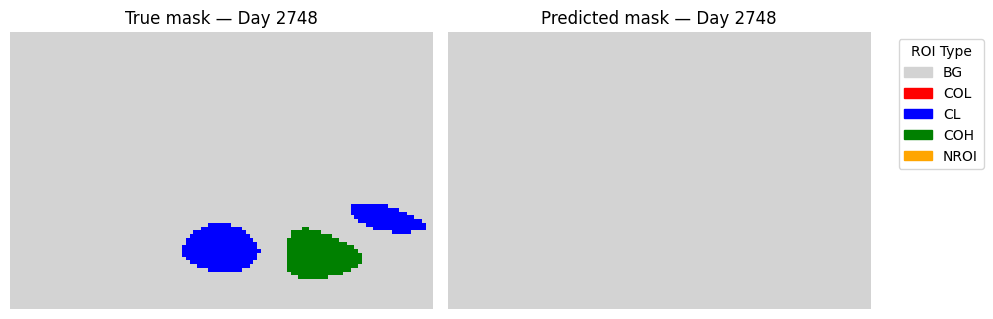

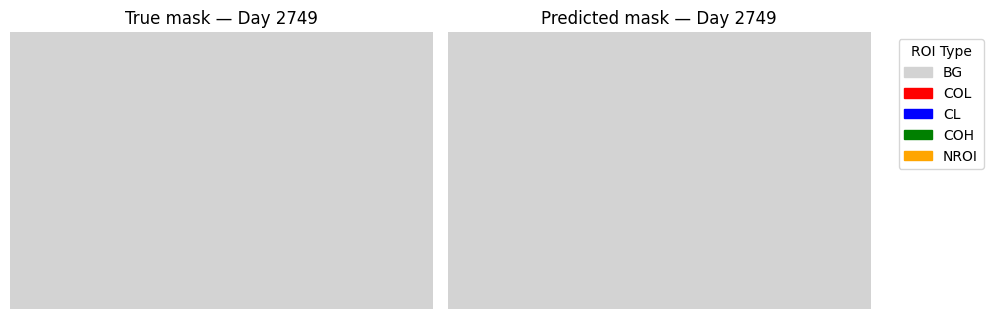

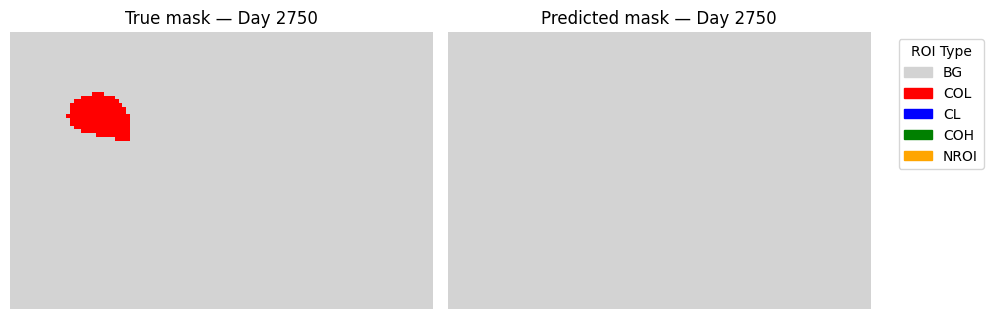

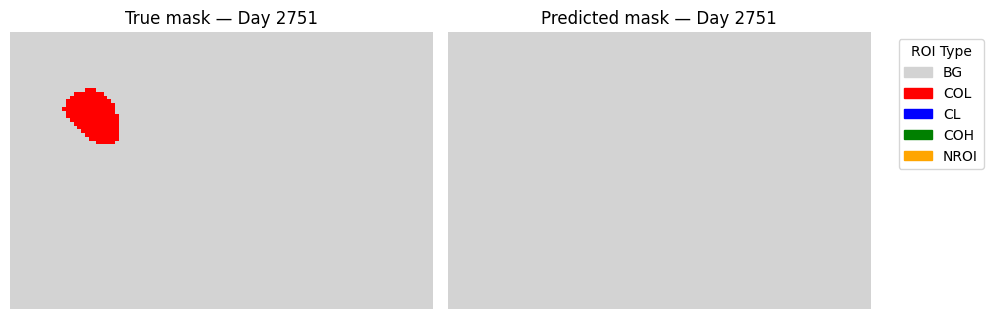

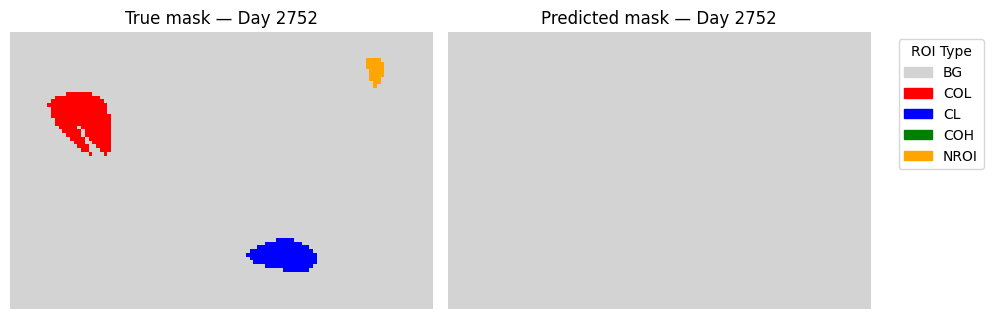

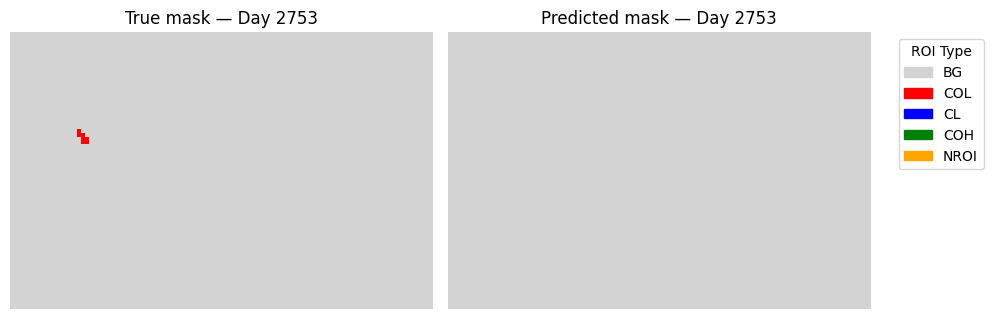

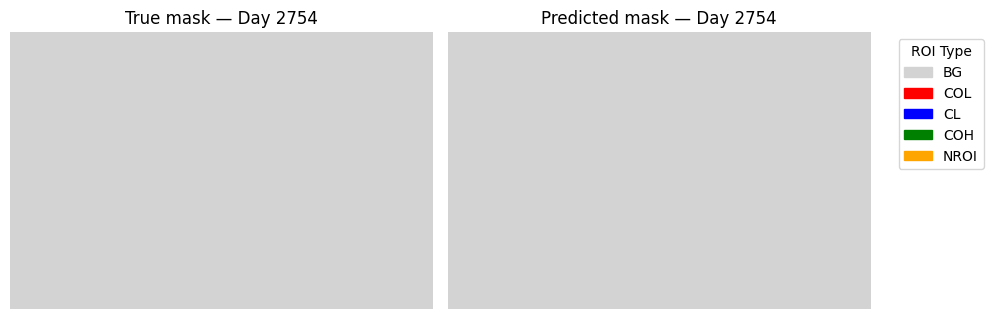

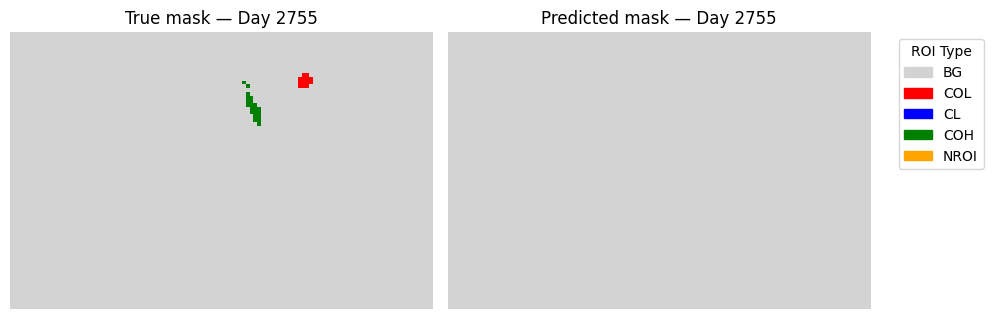

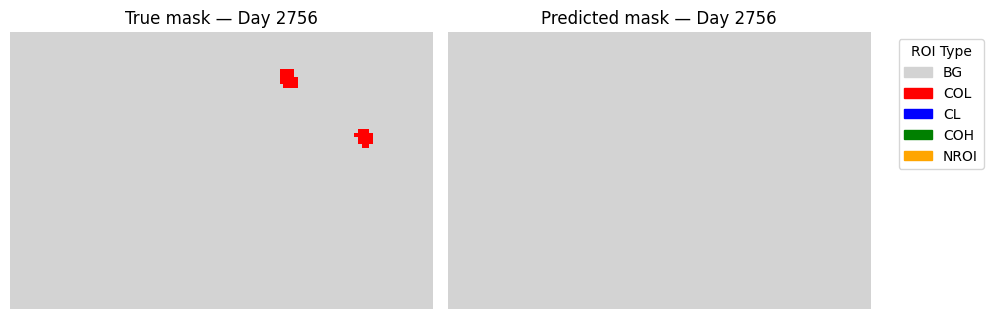

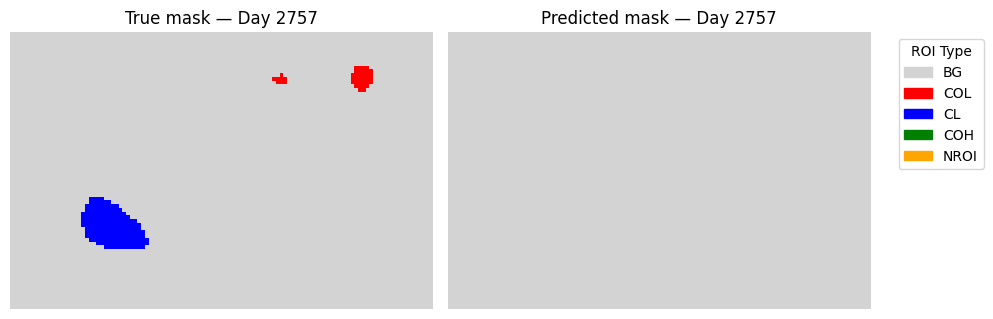

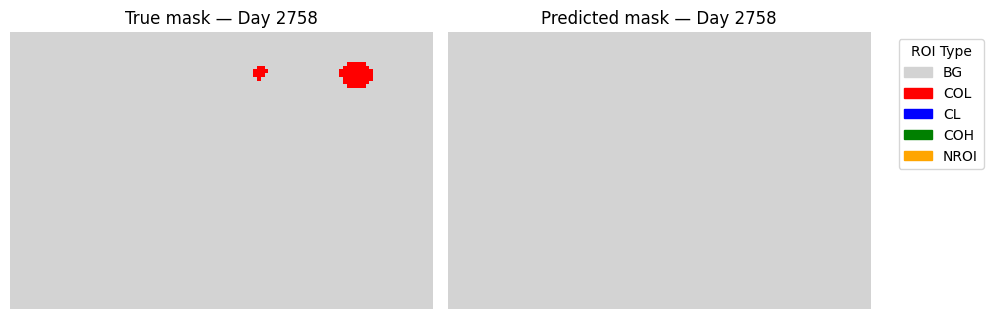

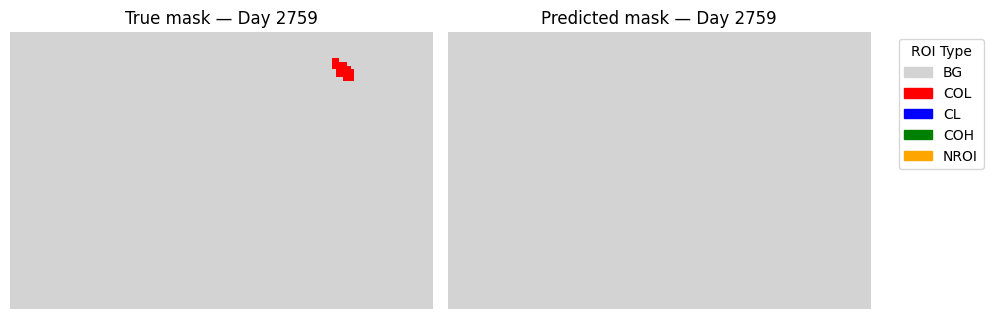

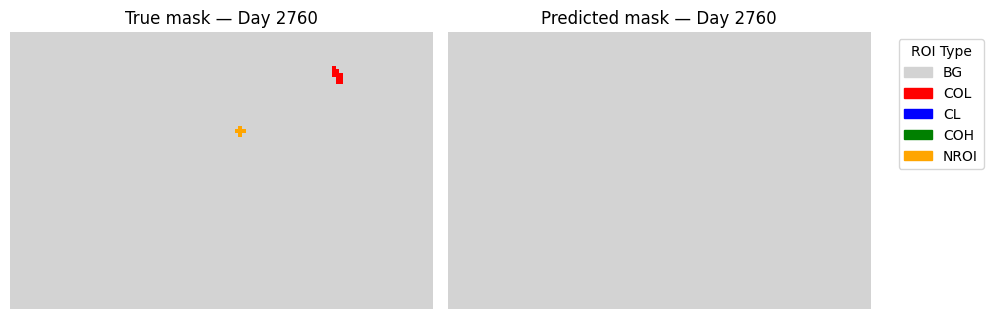

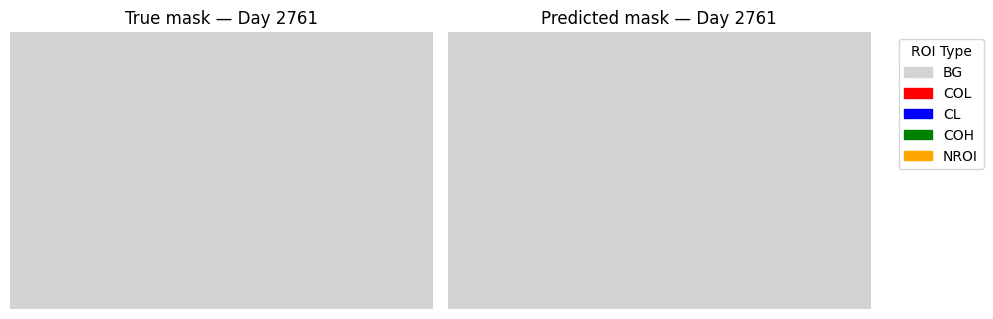

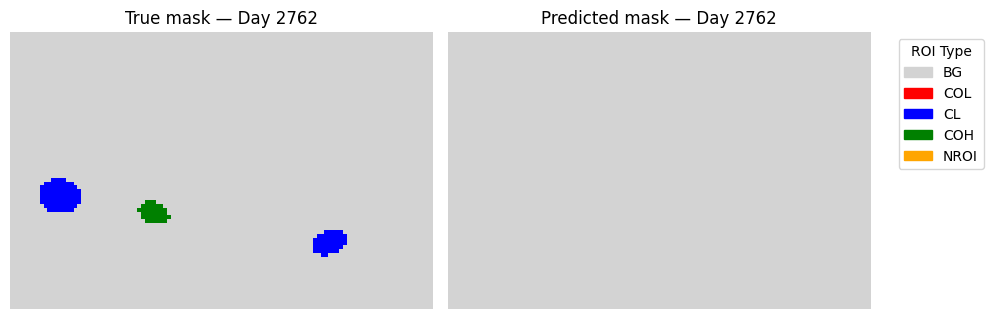

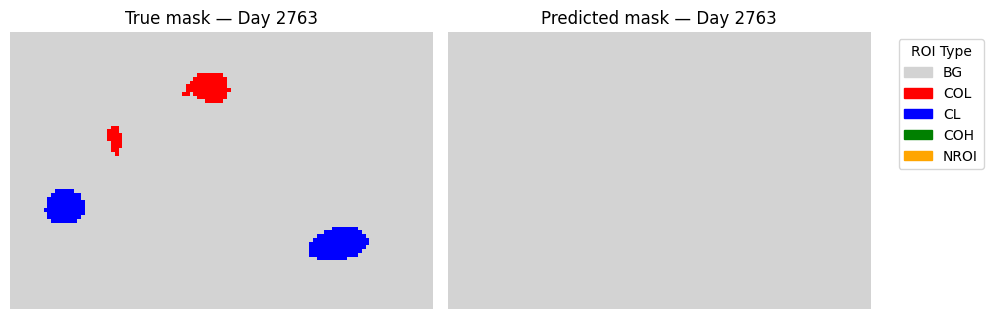

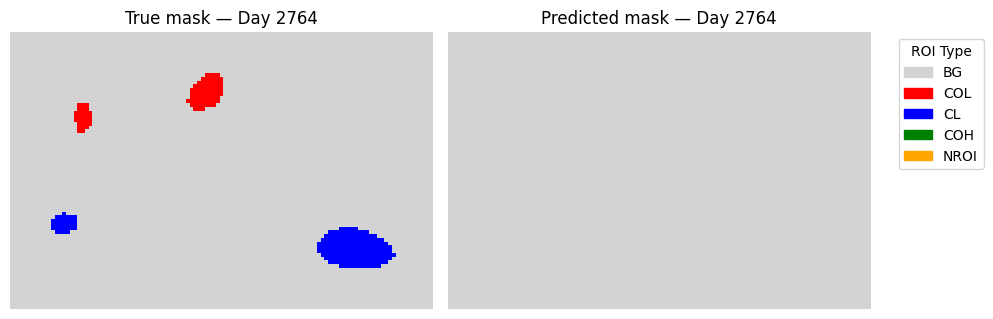

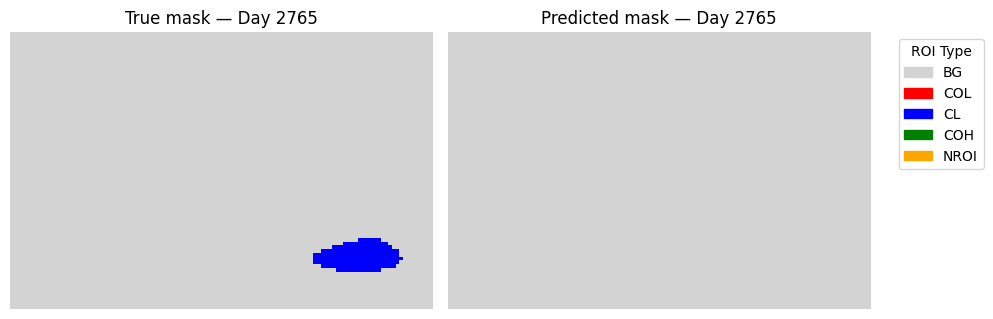

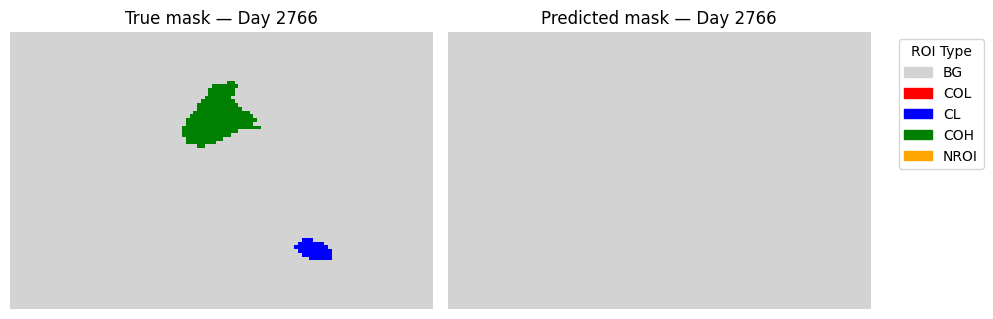

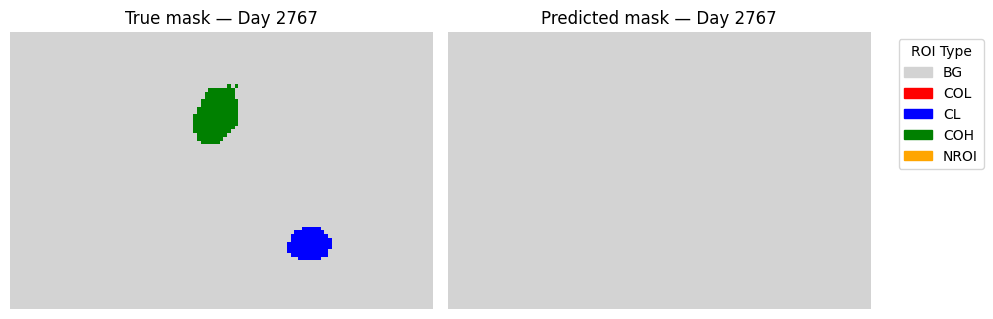

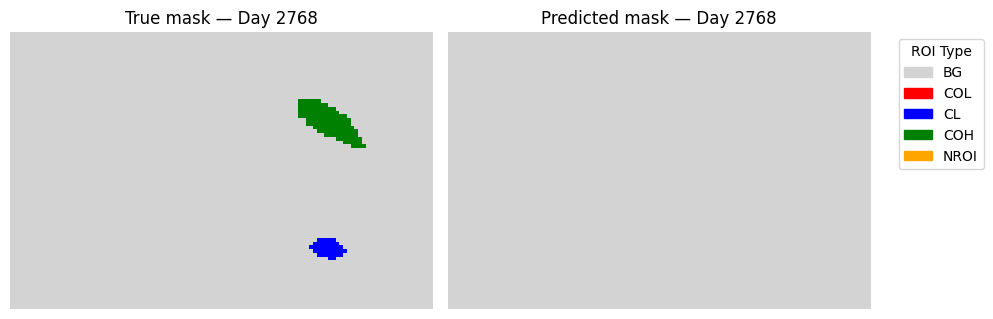

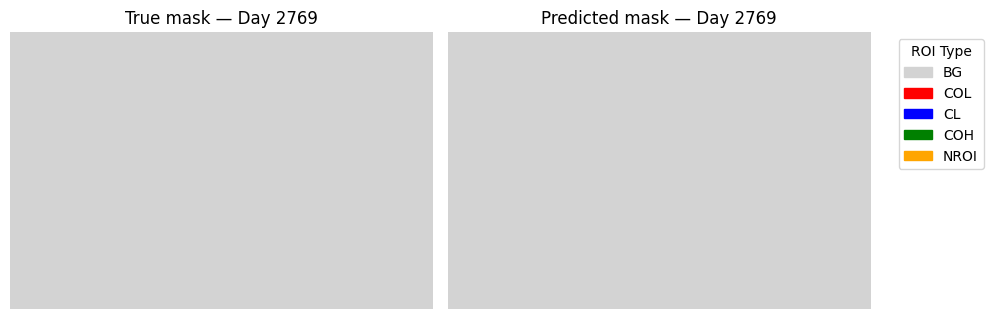

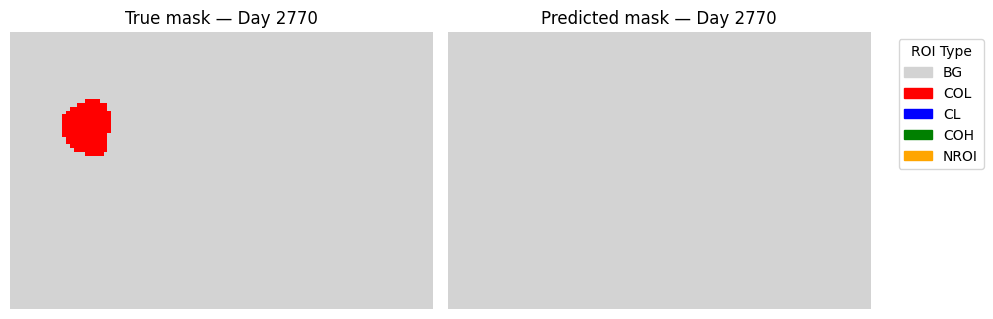

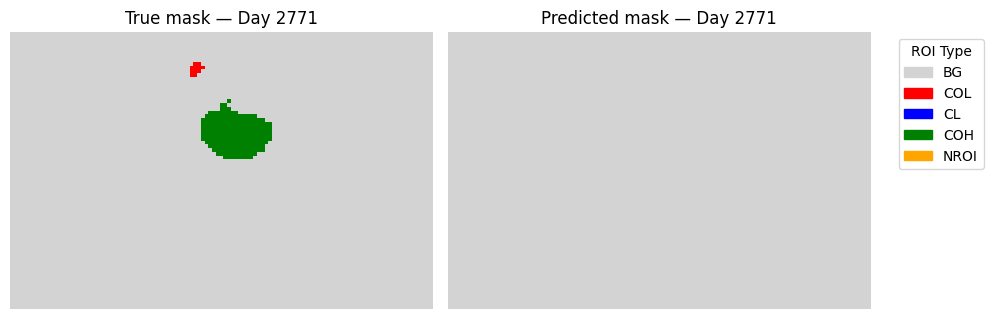

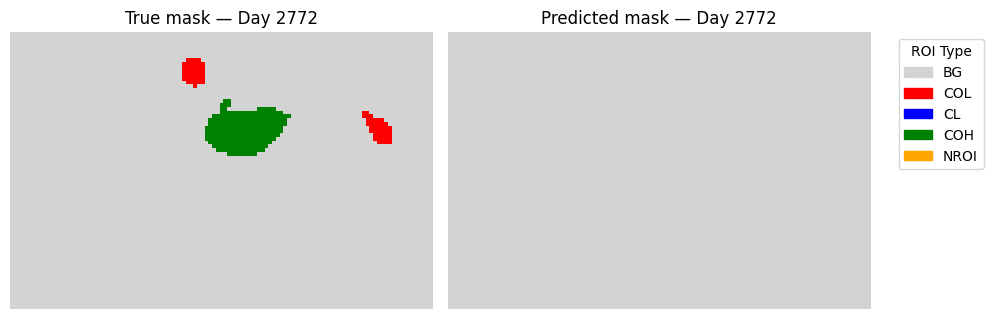

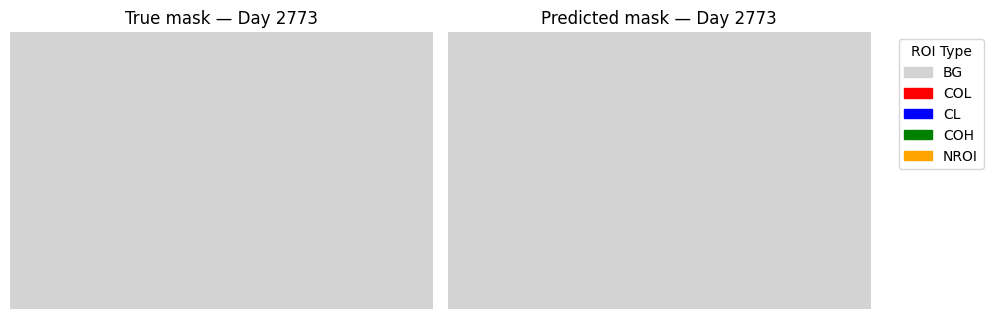

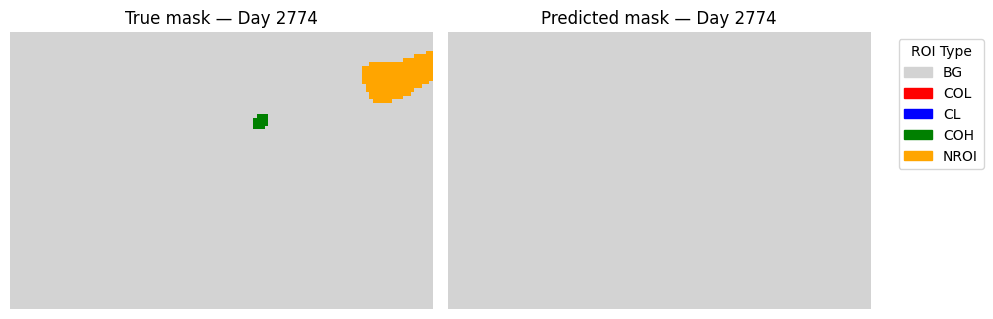

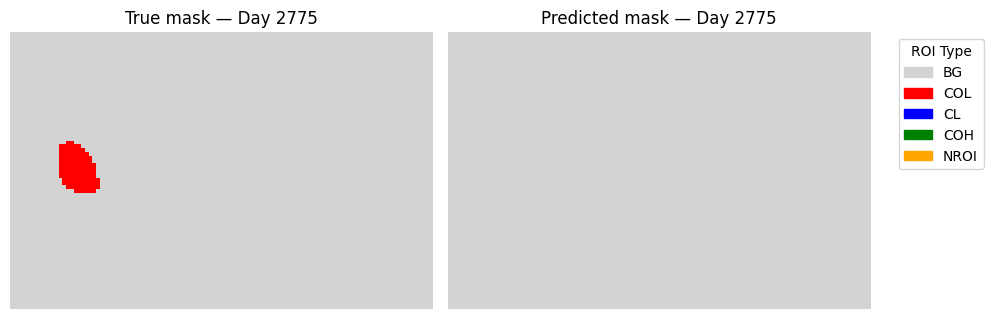

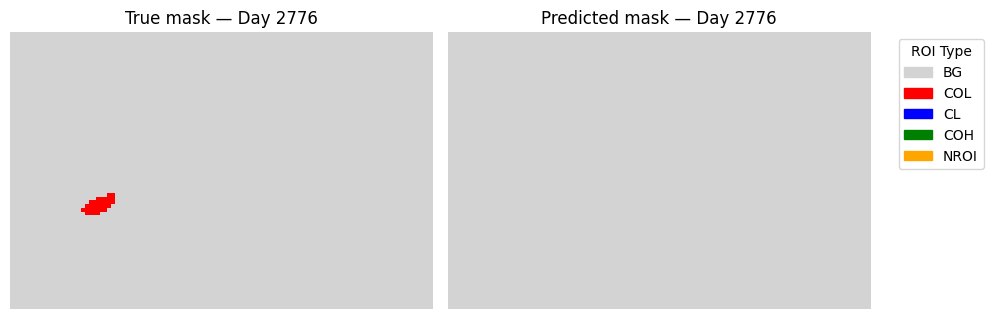

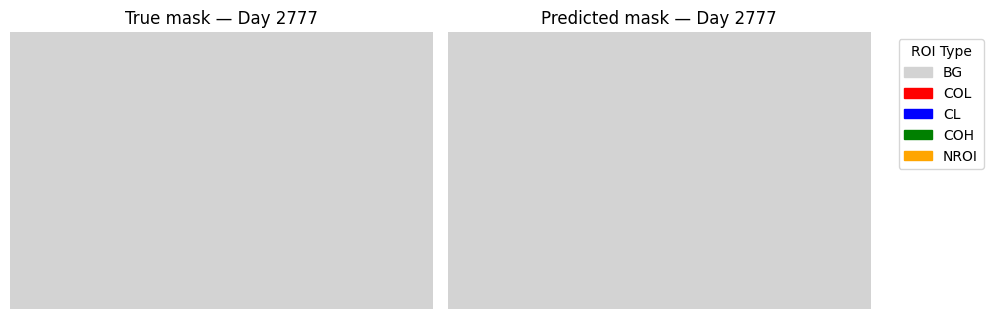

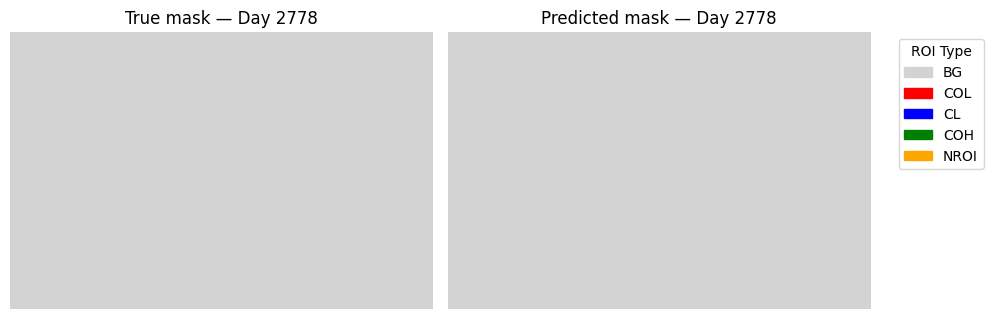

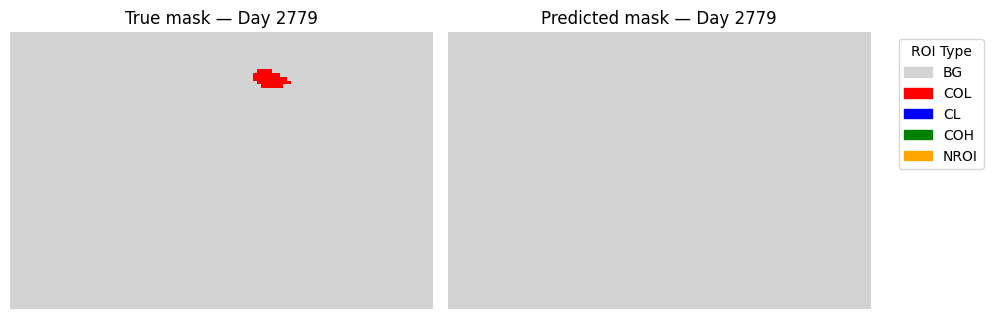

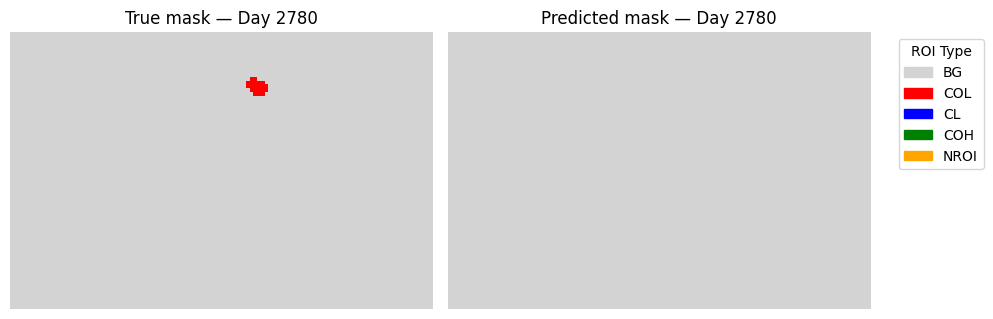

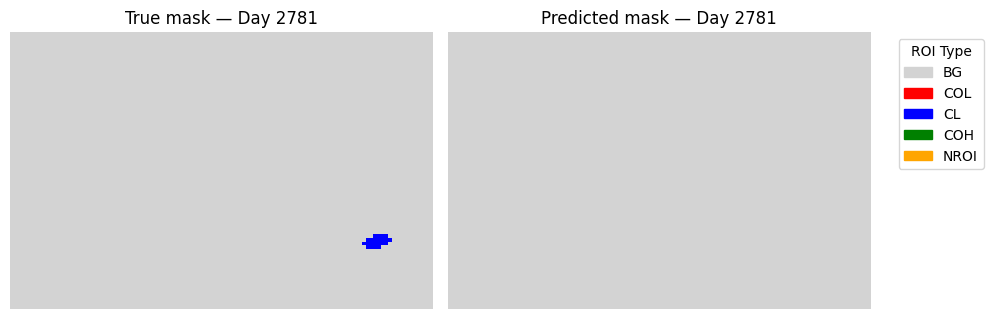

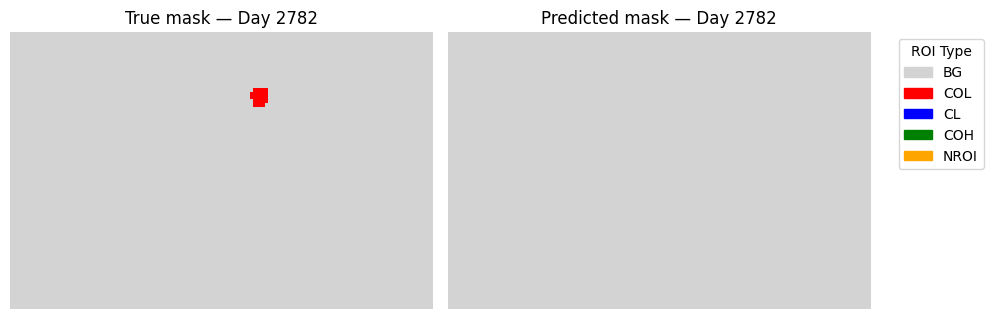

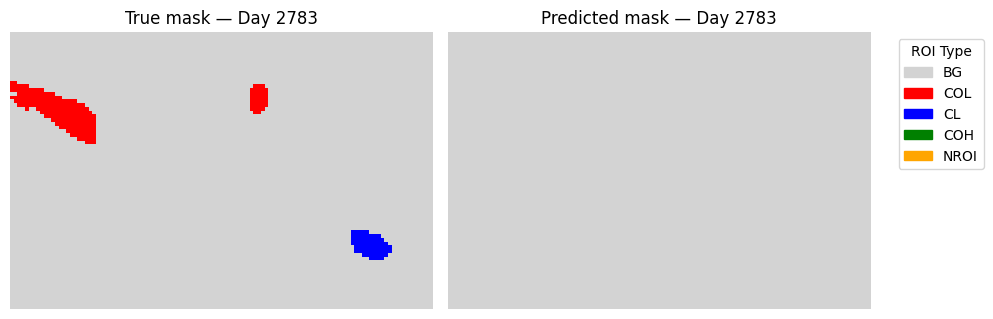

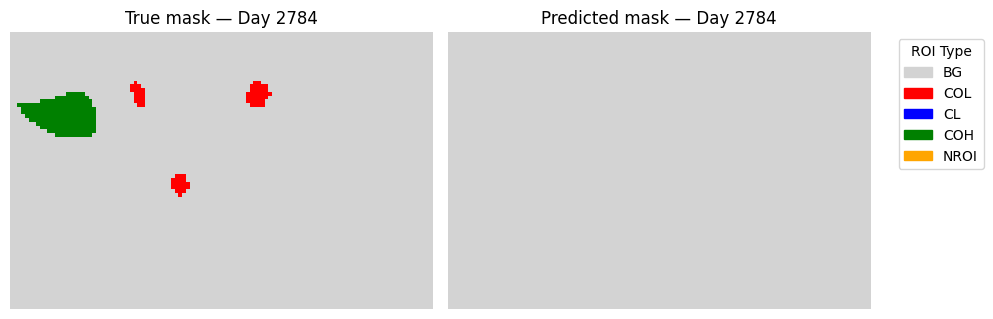

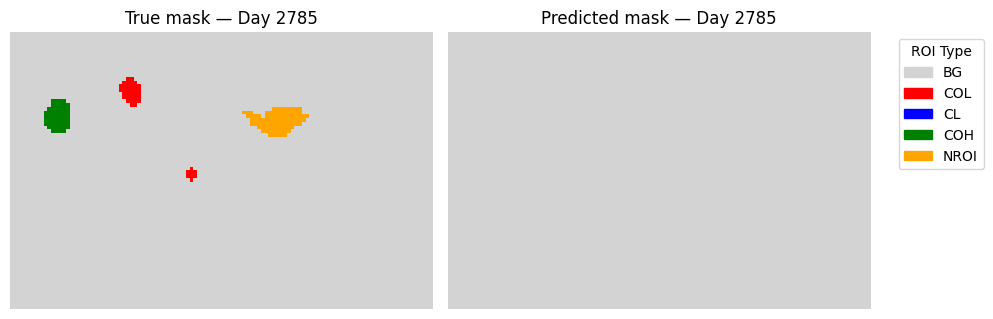

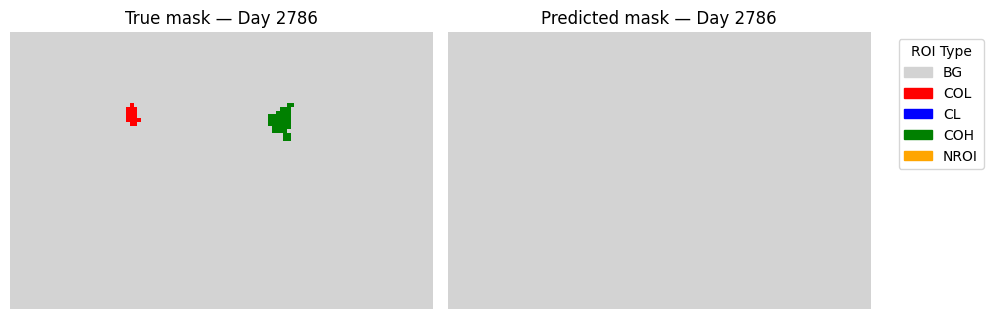

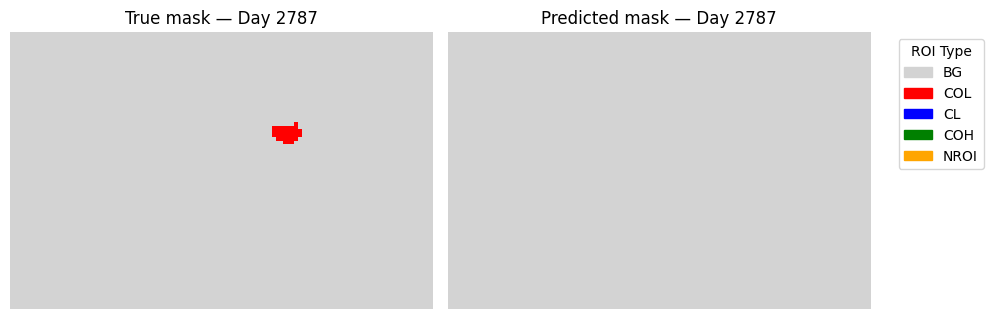

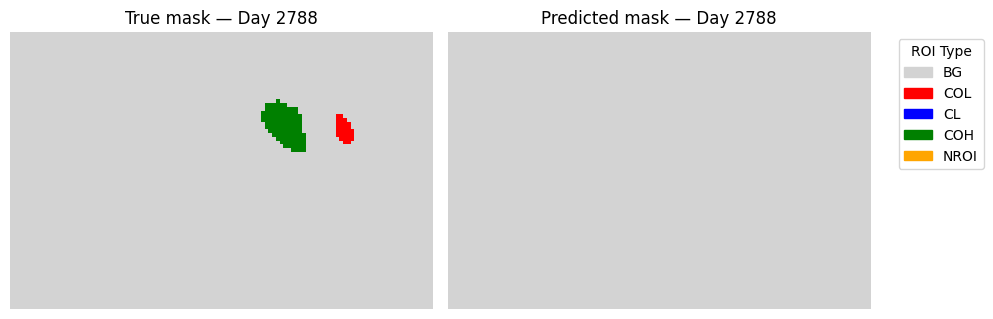

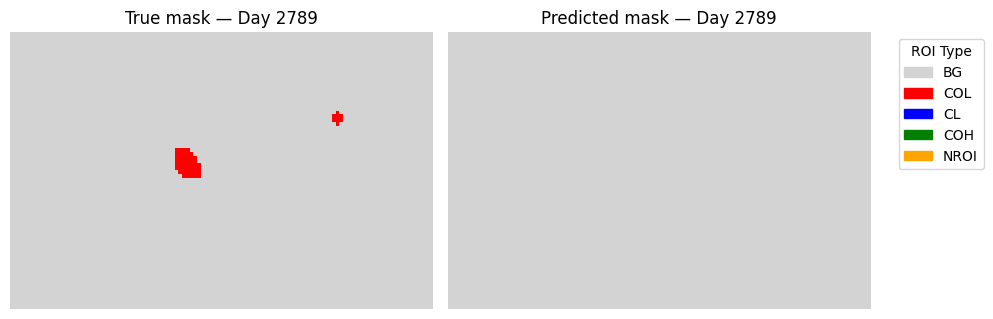

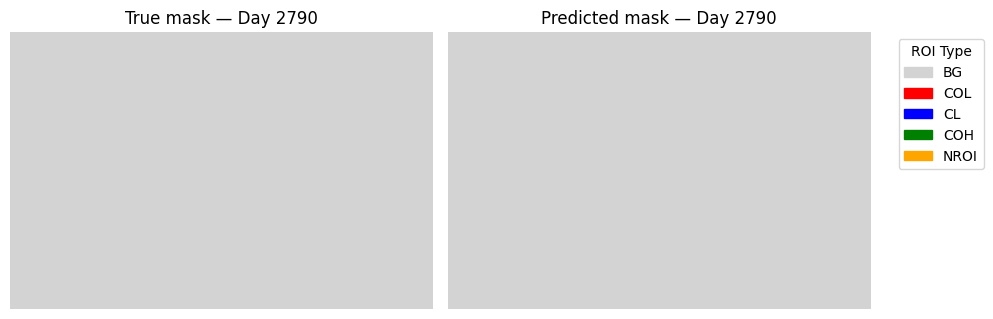

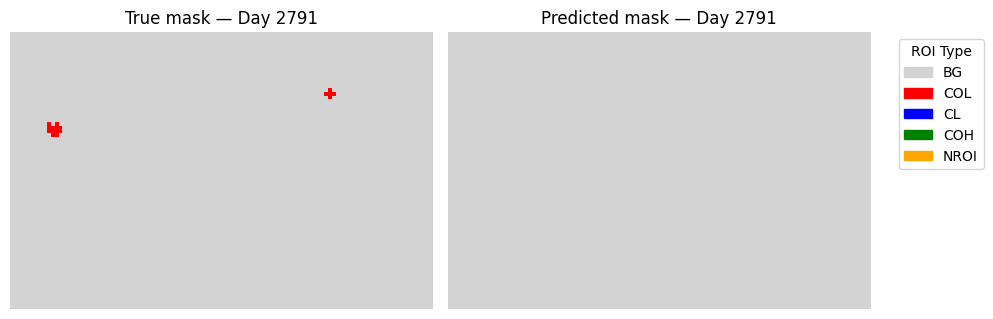

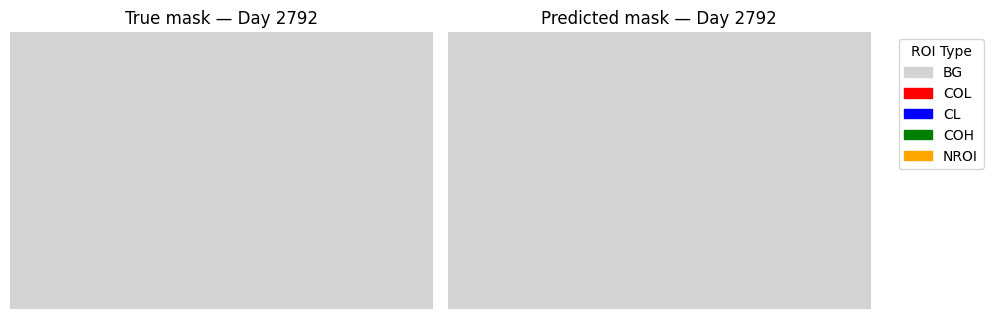

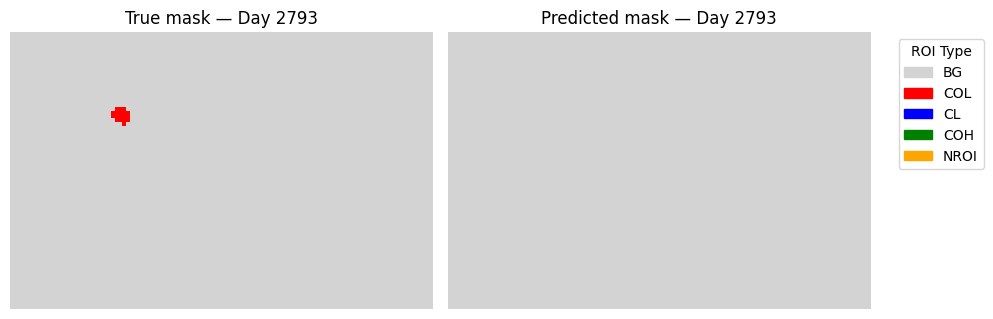

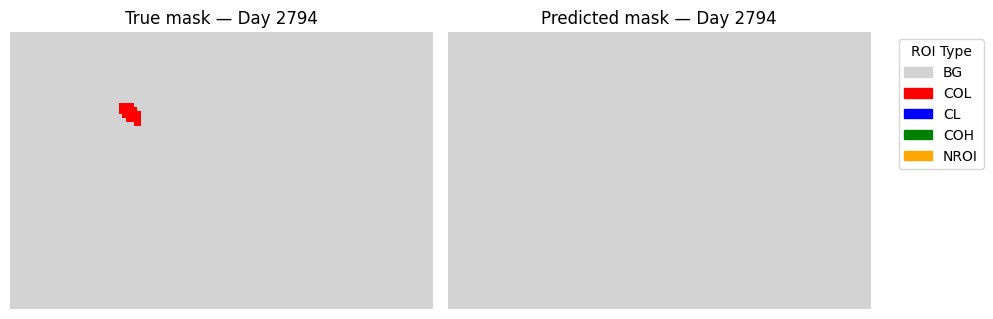

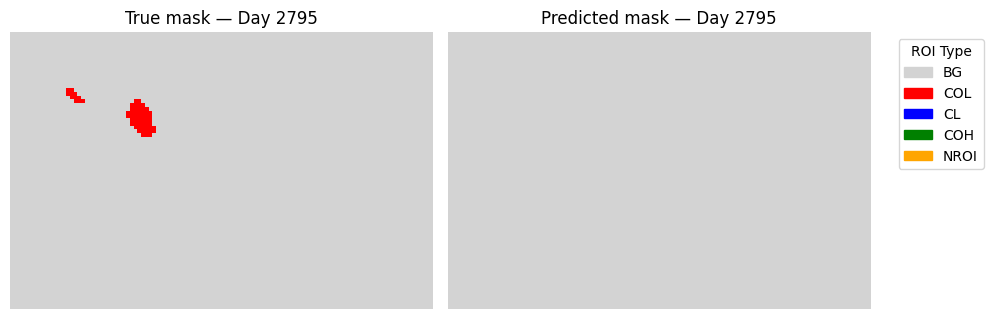

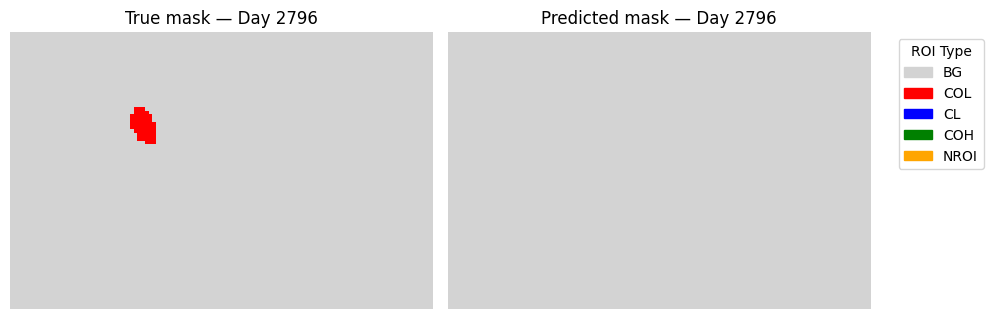

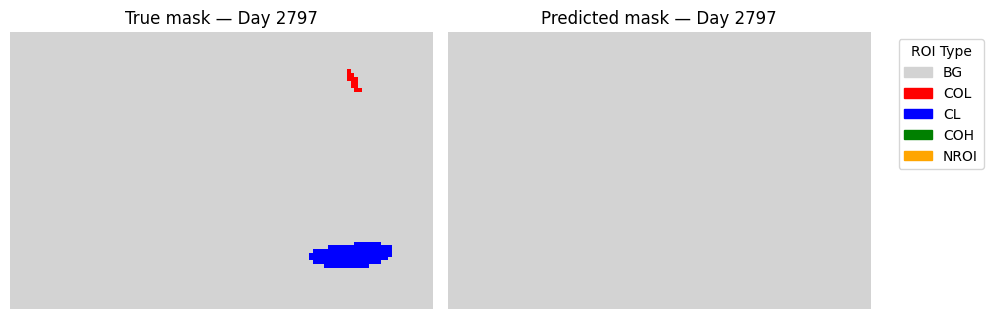

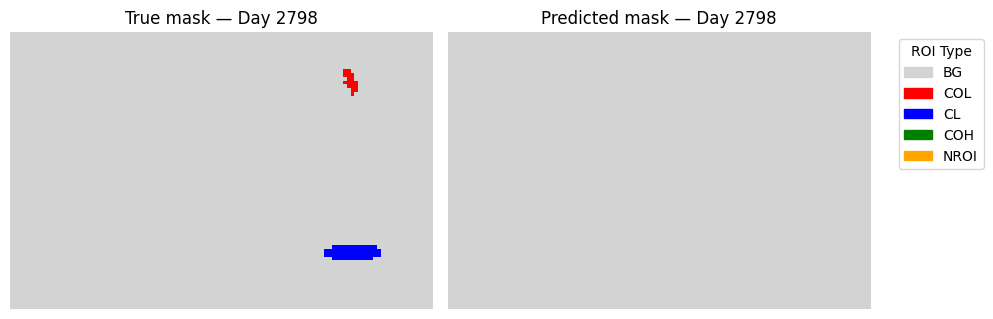

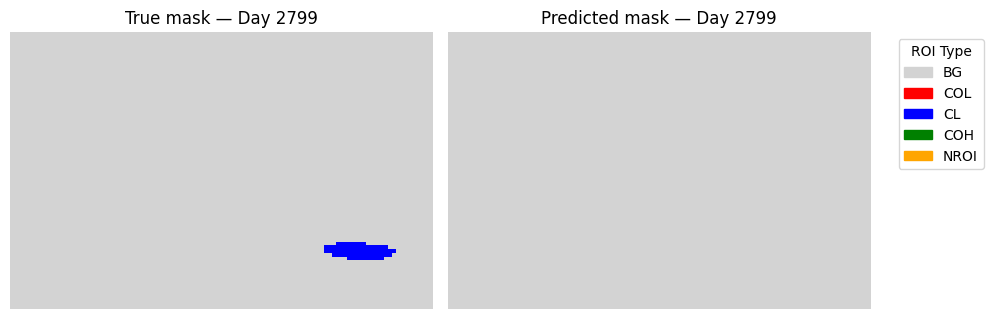

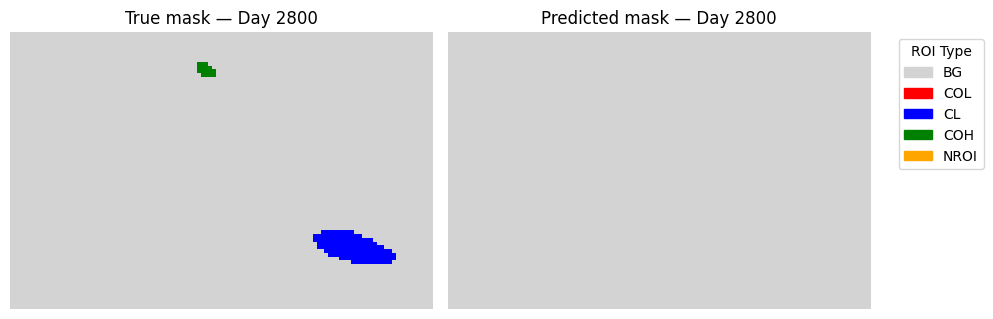

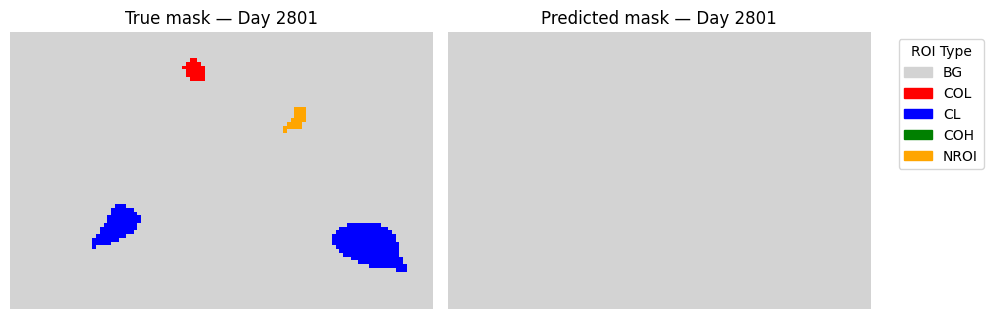

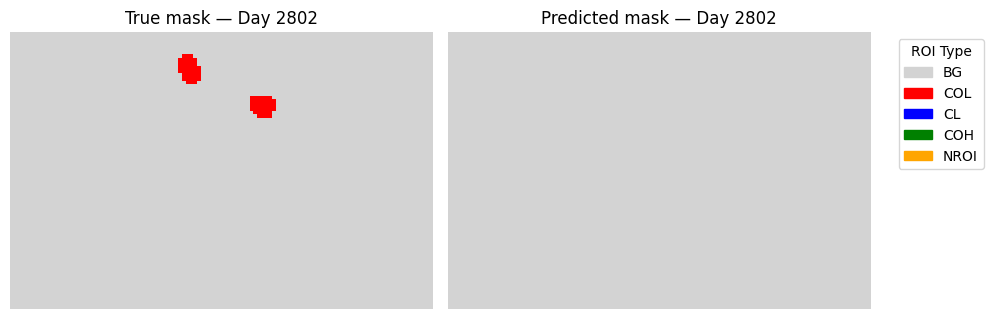

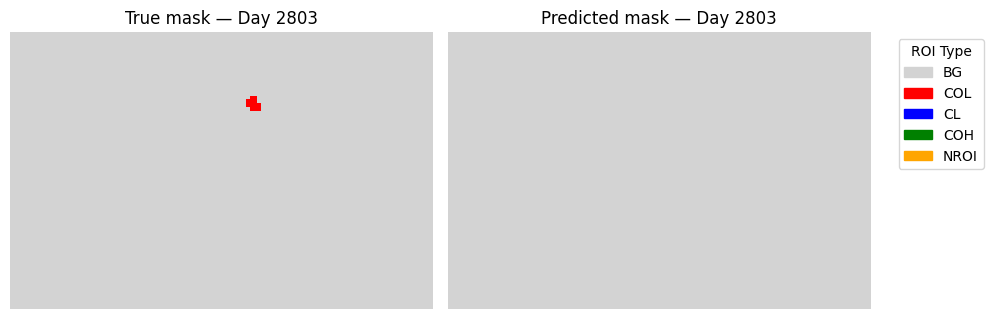

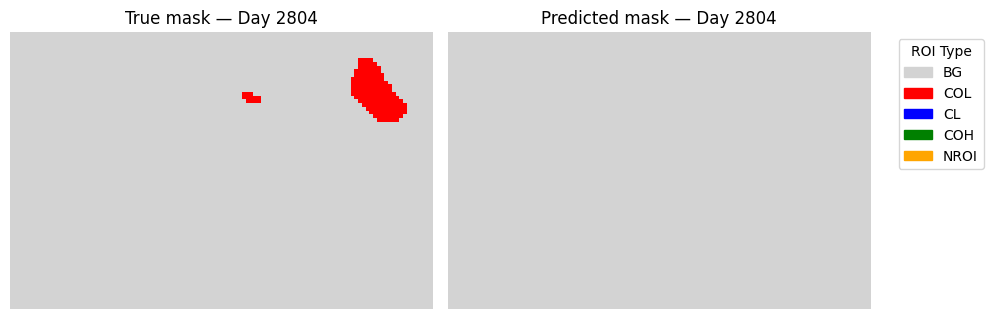

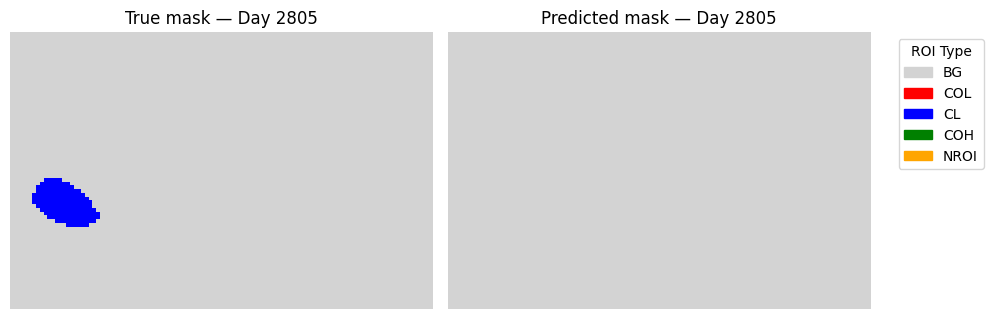

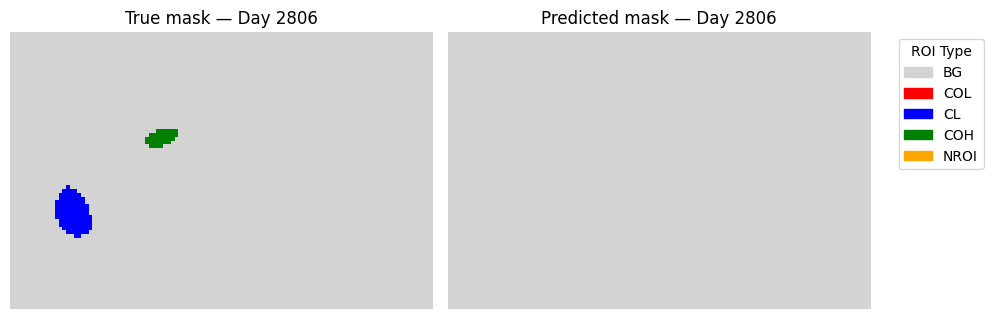

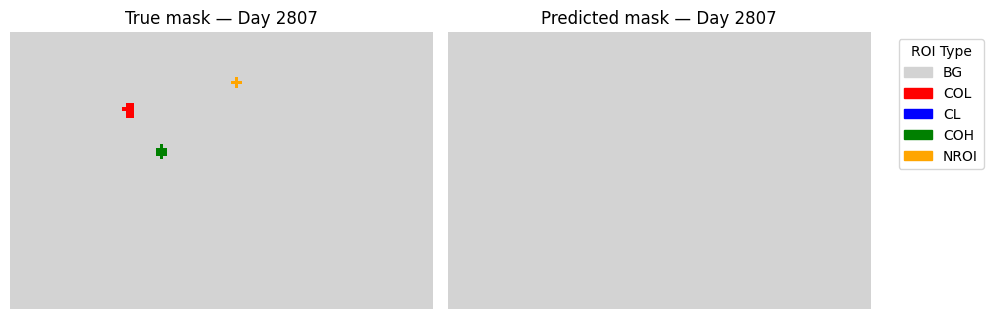

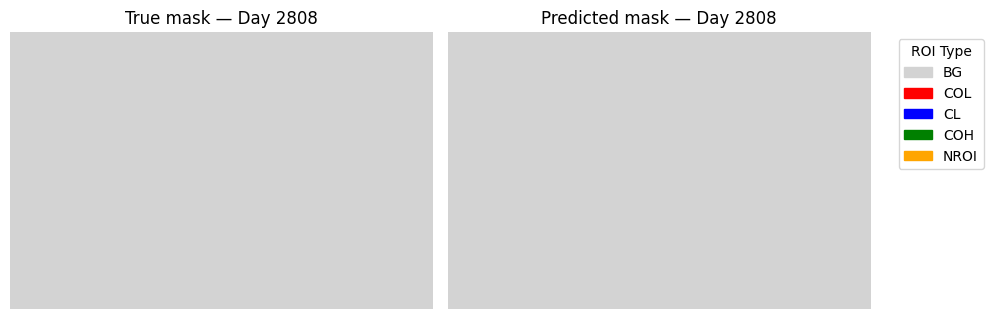

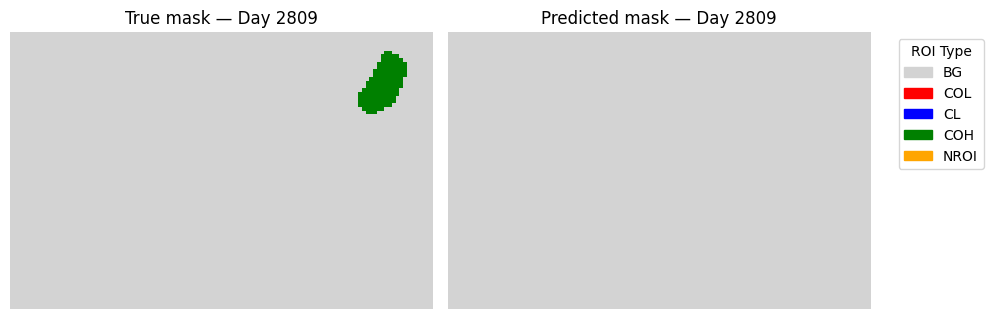

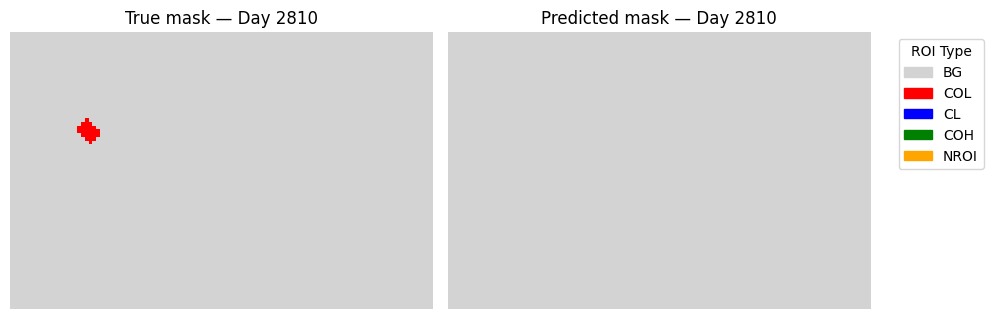

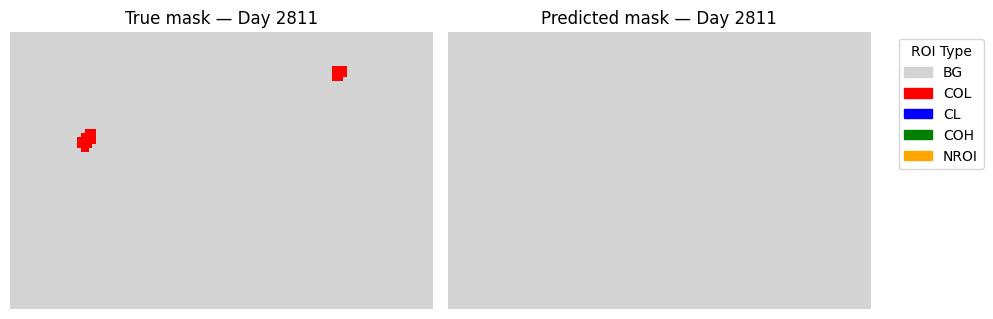

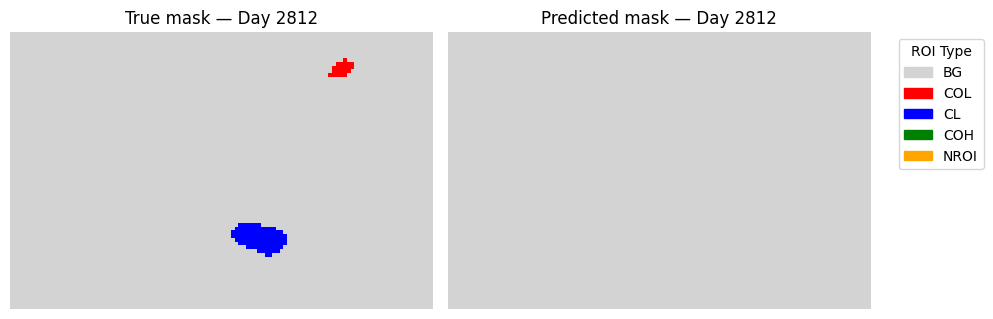

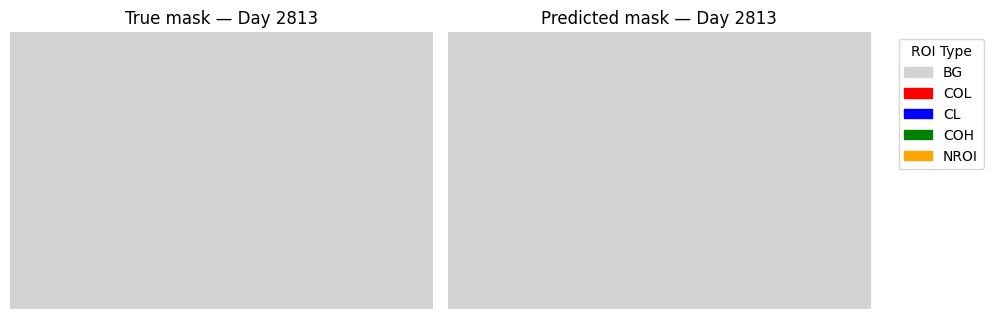

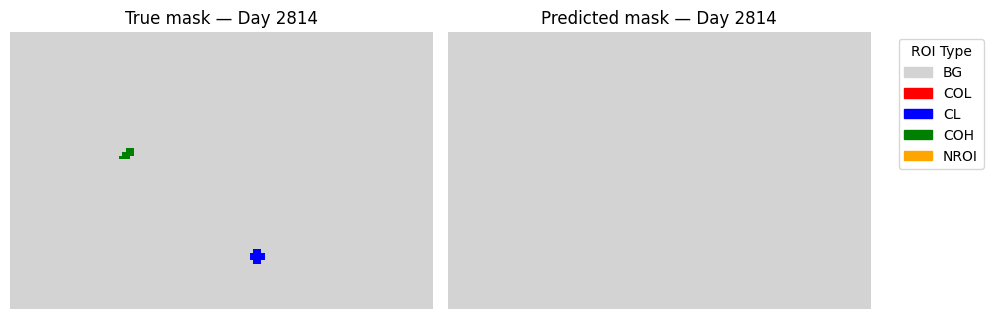

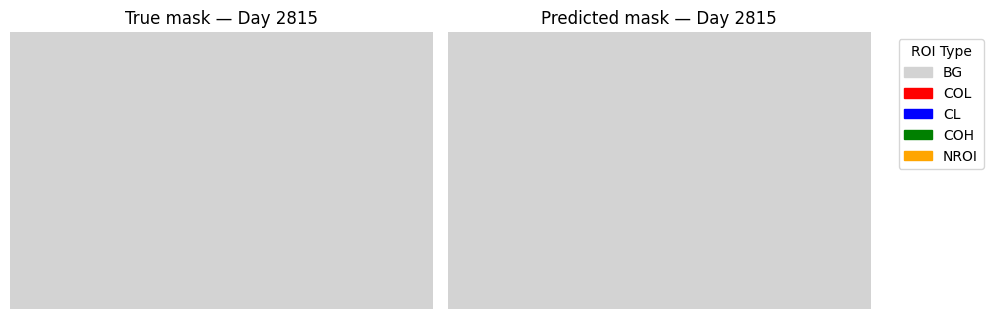

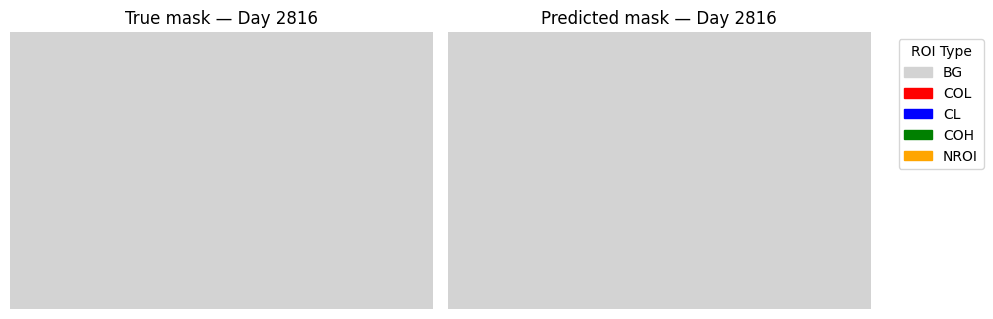

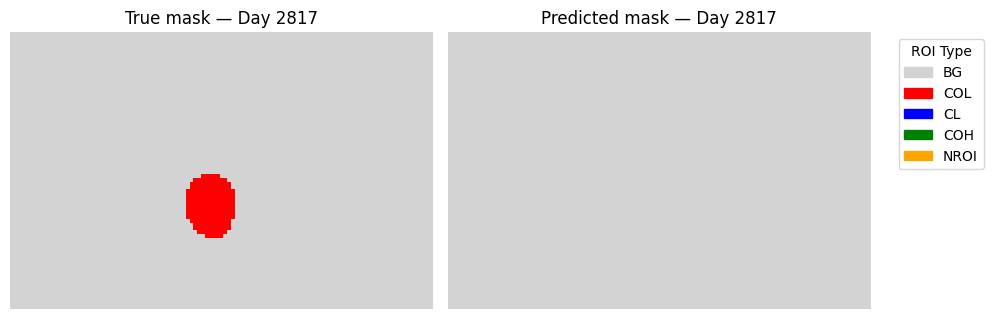

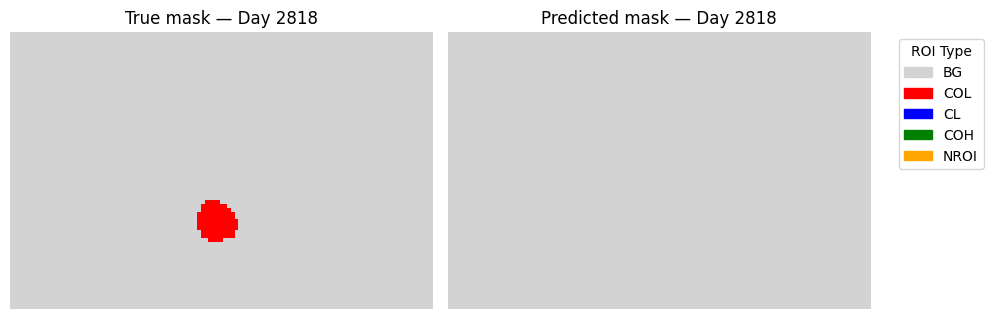

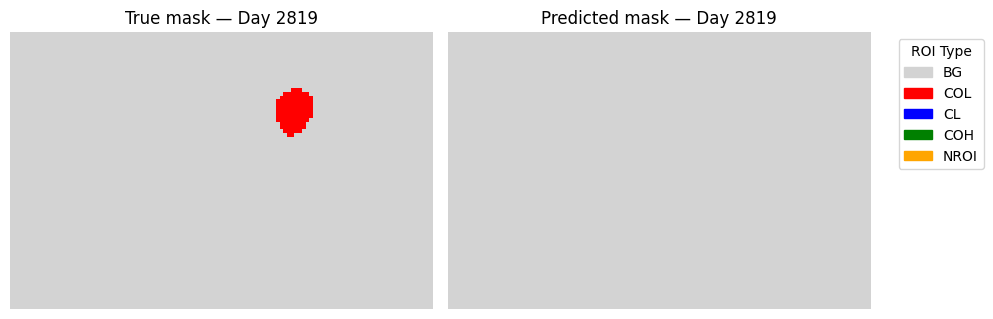

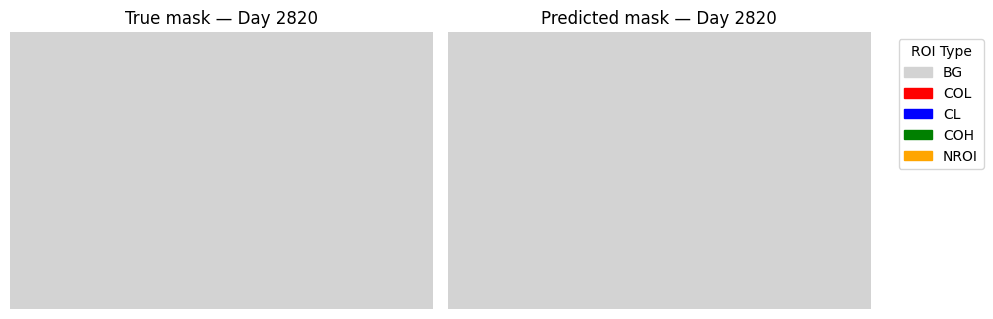

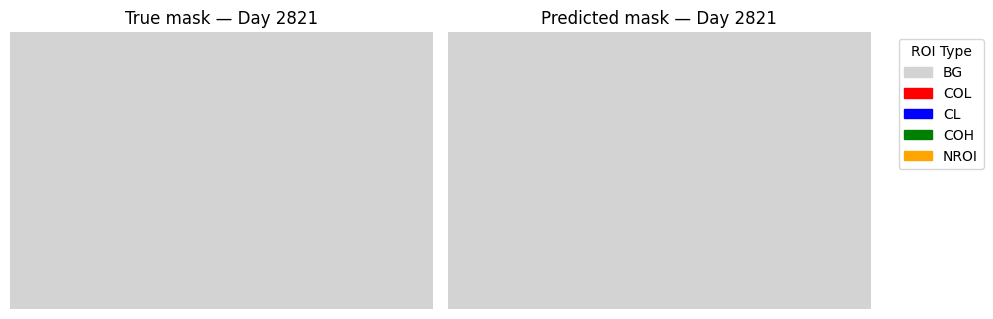

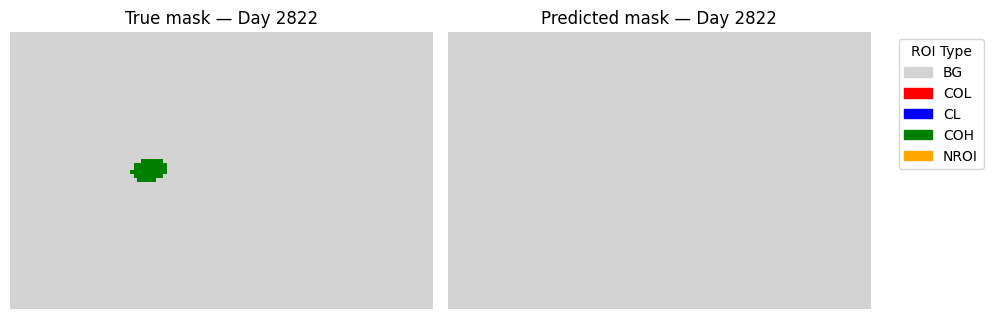

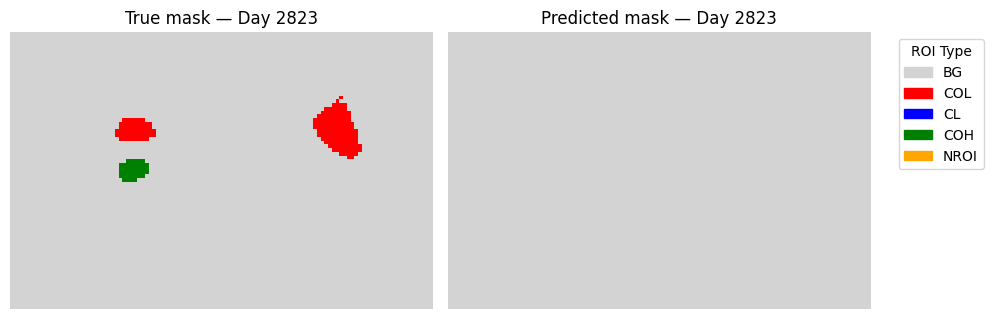

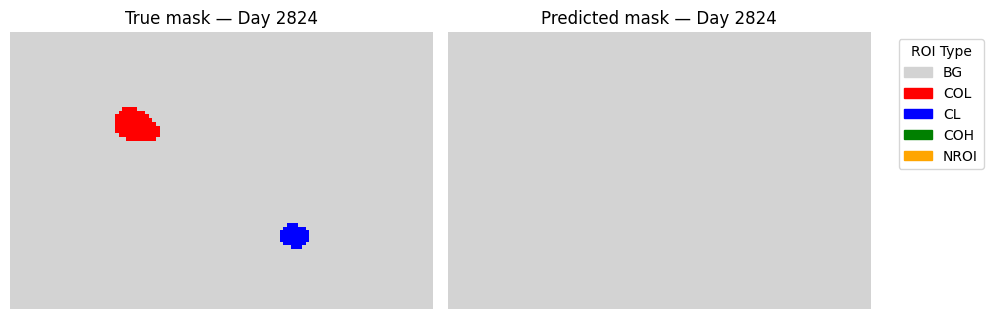

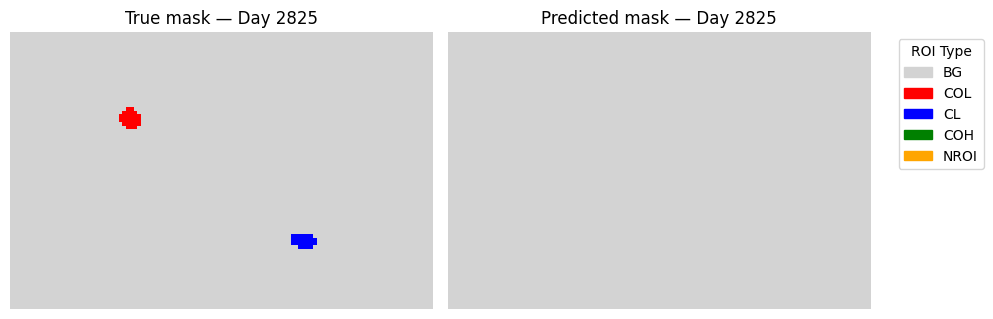

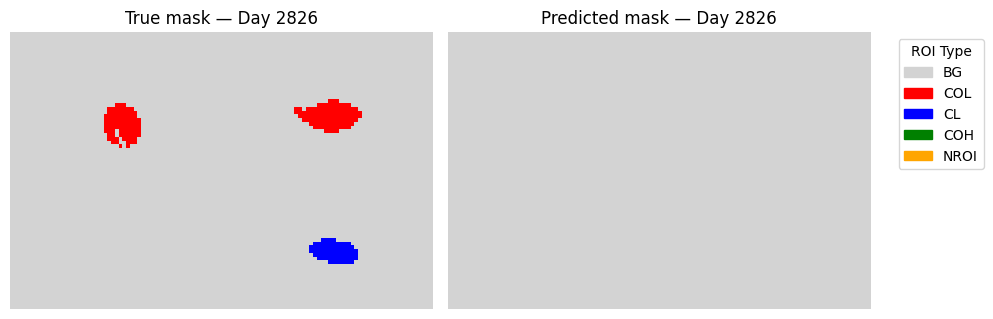

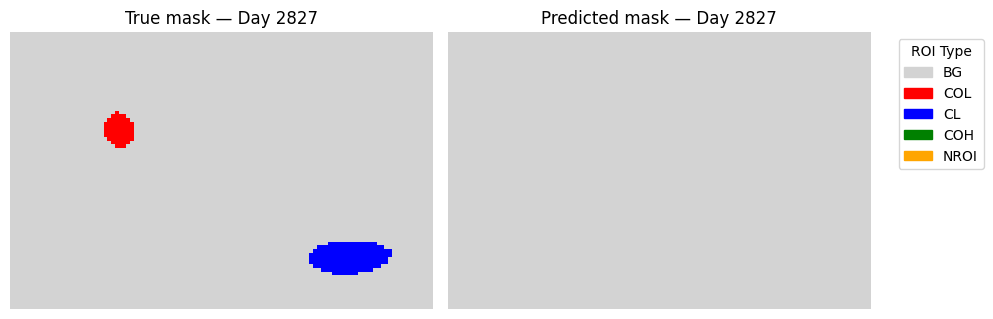

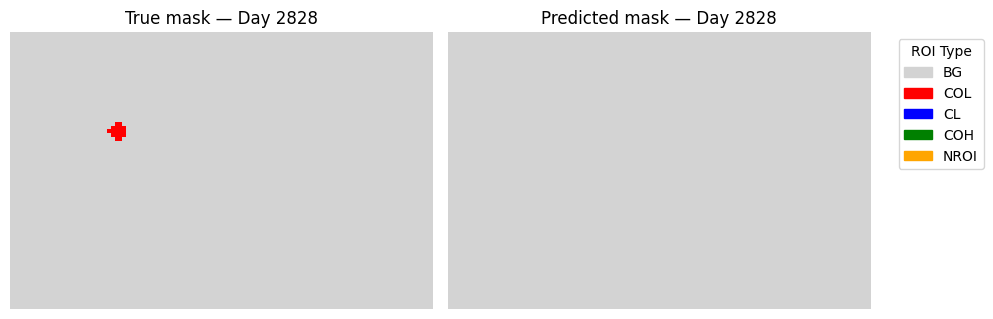

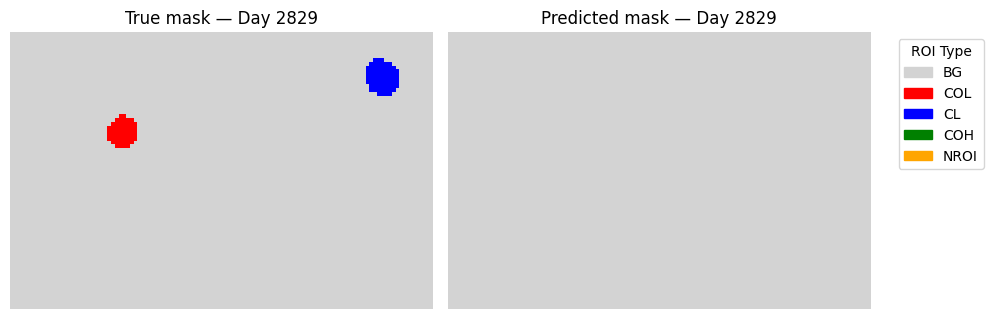

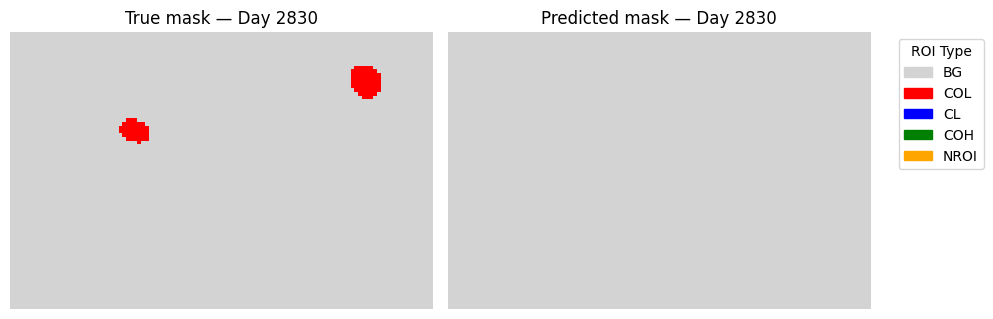

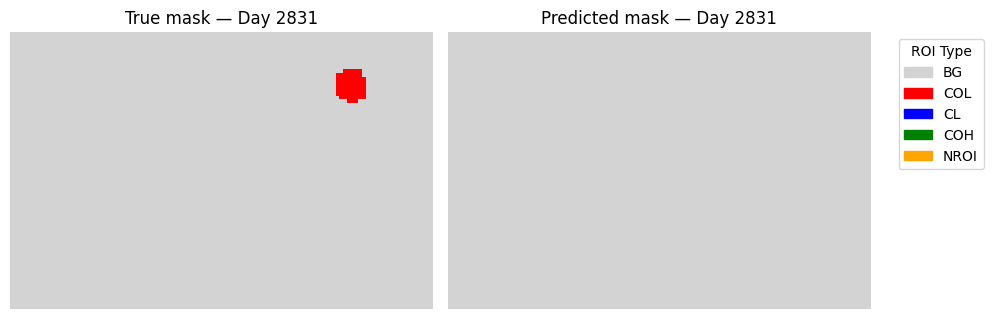

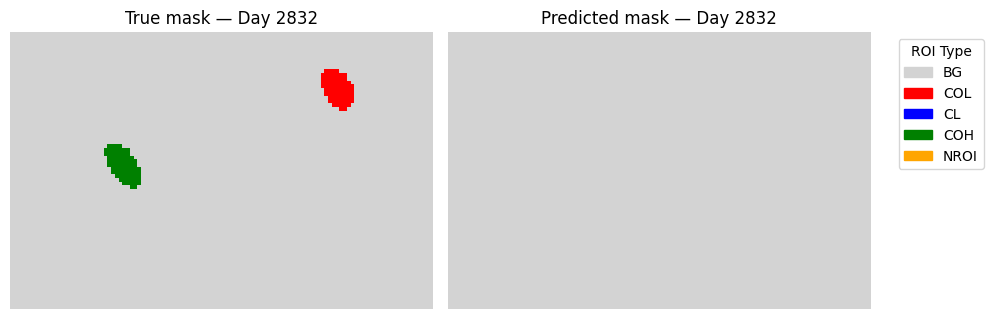

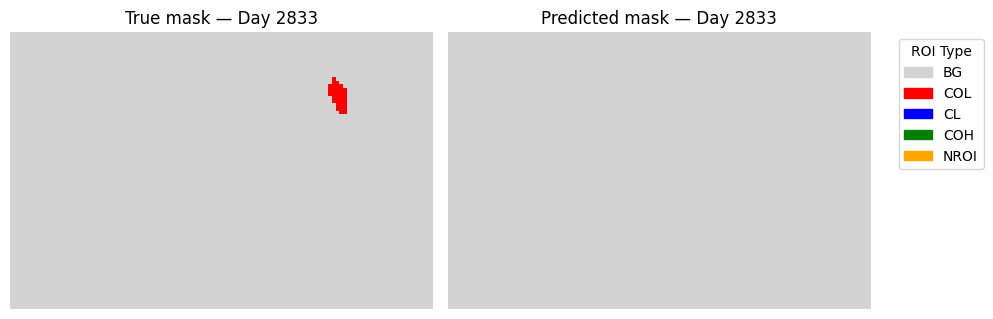

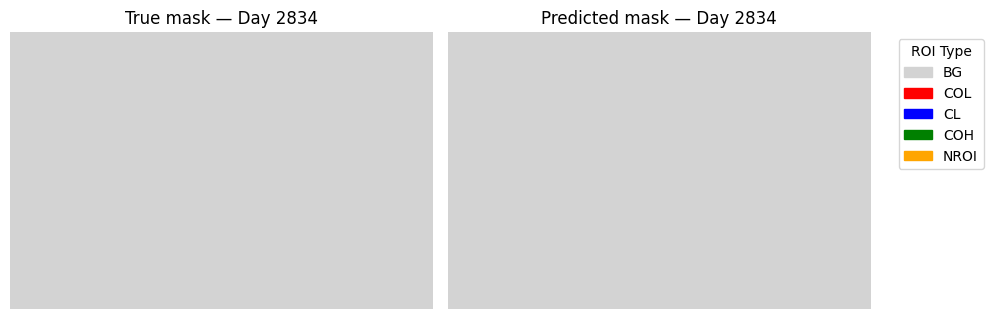

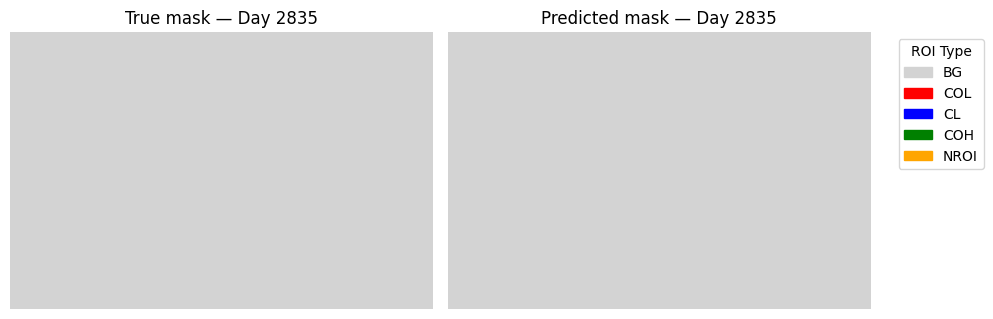

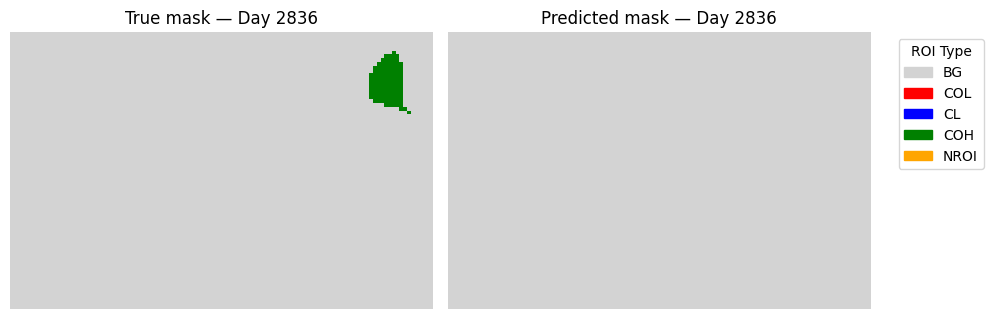

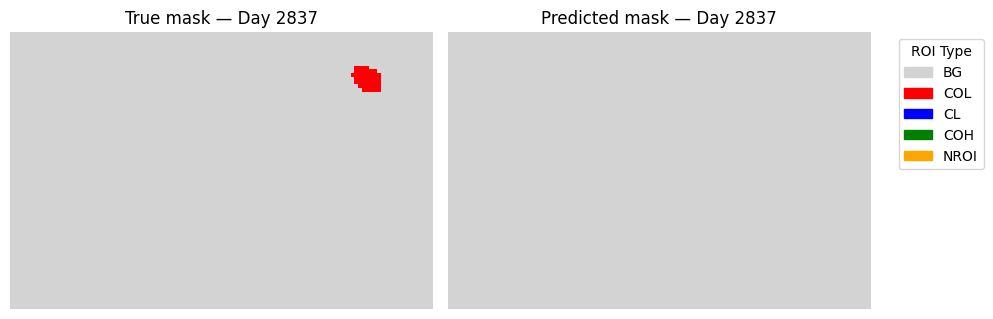

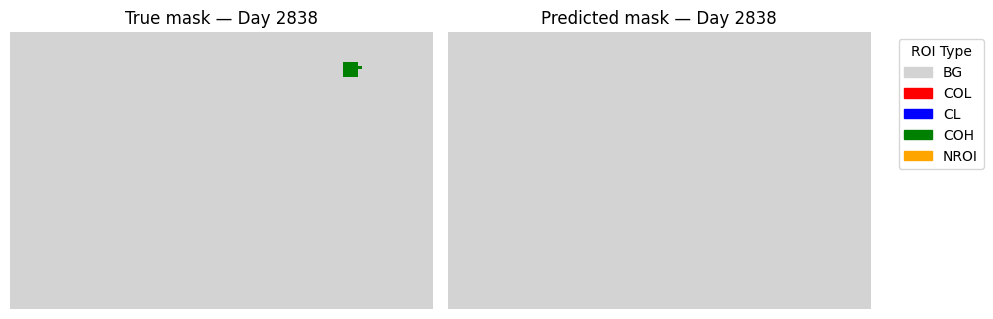

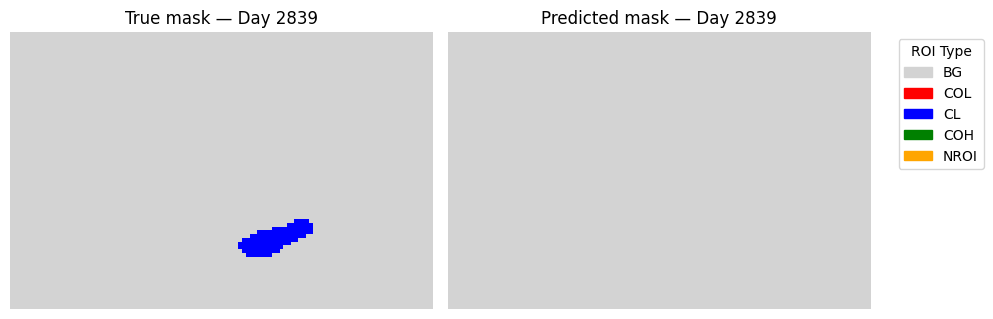

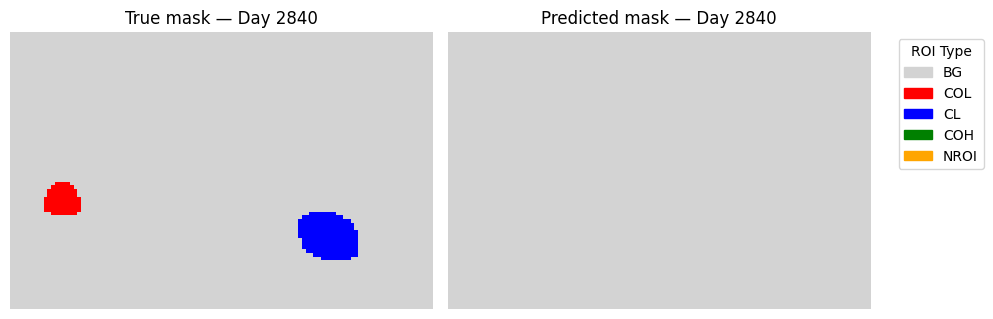

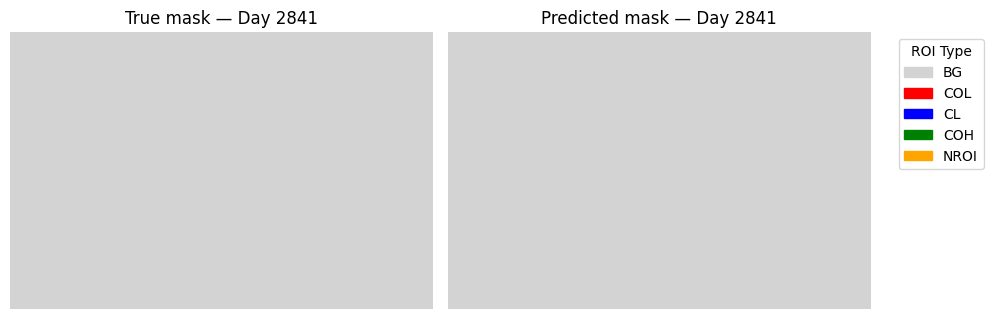

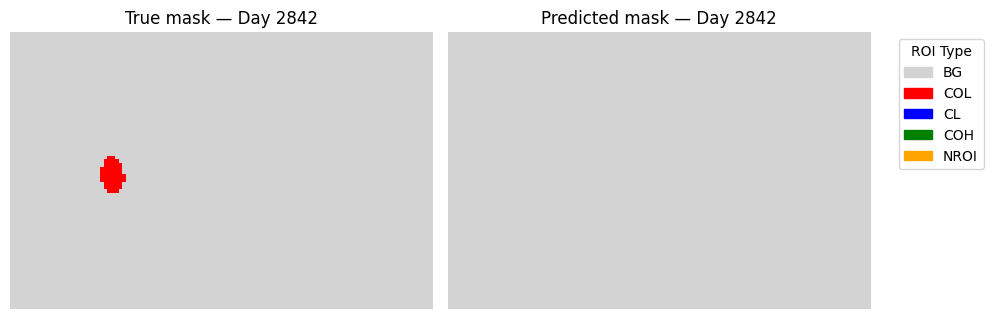

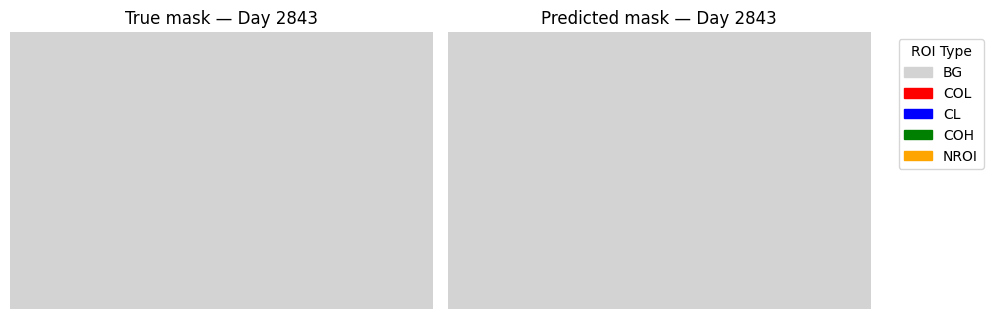

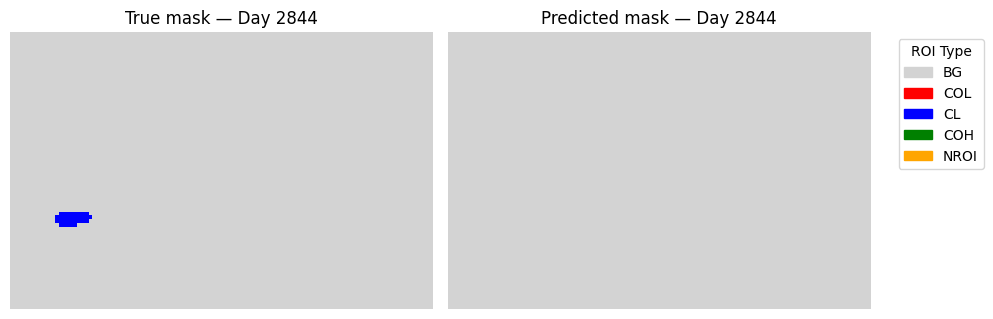

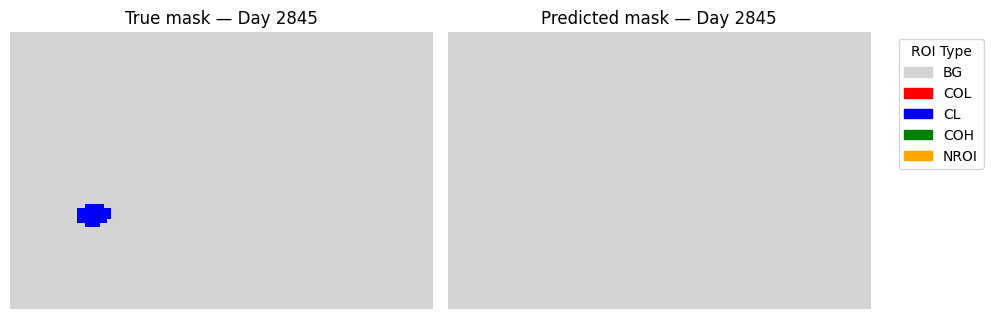

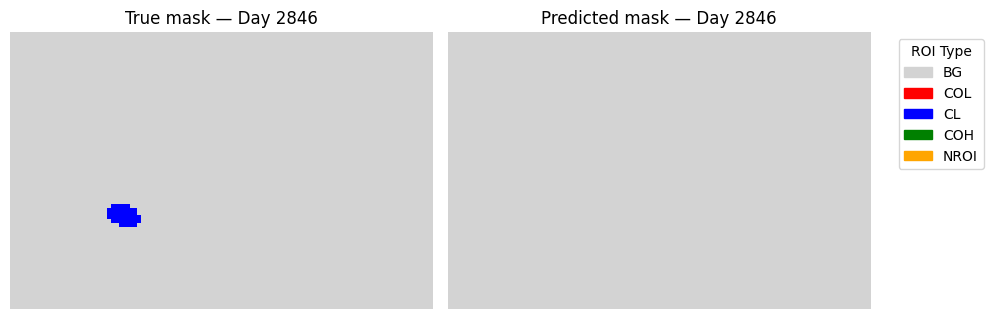

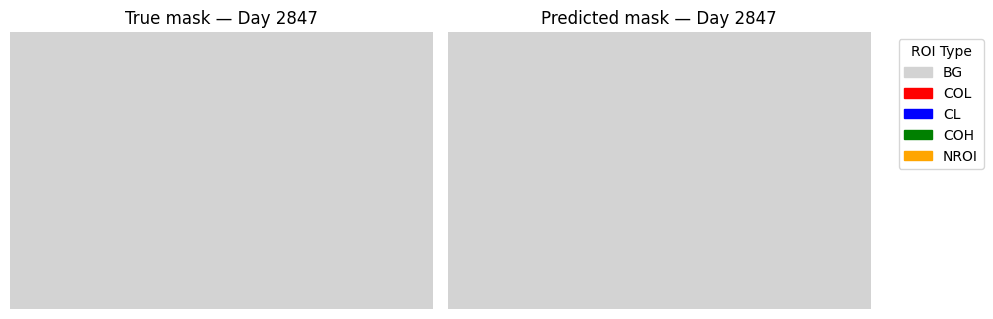

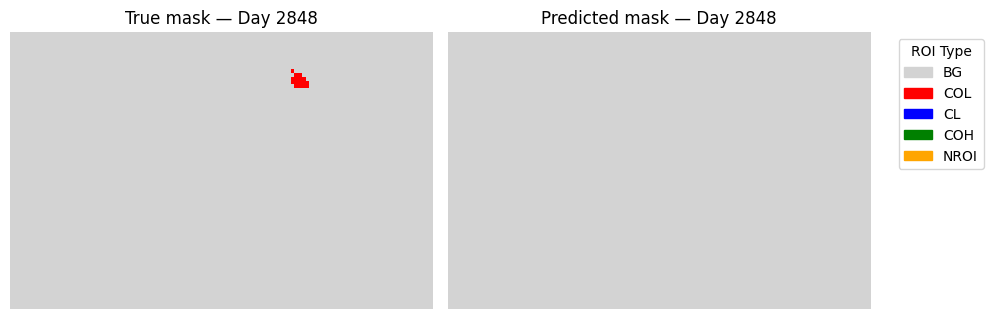

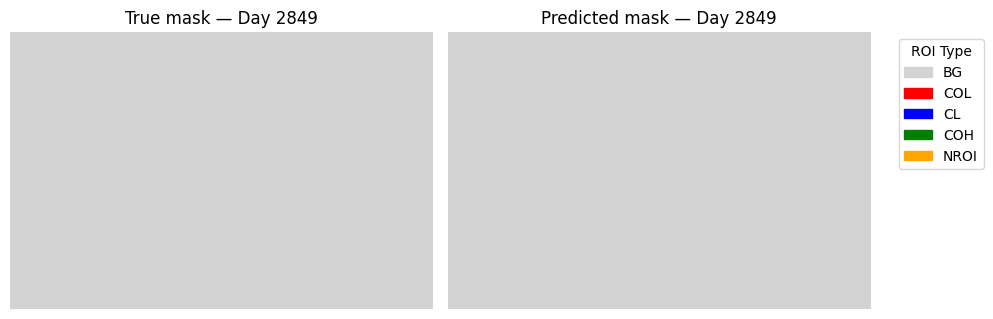

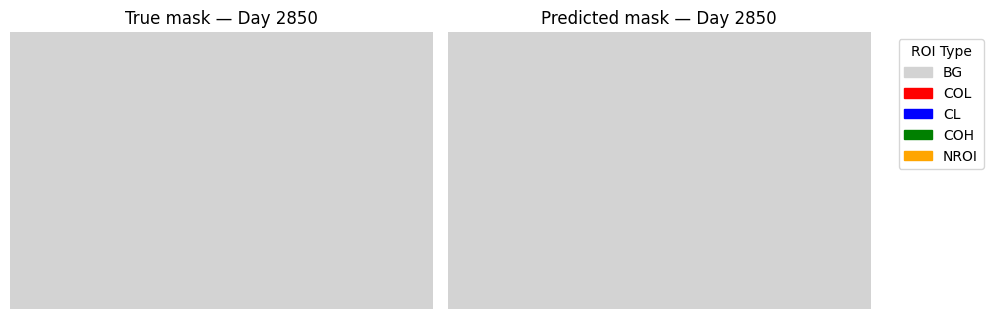

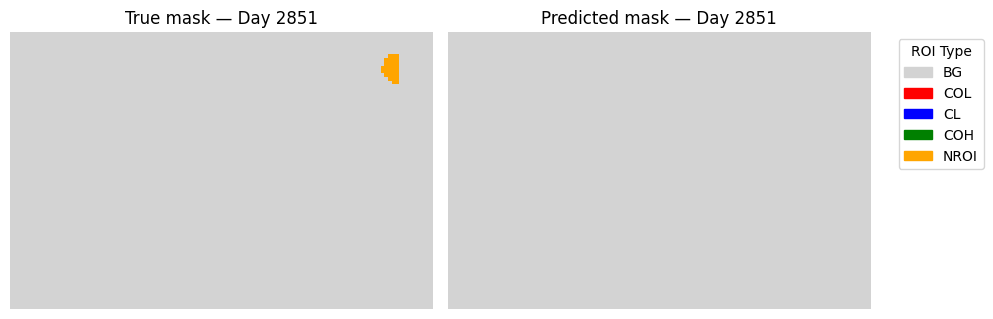

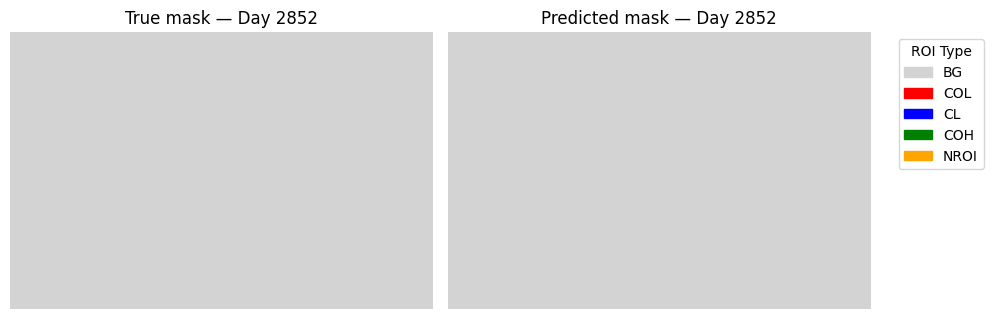

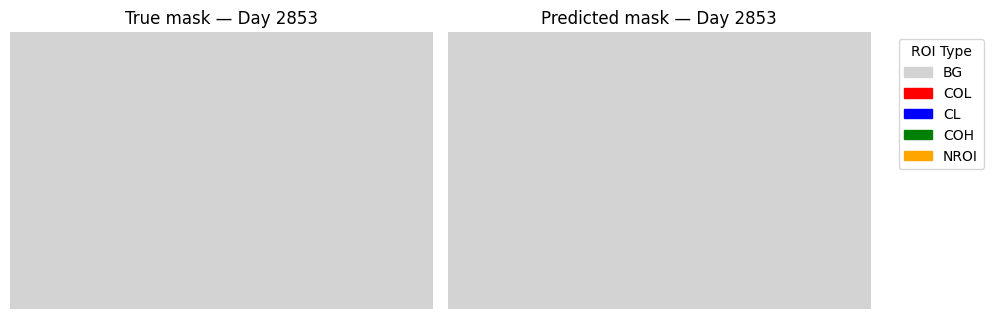

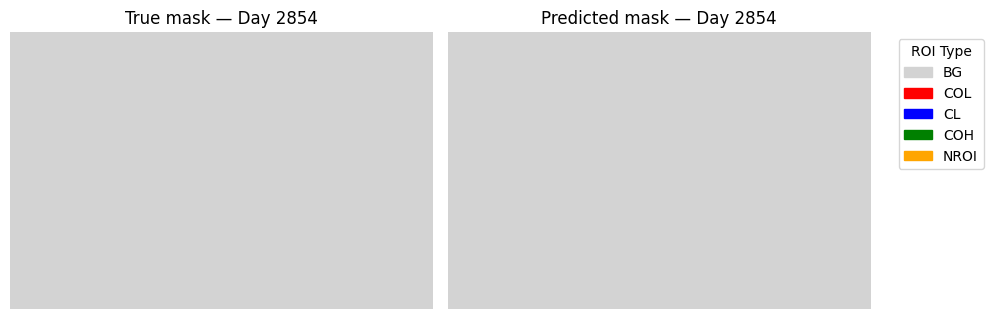

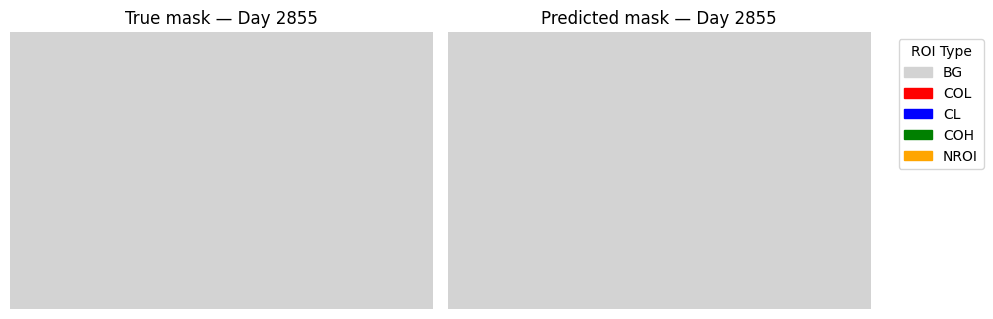

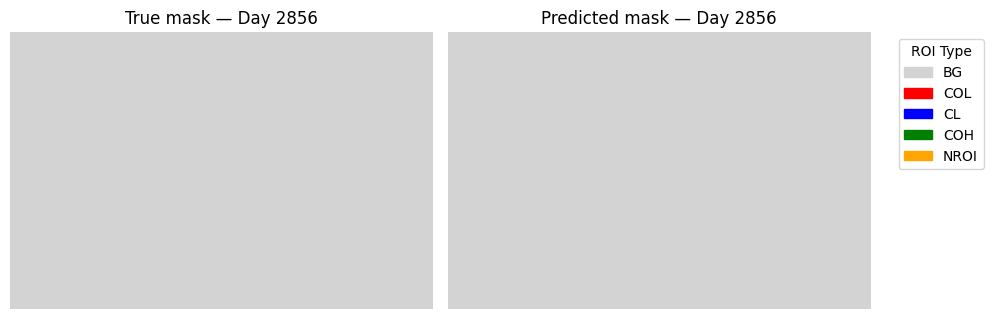

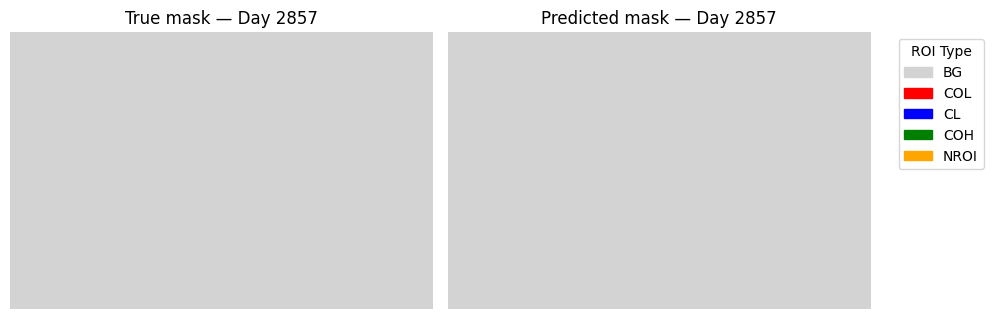

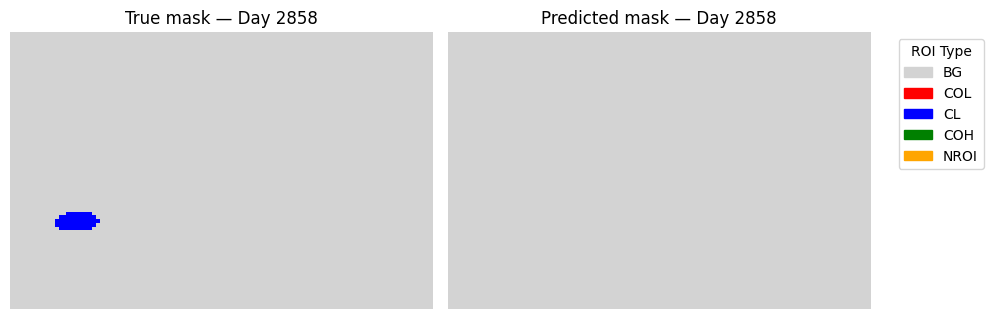

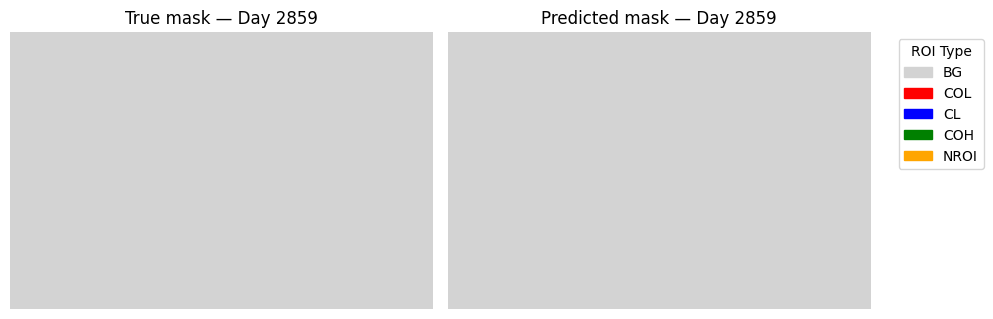

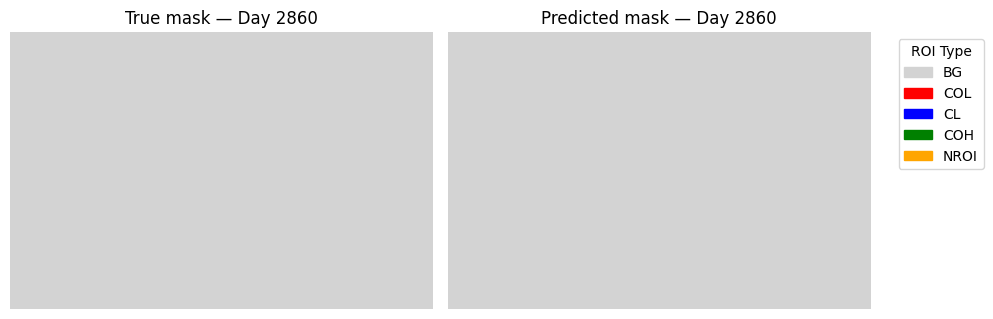

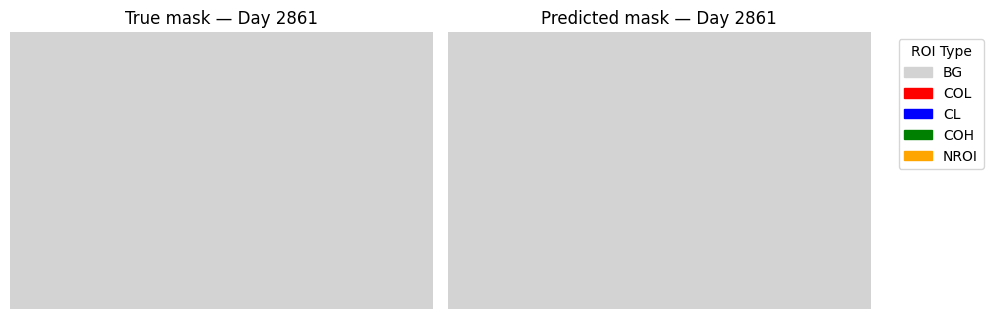

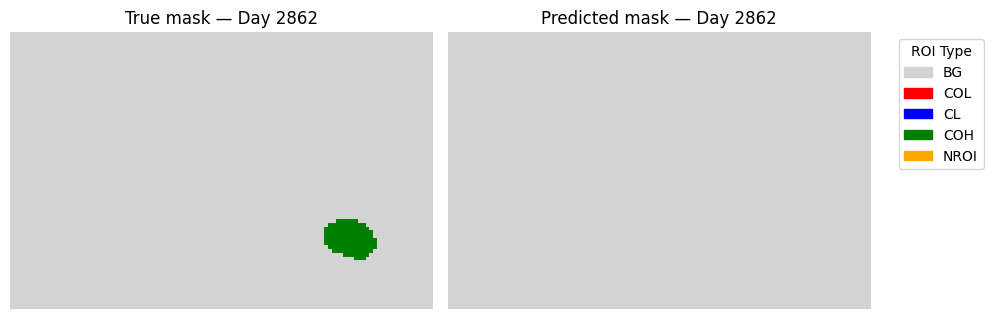

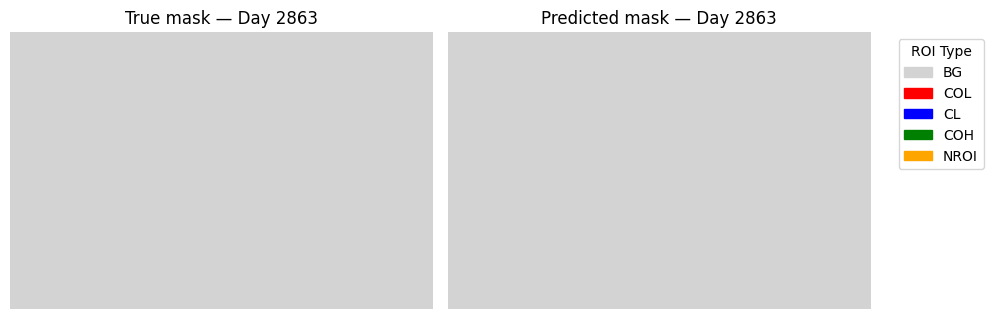

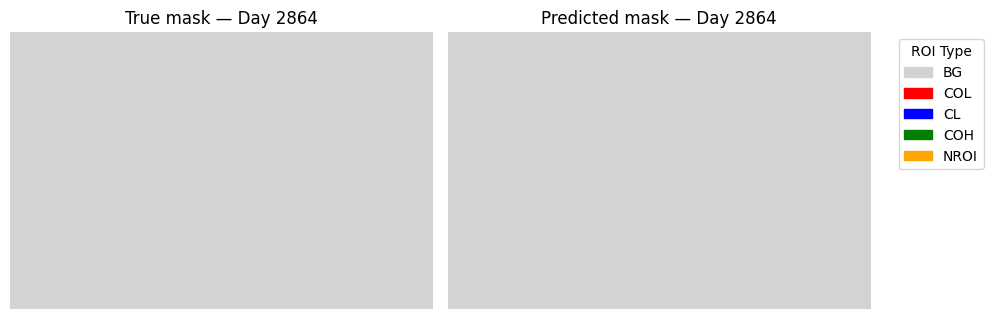

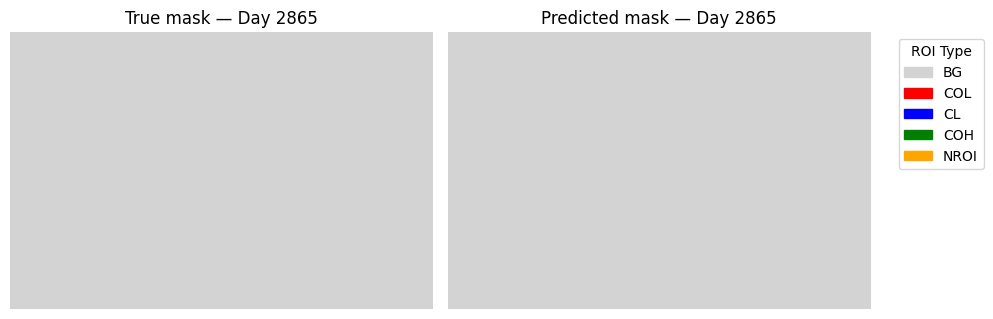

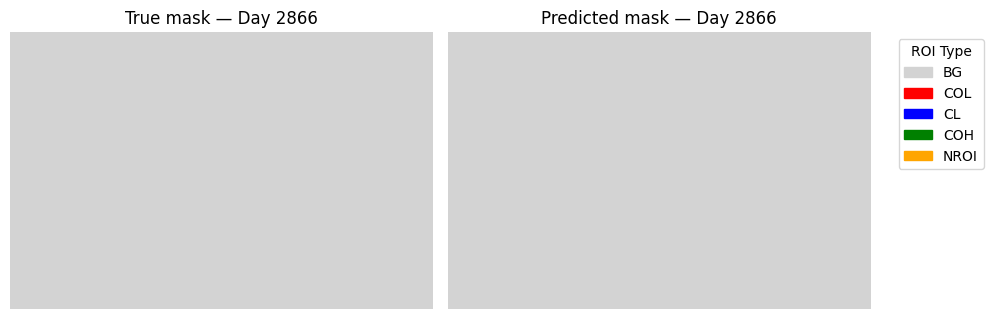

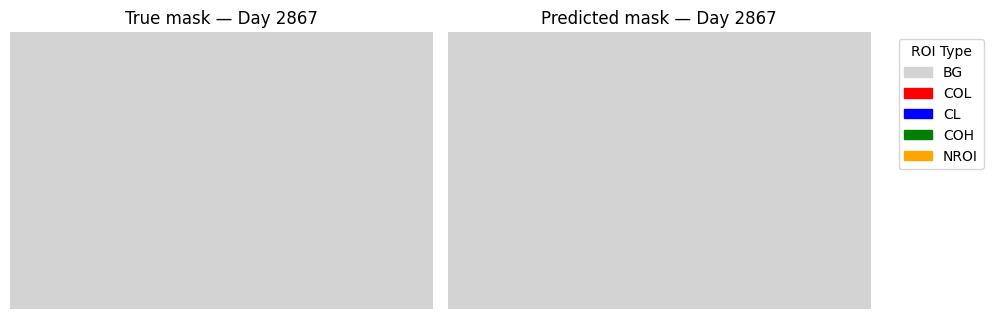

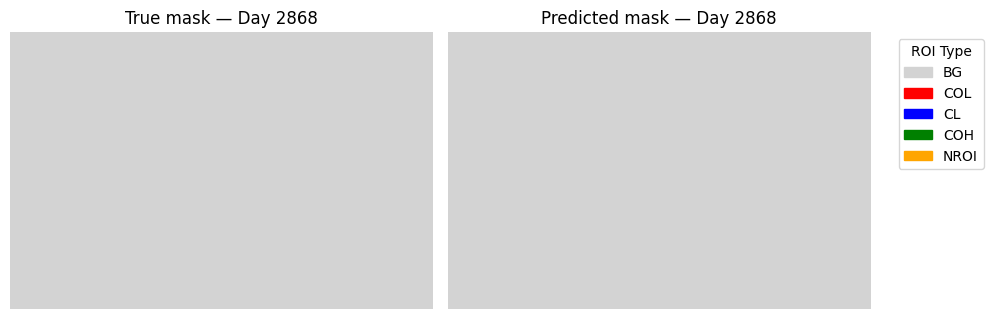

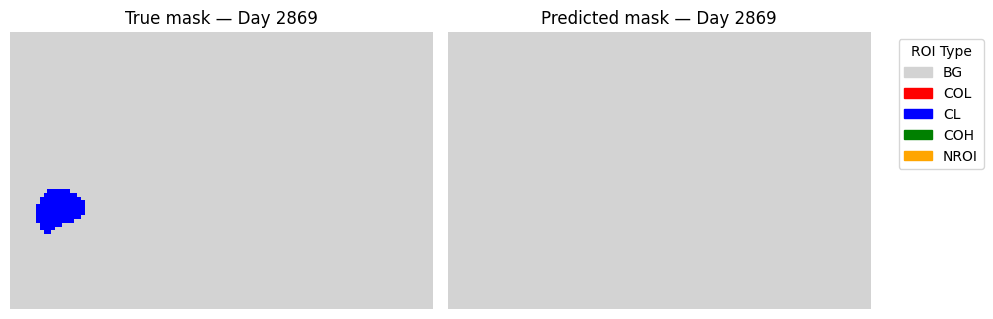

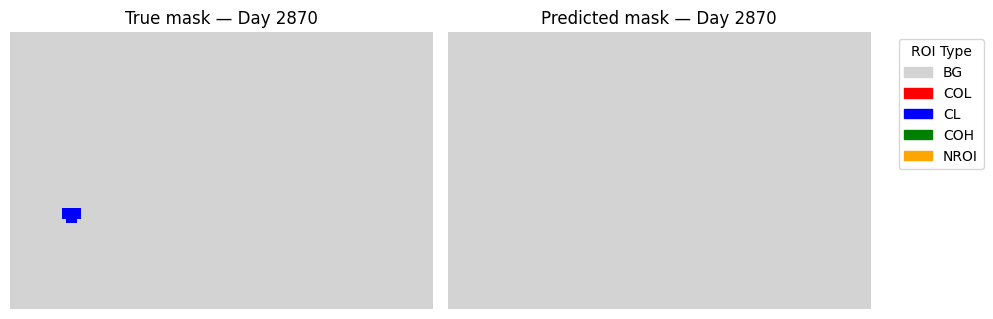

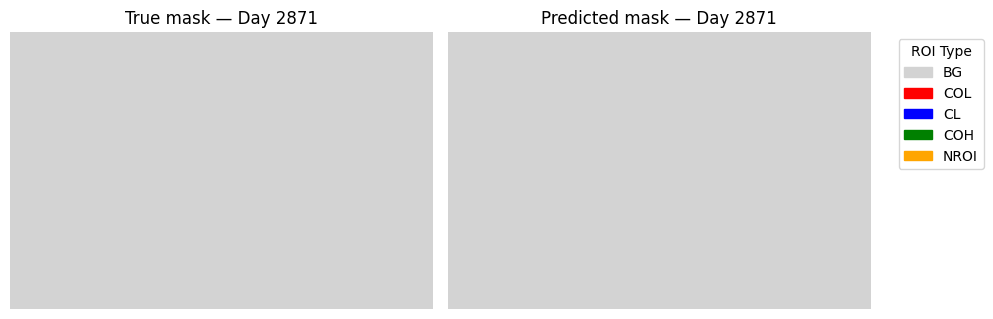

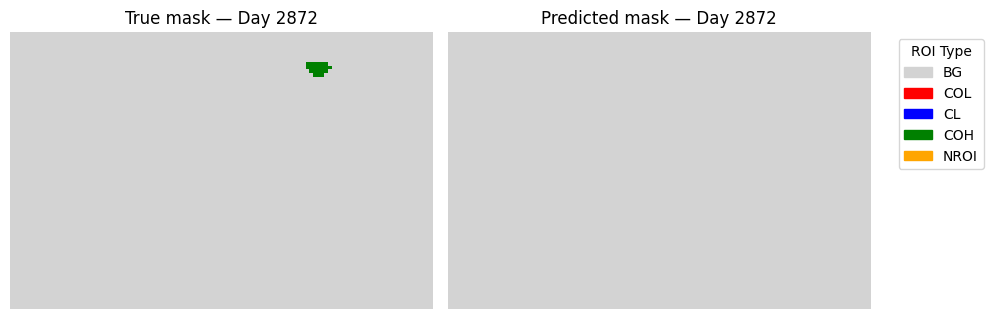

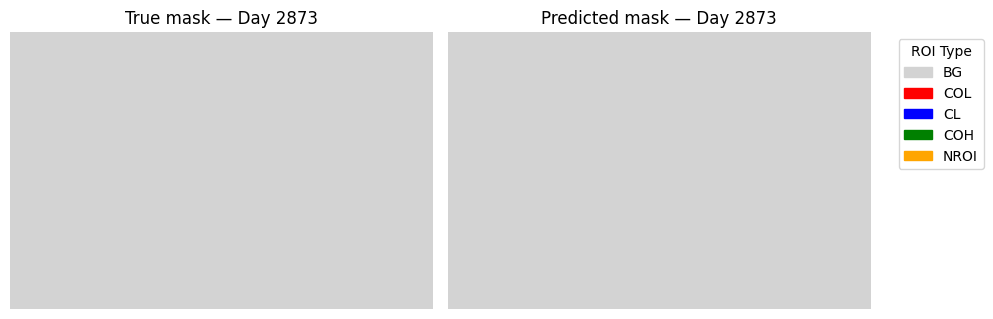

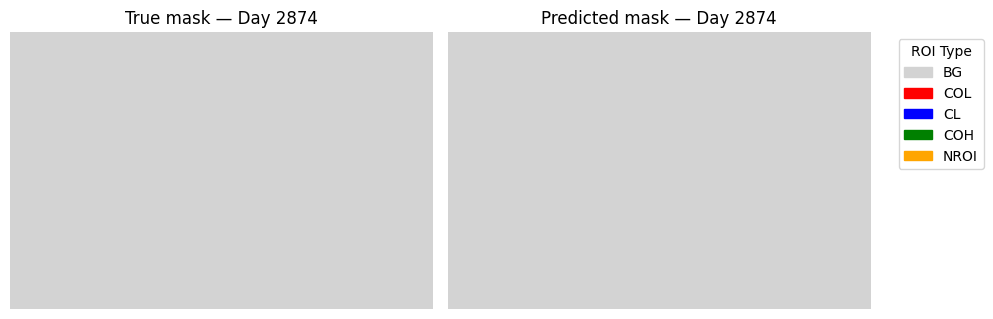

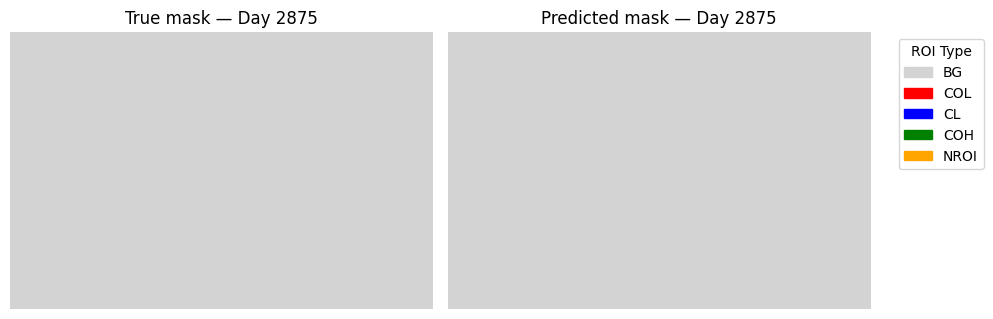

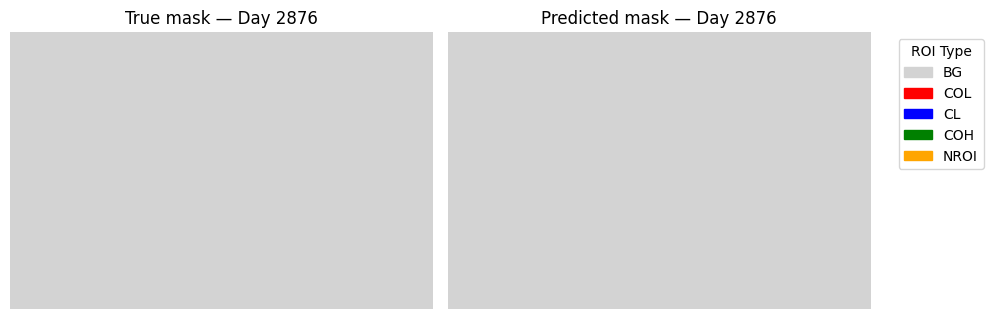

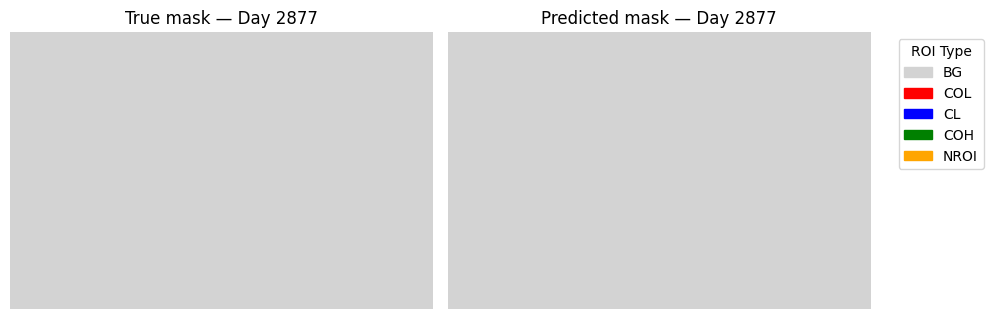

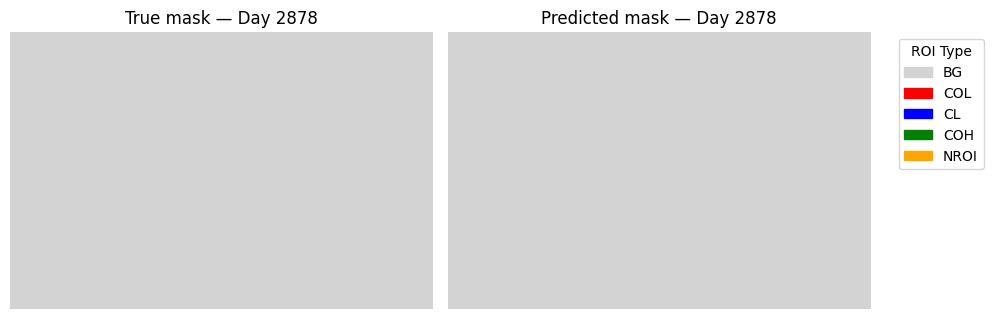

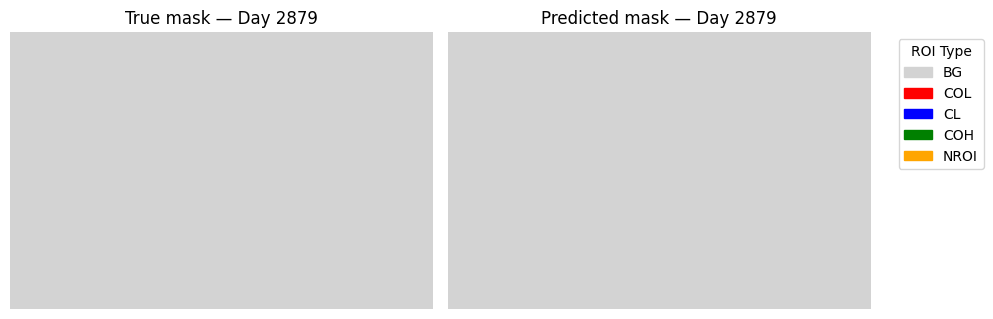

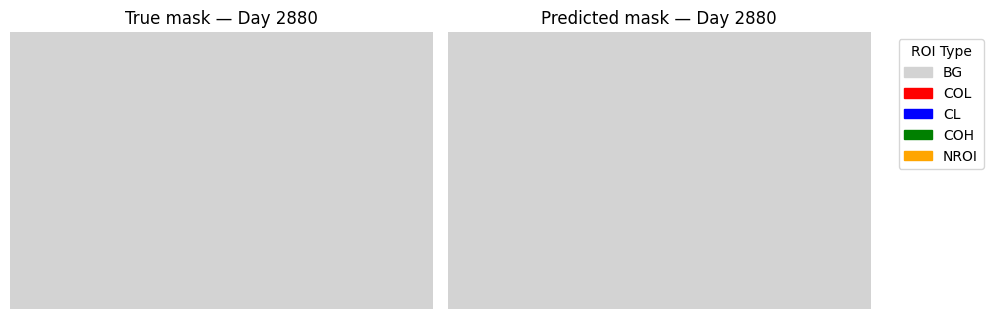

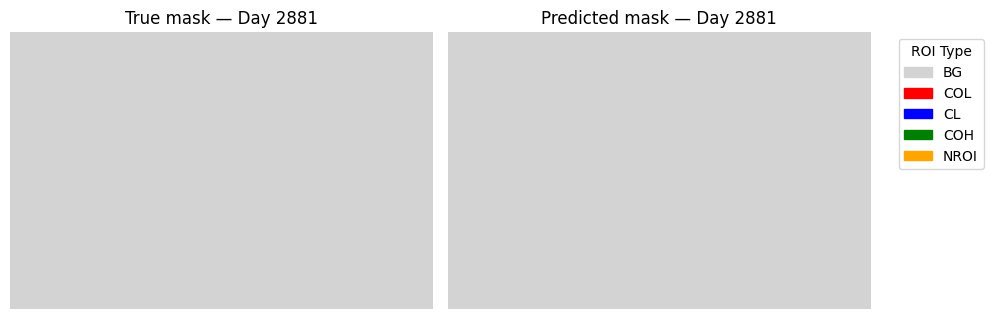

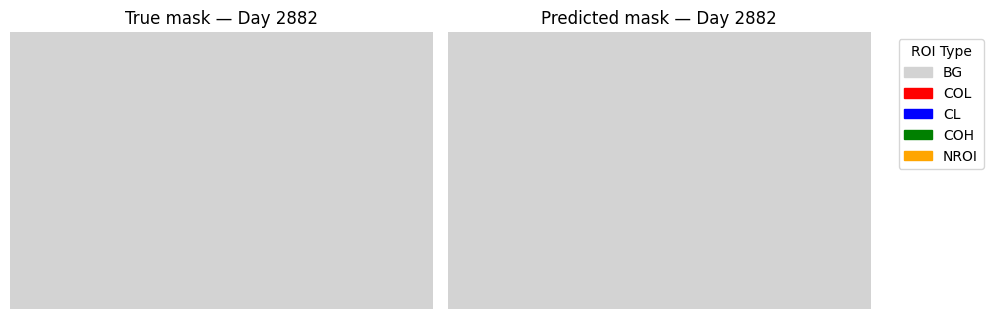

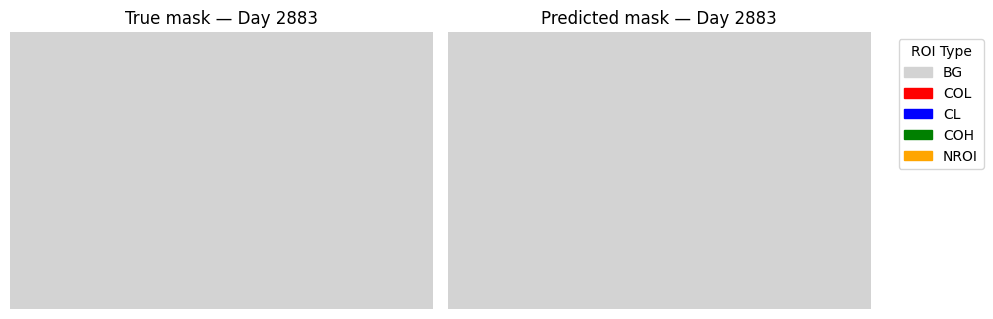

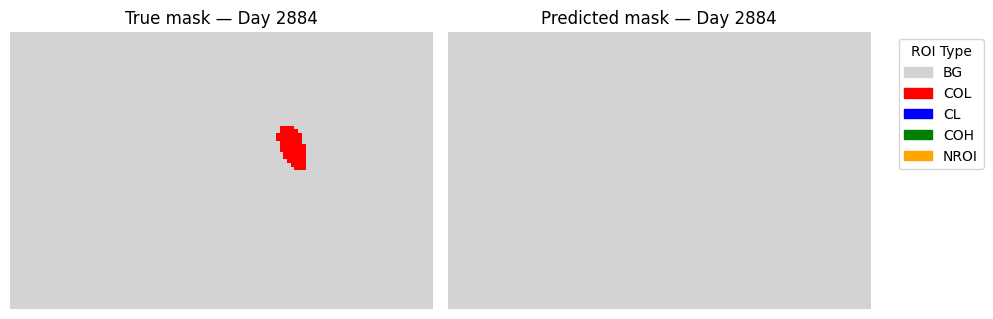

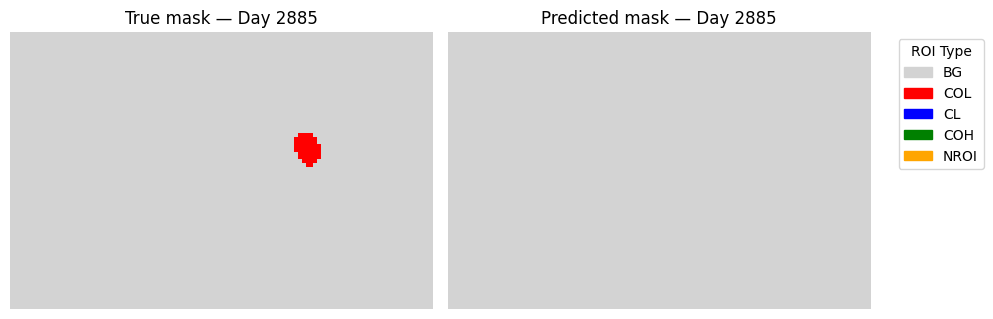

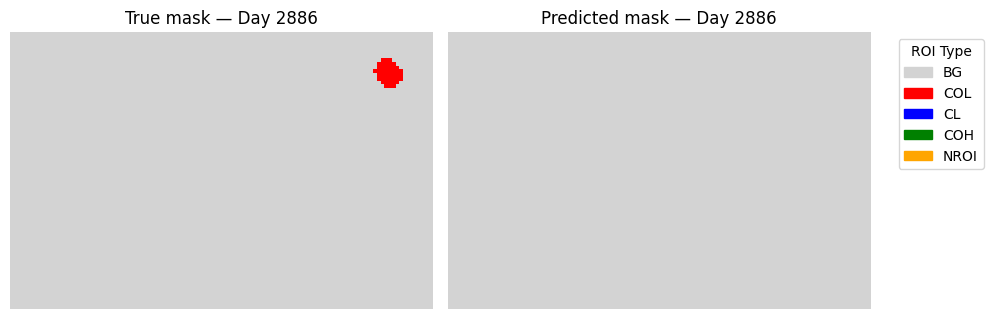

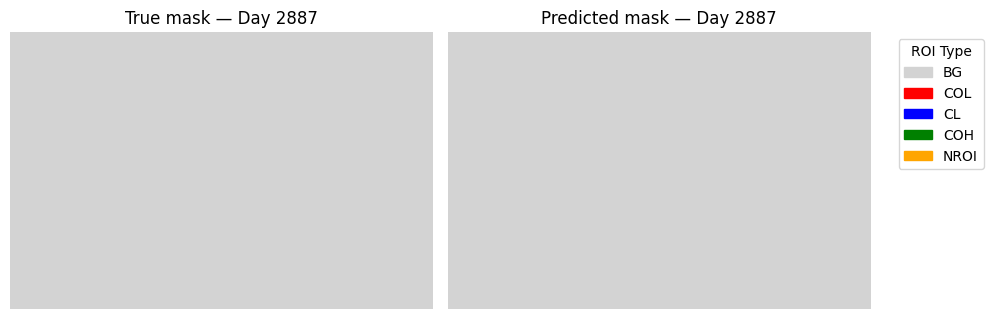

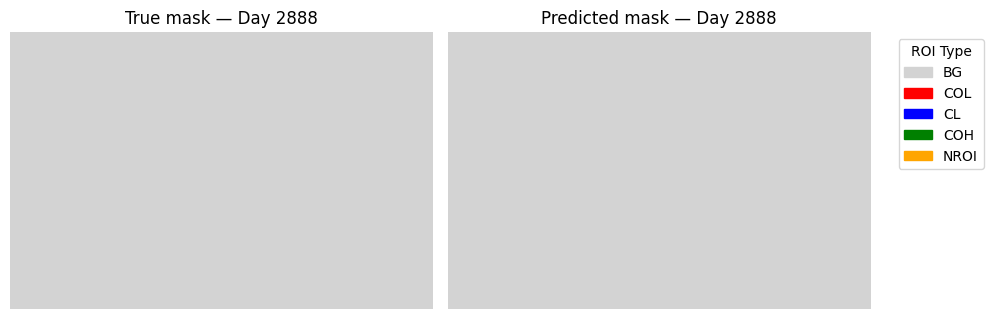

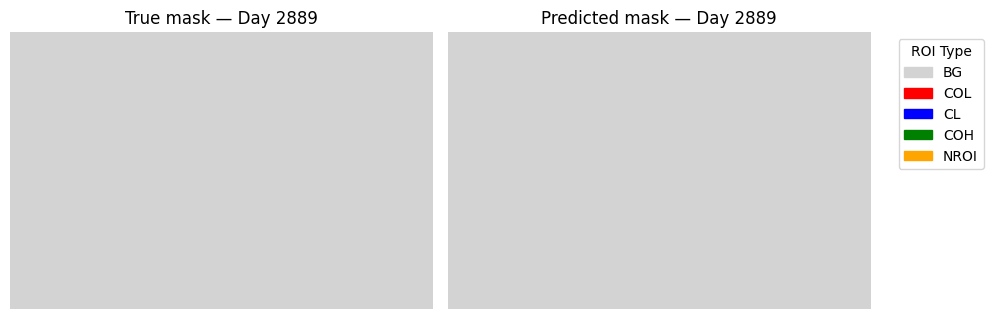

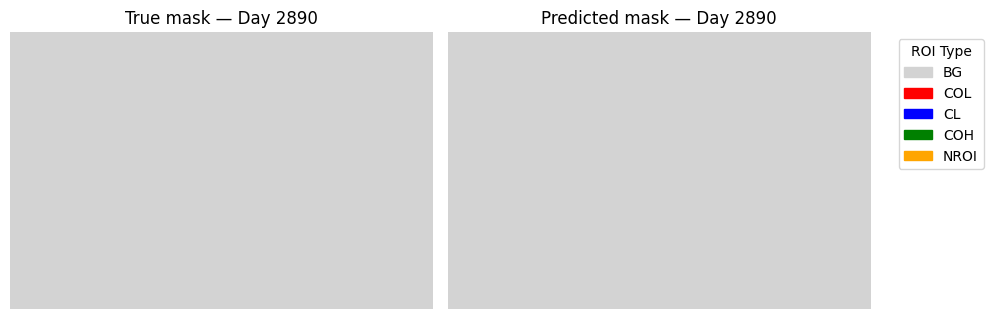

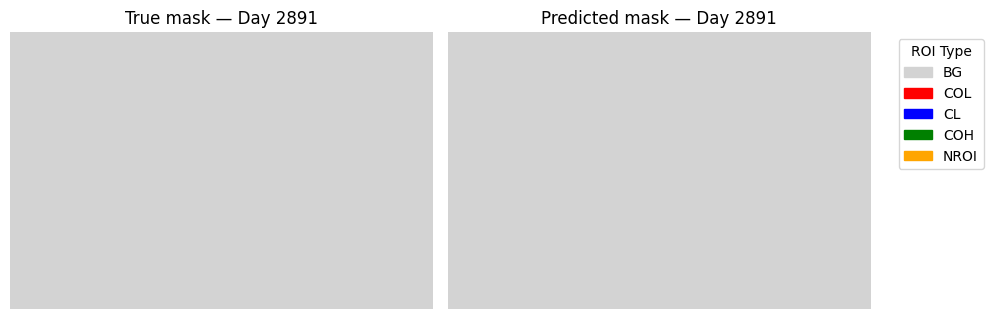

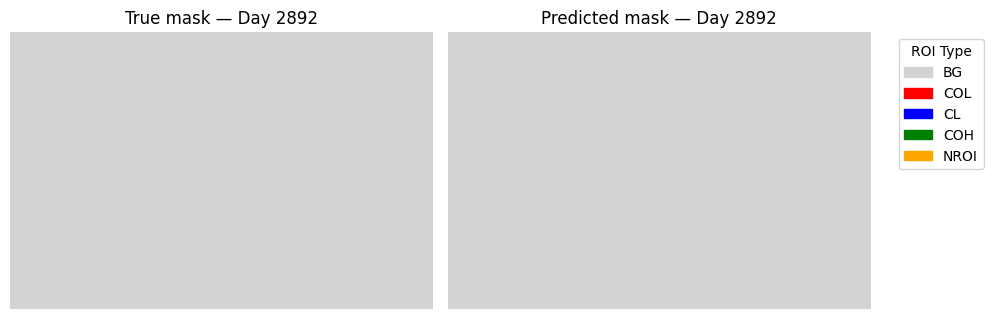

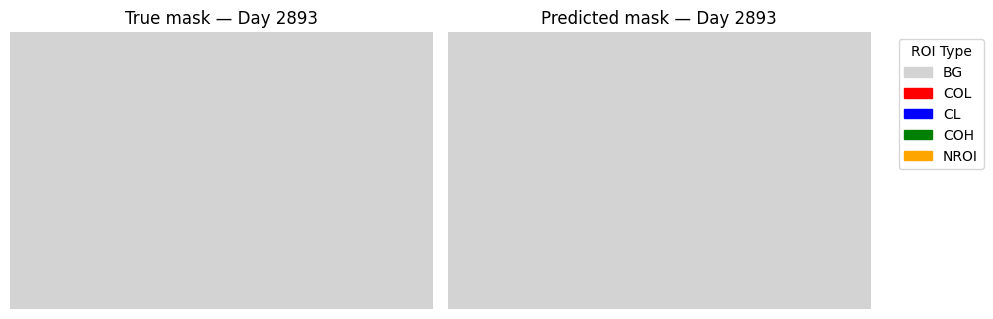

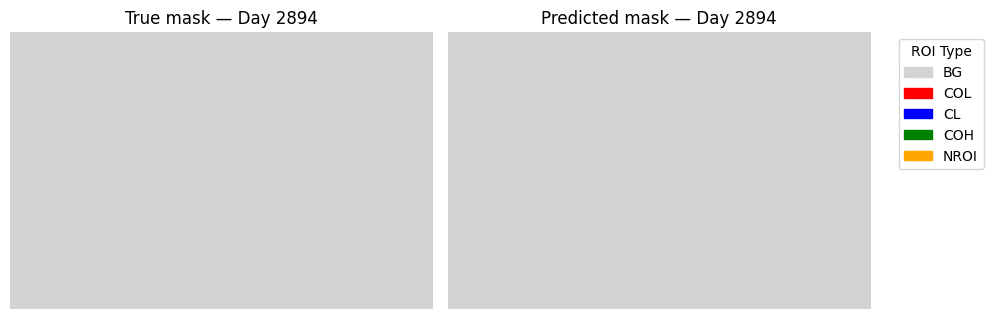

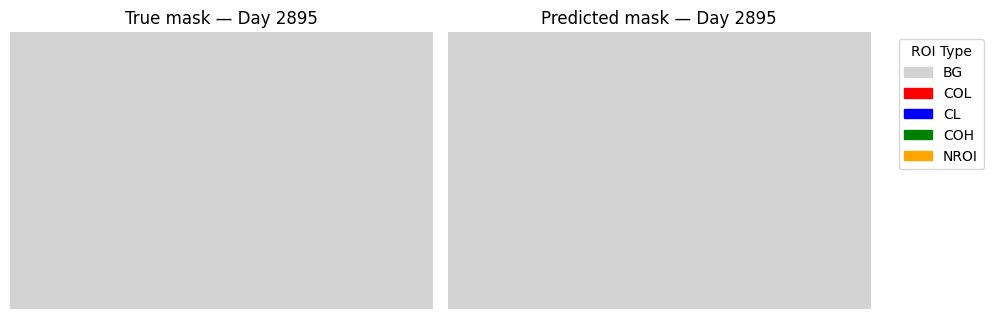

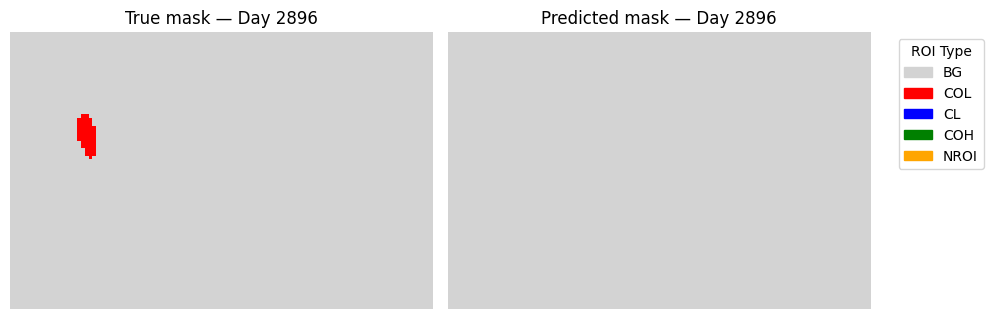

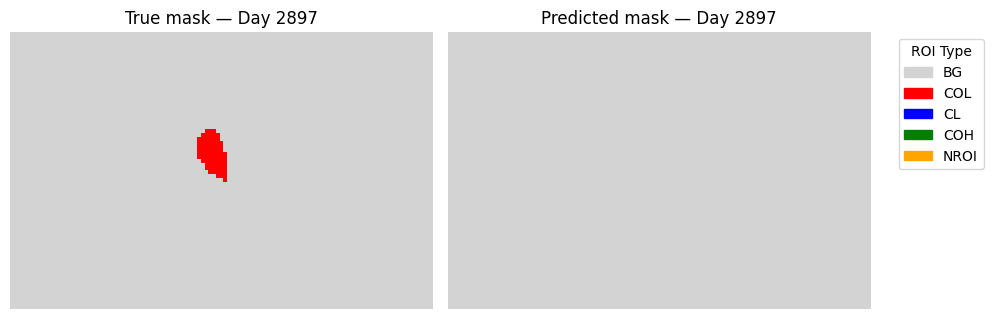

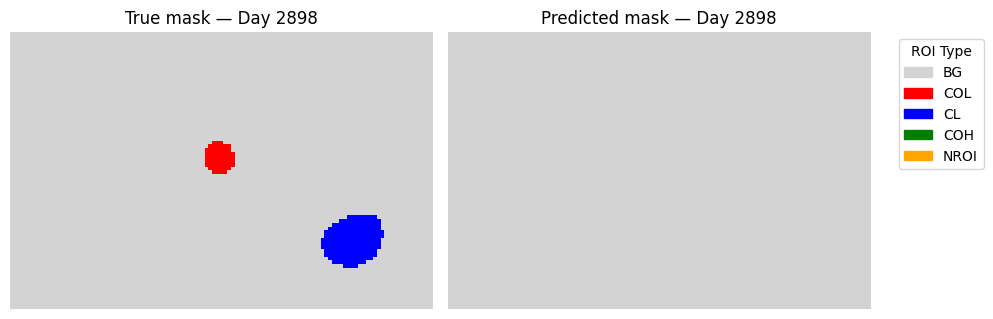

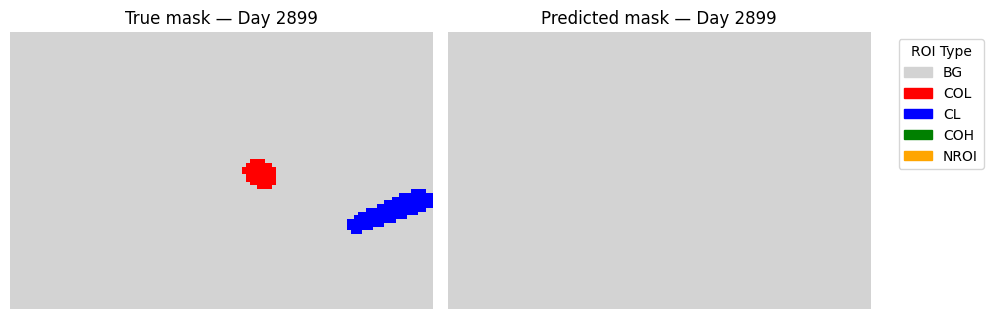

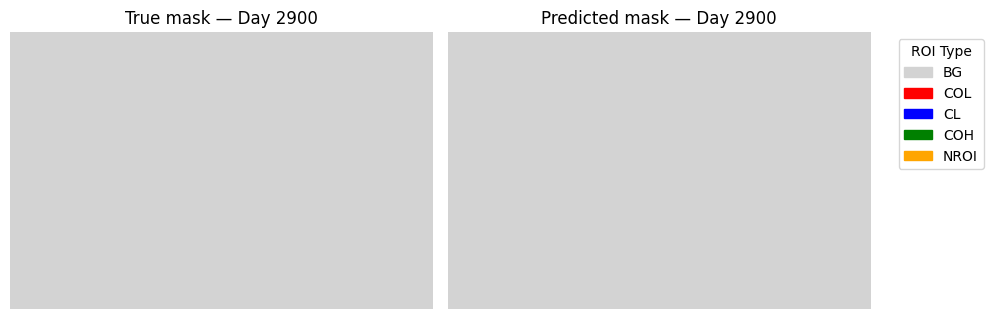

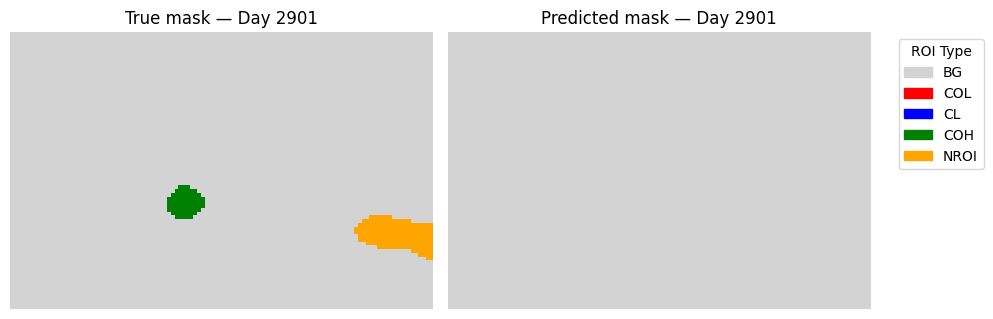

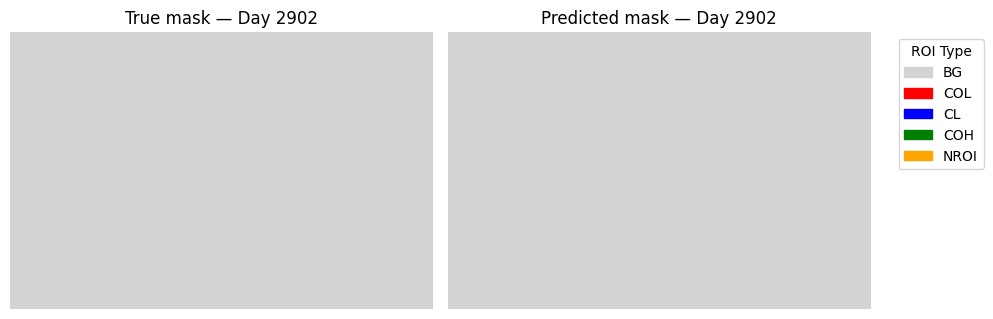

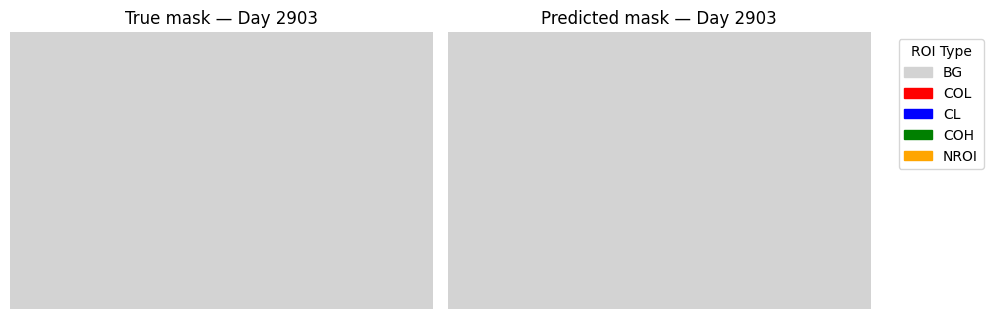

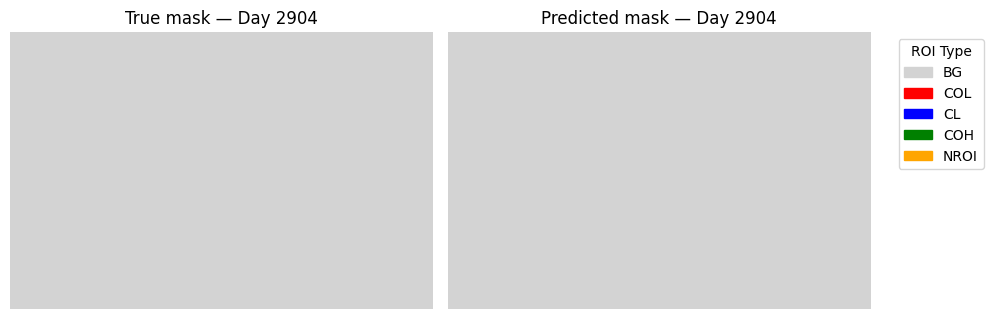

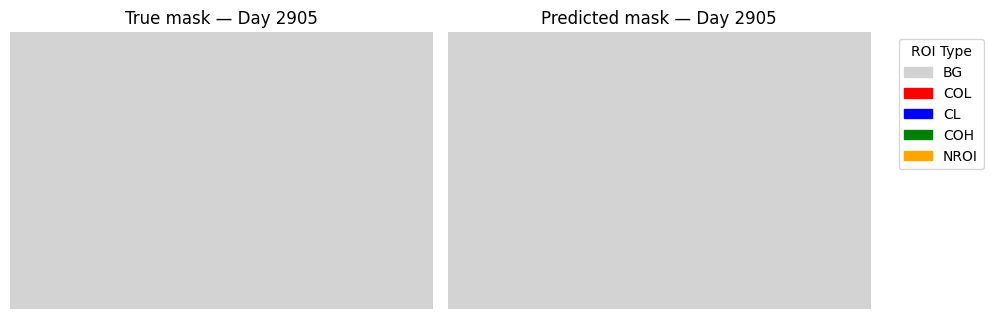

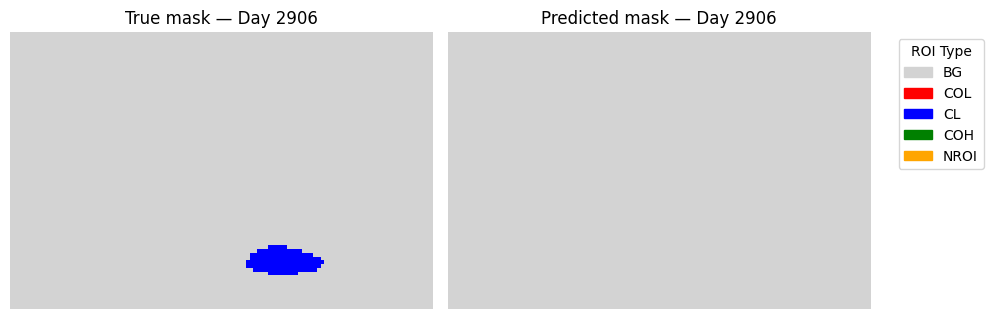

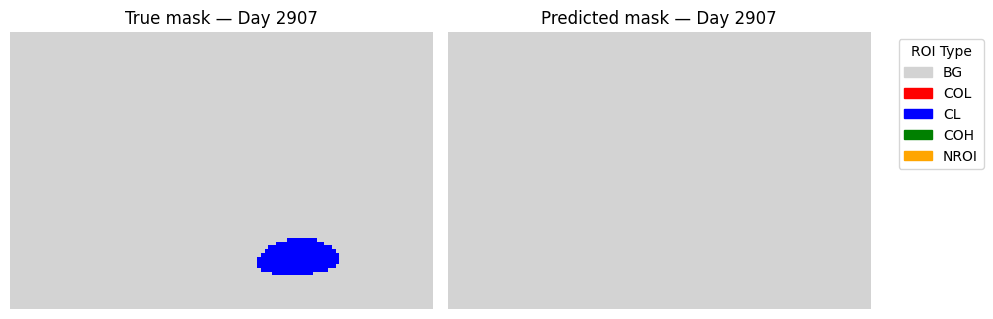

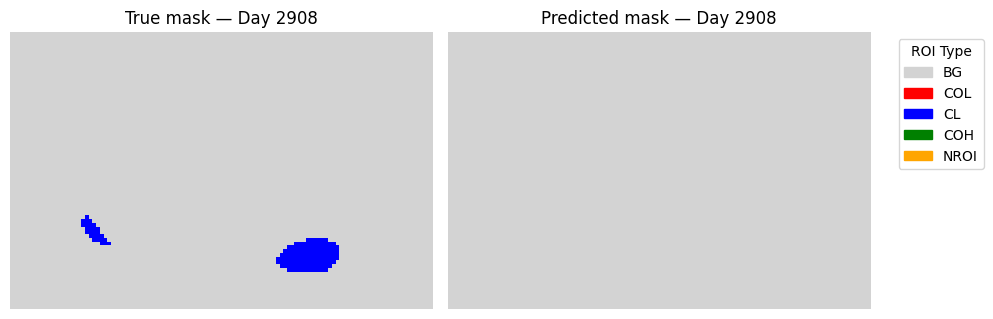

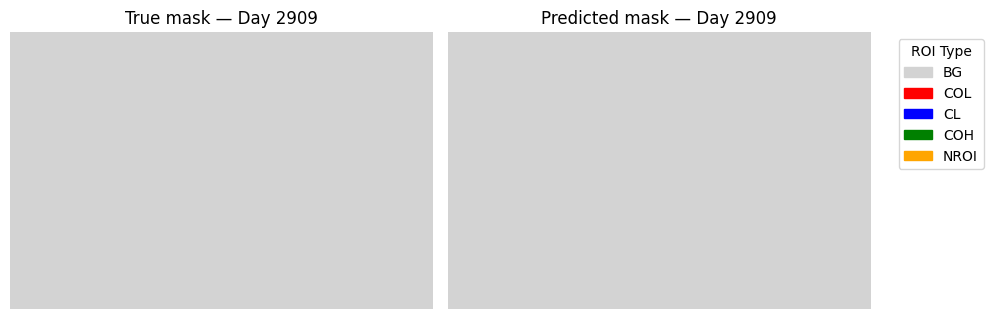

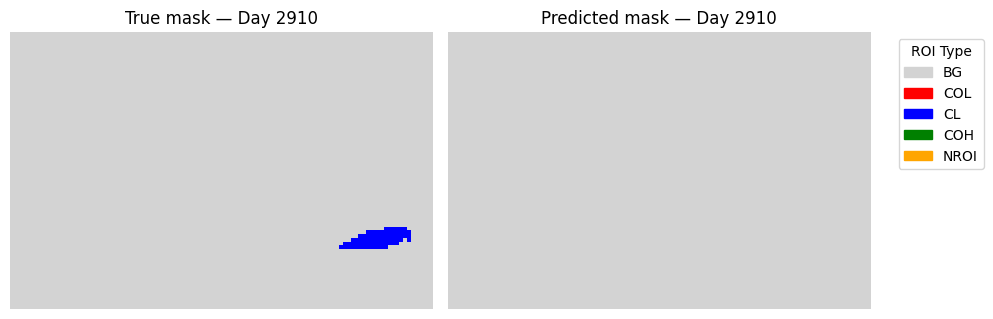

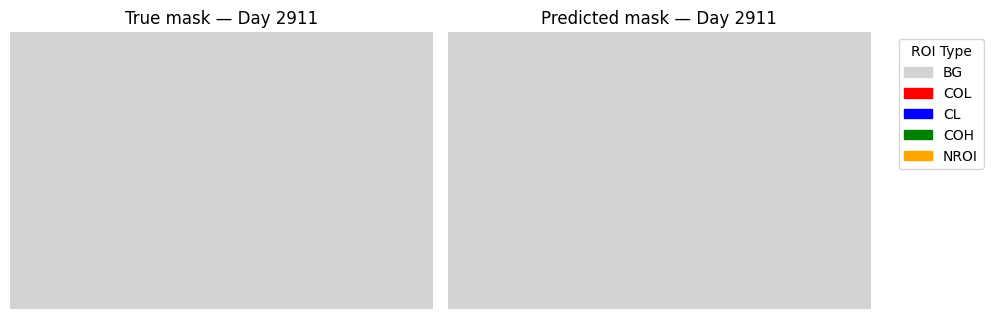

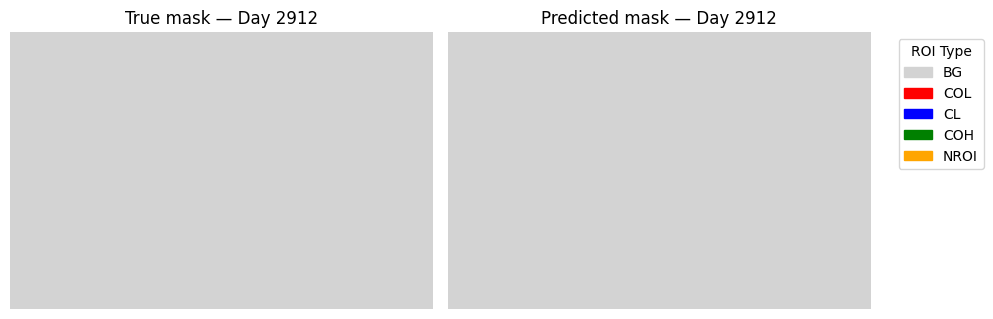

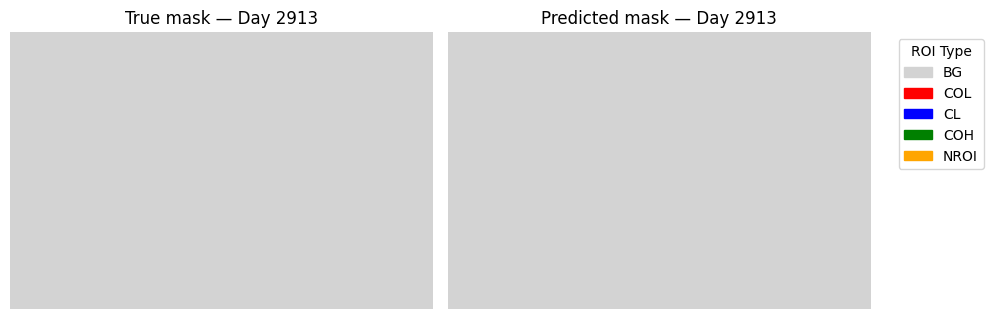

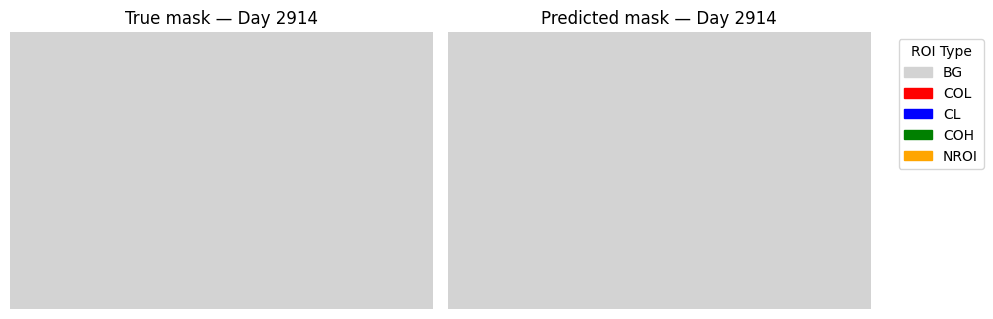

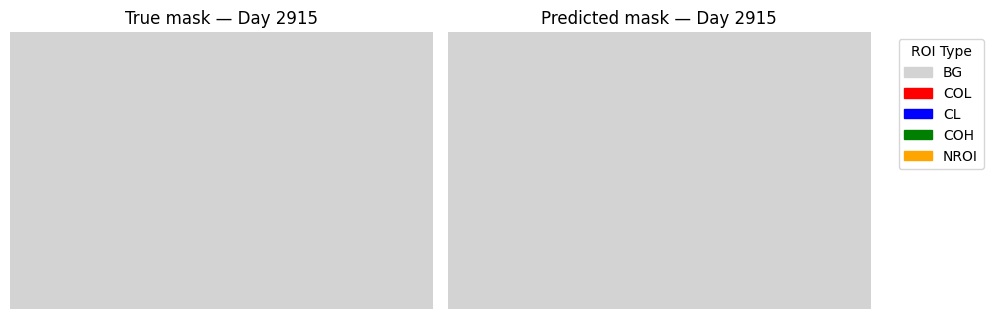

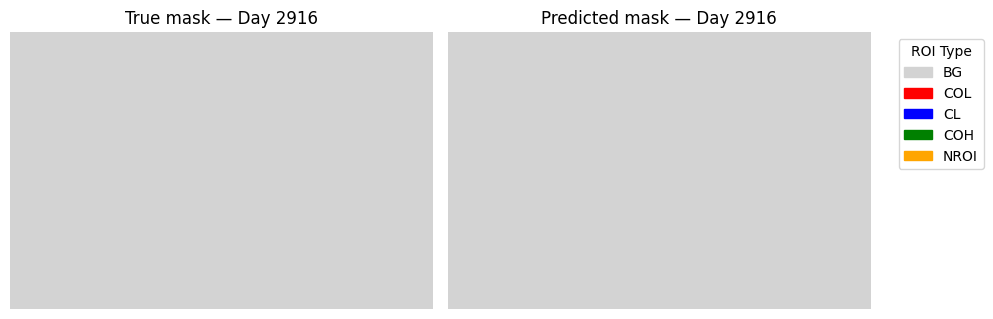

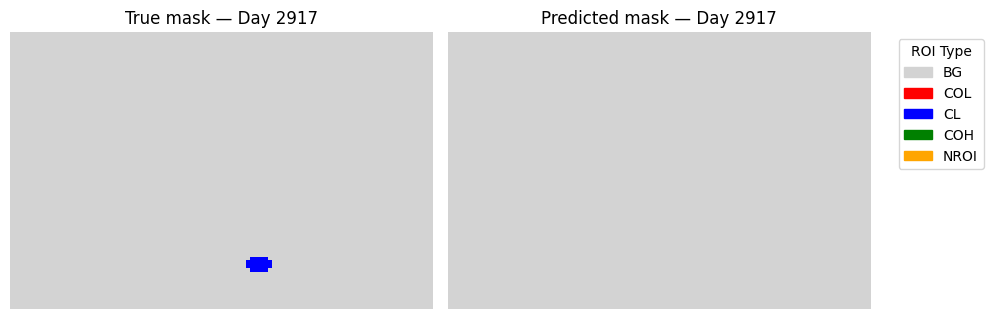

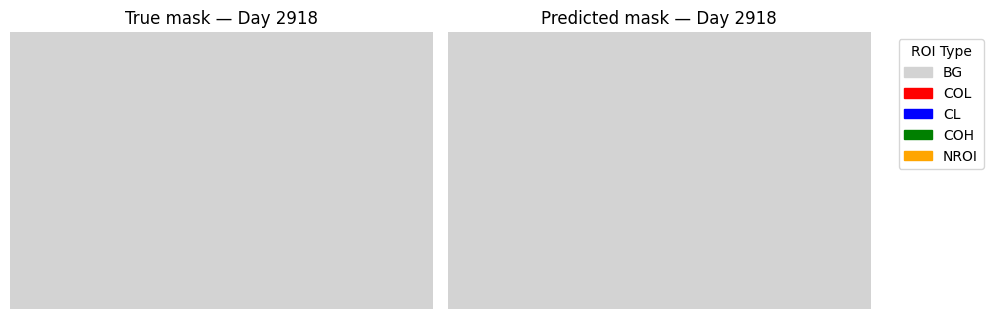

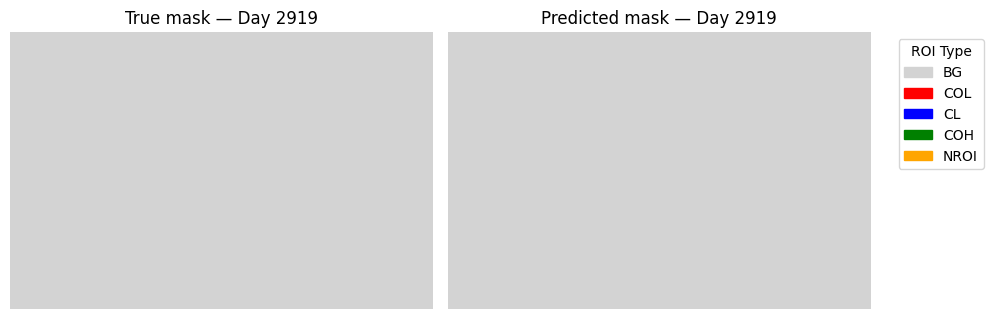

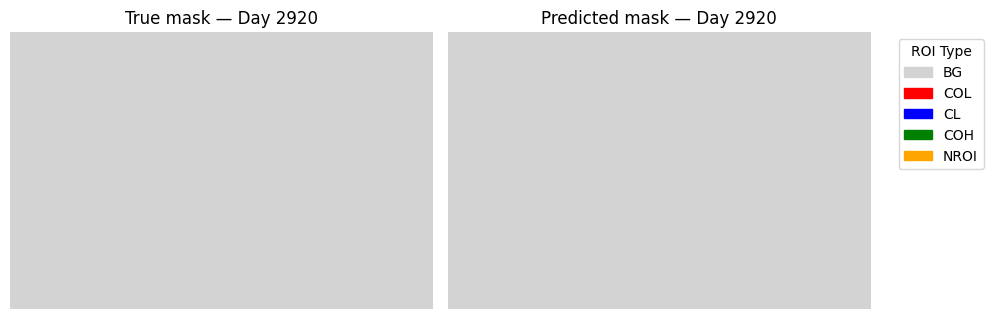

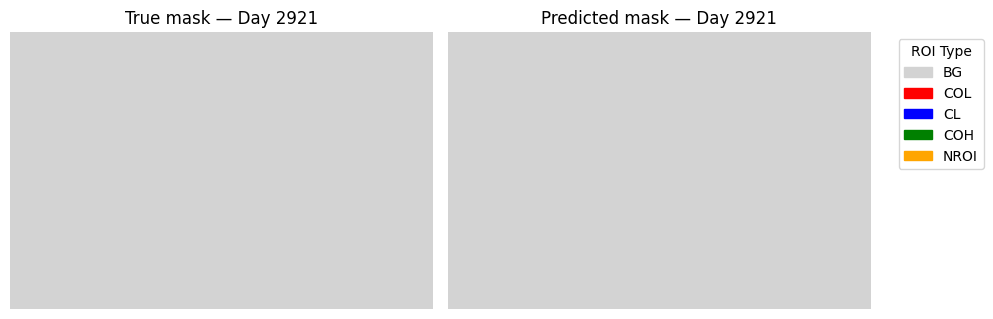

In [6]:
# === TRUE vs. PREDICTED ROI MASKS (color‐coded by type) ===
cmap_types = mcolors.ListedColormap(["lightgrey"] + ([TYPE_COLORS[t] for t in ROI_TYPES]))
type_code  = {t:i for i,t in enumerate(ROI_TYPES)}
for day in TEST_DAYS:
    P,_        = load_grids(day-1)
    H,W        = P.shape
    true_mask  = create_roi_mask(roi_df,day,(H,W))
    sel        = (days_te==day)
    coords_day = coords_te[sel]
    types_day  = types_te[sel]
    preds_day  = y_type_pred[sel]

    pred_mask = np.zeros((H,W),dtype=int)
    for (x,y), pr in zip(coords_day, preds_day):
        if pr != 4:
            pred_mask[H-1-y, x] = pr+1

    fig,(axT,axP) = plt.subplots(1,2,figsize=(10,5),sharex=True,sharey=True)
    axT.imshow(true_mask, cmap=cmap_types, origin="upper", vmin=0, vmax=len(ROI_TYPES))
    axT.set_title(f"True mask — Day {day}");  axT.axis("off")
    axP.imshow(pred_mask, cmap=cmap_types, origin="upper", vmin=0, vmax=len(ROI_TYPES))
    axP.set_title(f"Predicted mask — Day {day}"); axP.axis("off")

    patches = [mpatches.Patch(color=cmap_types(i), label=l)
            for i,l in enumerate(["BG"]+ROI_TYPES)]
    axP.legend(handles=patches, bbox_to_anchor=(1.05,1), loc="upper left", title="ROI Type")
    axT.invert_yaxis()
    axP.invert_yaxis()
    plt.tight_layout()
    plt.show()